# Initialization

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import ast
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
from scipy import stats
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
# Set font sizes for all text elements in the plot
plt.rcParams.update({
    'font.size': 8,          # Default font size
    'axes.titlesize': 10,    # Title font size
    'axes.labelsize': 9,     # Axis labels font size
    'xtick.labelsize': 8,    # X-axis tick labels font size
    'ytick.labelsize': 8,    # Y-axis tick labels font size
    'legend.fontsize': 8,    # Legend font size
    'figure.titlesize': 10   # Figure title font size
})
plt.rcParams['font.family'] = 'sans-serif'



def permutation_test(group1, group2, n_perm=10000, statistic="mean", seed=42):
    """
    Performs a two-sided permutation test between two groups using a vectorized approach.

    Parameters
    ----------
    group1, group2 : array-like
        The two groups to compare.
    n_perm : int, optional (default=10000)
        Number of permutations.
    statistic : {"mean", "median"}, optional
        Statistic used to compute the difference.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    p_value : float
        Two-sided permutation test p-value.
    obs_diff : float
        Observed difference between group2 and group1.
    """
    group1 = np.asarray(group1)
    group2 = np.asarray(group2)

    # Check for empty groups
    if len(group1) == 0 or len(group2) == 0:
        raise ValueError("Both groups must have at least one element.")

    # Set random seed
    rng = np.random.default_rng(seed)

    # Choose statistic
    if statistic == "mean":
        stat_func = np.mean
    elif statistic == "median":
        stat_func = np.median
    else:
        raise ValueError("statistic must be 'mean' or 'median'")

    # Observed difference
    obs_diff = stat_func(group2) - stat_func(group1)

    # Combine groups
    combined = np.concatenate([group1, group2])
    n1 = len(group1)
    n_total = len(combined)

    # Generate all permutations at once
    permuted = rng.permuted(np.tile(combined, (n_perm, 1)), axis=1)
    perm1 = permuted[:, :n1]
    perm2 = permuted[:, n1:]

    # Compute permuted differences
    perm_diffs = stat_func(perm2, axis=1) - stat_func(perm1, axis=1)

    # Two-sided p-value
    p_value = np.mean(np.abs(perm_diffs) >= abs(obs_diff))

    return p_value



def p_value_reporting(p_val):
    if p_val >= 0.05:
        stars = "n.s."
    elif p_val < 0.0001:
        stars = "****"
    elif p_val < 0.001:
        stars = "***"
    elif p_val < 0.01:
        stars = "**"
    else:
        stars = "*"
    return stars


def bootstrap_ci(data, n_boot=10000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return lower, upper


dCaAP_color = plt.get_cmap('Pastel2')(0)
dCaAP_error_color = plt.get_cmap('Set2')(0)
NMDA_color = plt.get_cmap('Pastel2')(1)
NMDA_error_color = plt.get_cmap('Set2')(1)

dCaAP_color2 = plt.get_cmap('tab20c')(18)
dCaAP_error_color2 = plt.get_cmap('tab20c')(17)


thr_color = plt.get_cmap('Pastel2')(2)
thr_error_color = plt.get_cmap('Set2')(2)
grade_color = plt.get_cmap('Pastel2')(3)
grade_error_color = plt.get_cmap('Set2')(3)
ref_color=plt.get_cmap('Pastel2')(4)
ref_error_color=plt.get_cmap('Set2')(4)
amp_color=plt.get_cmap('Pastel2')(5)
amp_error_color=plt.get_cmap('Set2')(5)

dCaAP_legend = mlines.Line2D([], [], color=dCaAP_color, marker='s', linestyle='None',
                           label='dCaAP')
dCaAP_legend2 = mlines.Line2D([], [], color=dCaAP_color2, marker='s', linestyle='None',
                           label='dCaAP')
NMDA_legend = mlines.Line2D([], [], color=NMDA_color, marker='s', linestyle='None',
                           label='NMDA')
thr_legend = mlines.Line2D([], [], color=thr_color, marker='s', linestyle='None',
                           label='dCaAP: lower d-spike threshold')
grade_legend = mlines.Line2D([], [], color=grade_color, marker='s', linestyle='None',
                           label='dCaAP: not graded response')
ref_legend = mlines.Line2D([], [], color=ref_color, marker='s', linestyle='None',
                           label='dCaAP: shorter refractory time')
amp_legend = mlines.Line2D([], [], color=amp_color, marker='s', linestyle='None',
                           label='dCaAP: lower spike amplitude')

# Random_Input

## basic model

In [6]:
EXP2_dend =[]
EXP2_dend_err=[]
EXP2_assemb = []
EXP2_assemb_err=[]
EXP2_eff =[]
EXP2_eff_err=[]

dend_list = []
assembly_list = []
eff_list = []
#################################################
exp_name = "rewiring_ex2"
exp_result_name_folder = 'Random_input'



for model_name in ['Limbacher','Gidon_dend']:


        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
            
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')   
            
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
#                         print(line_as_list)
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        
        dend_list.append(sep_dend)
        assembly_list.append(sep_ass)
        eff_list.append(eff)
    
        
        EXP2_dend.append(np.mean(sep_dend))
        EXP2_dend_err.append(np.std(sep_dend))
        EXP2_assemb.append(np.mean(sep_ass))
        EXP2_assemb_err.append(np.std(sep_ass))
        EXP2_eff.append(np.mean(eff))
        EXP2_eff_err.append(np.std(eff))

### P-Value

In [9]:
random_eff_p = permutation_test(eff_list[0], eff_list[1])
random_dend_p = permutation_test(dend_list[0], dend_list[1])
random_assemb_p = permutation_test(assembly_list[0], assembly_list[1])

In [11]:
basic_random_limb_eff = eff_list[0]
basic_random_limb_dend = dend_list[0]
basic_random_limb_assemb = assembly_list[0]

basic_random_gidon_eff = eff_list[1]
basic_random_gidon_dend = dend_list[1]
basic_random_gidon_assemb = assembly_list[1]

## Results of the dCaAP model with lower dendritic spike threshold

In [14]:
thr_EXP2_dend =[]
thr_EXP2_dend_err=[]
thr_EXP2_assemb = []
thr_EXP2_assemb_err=[]
thr_EXP2_eff =[]
thr_EXP2_eff_err=[]

dend_list = [basic_random_gidon_dend]
assembly_list = [basic_random_gidon_assemb]
eff_list = [basic_random_gidon_eff]
#################################################
exp_name = "rewiring_ex2"
exp_result_name_folder = 'Random_input_d_thr'
for model_name in ['Gidon_dend']:
    

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
            
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')   
            
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
    
        dend_list.append(sep_dend)
        assembly_list.append(sep_ass)
        eff_list.append(eff)
        
        thr_EXP2_dend.append(np.mean(sep_dend))
        thr_EXP2_dend_err.append(np.std(sep_dend))
        thr_EXP2_assemb.append(np.mean(sep_ass))
        thr_EXP2_assemb_err.append(np.std(sep_ass))
        thr_EXP2_eff.append(np.mean(eff))
        thr_EXP2_eff_err.append(np.std(eff))

In [16]:
random_thr_eff_p = permutation_test(eff_list[0], eff_list[1])
random_thr_dend_p = permutation_test(dend_list[0], dend_list[1])
random_thr_assemb_p = permutation_test(assembly_list[0], assembly_list[1])

## Results of the dCaAP model with constant dendritic spike amplitude (not graded)

In [19]:
grade_EXP2_dend =[]
grade_EXP2_dend_err=[]
grade_EXP2_assemb = []
grade_EXP2_assemb_err=[]
grade_EXP2_eff =[]
grade_EXP2_eff_err=[]

dend_list = [basic_random_gidon_dend]
assembly_list = [basic_random_gidon_assemb]
eff_list = [basic_random_gidon_eff]
#################################################
exp_name = "rewiring_ex2"
exp_result_name_folder = 'Random_input_not_graded'
for model_name in ['Gidon_dend']:
    

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
            
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')   
            
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)

        dend_list.append(sep_dend)
        assembly_list.append(sep_ass)
        eff_list.append(eff)
        
        grade_EXP2_dend.append(np.mean(sep_dend))
        grade_EXP2_dend_err.append(np.std(sep_dend))
        grade_EXP2_assemb.append(np.mean(sep_ass))
        grade_EXP2_assemb_err.append(np.std(sep_ass))
        grade_EXP2_eff.append(np.mean(eff))
        grade_EXP2_eff_err.append(np.std(eff))

In [21]:
random_grade_eff_p = permutation_test(eff_list[0], eff_list[1])
random_grade_dend_p = permutation_test(dend_list[0], dend_list[1])
random_grade_assemb_p = permutation_test(assembly_list[0], assembly_list[1])

## Results of the dCaAP model with shorter dendritic refractory time

In [24]:
ref_EXP2_dend =[]
ref_EXP2_dend_err=[]
ref_EXP2_assemb = []
ref_EXP2_assemb_err=[]
ref_EXP2_eff =[]
ref_EXP2_eff_err=[]


dend_list = [basic_random_gidon_dend]
assembly_list = [basic_random_gidon_assemb]
eff_list = [basic_random_gidon_eff]

#################################################
exp_name = "rewiring_ex2"
exp_result_name_folder = 'Random_input_ref'
for model_name in ['Gidon_dend']:
    

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
            
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')   
            
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


        dend_list.append(sep_dend)
        assembly_list.append(sep_ass)
        eff_list.append(eff)
        
        ref_EXP2_dend.append(np.mean(sep_dend))
        ref_EXP2_dend_err.append(np.std(sep_dend))
        ref_EXP2_assemb.append(np.mean(sep_ass))
        ref_EXP2_assemb_err.append(np.std(sep_ass))
        ref_EXP2_eff.append(np.mean(eff))
        ref_EXP2_eff_err.append(np.std(eff))

In [26]:
random_ref_eff_p = permutation_test(eff_list[0], eff_list[1])
random_ref_dend_p = permutation_test(dend_list[0], dend_list[1])
random_ref_assemb_p = permutation_test(assembly_list[0], assembly_list[1])

## Results of the dCaAP model with lower dendritic spike amplitude

In [29]:
amp_EXP2_dend =[]
amp_EXP2_dend_err=[]
amp_EXP2_assemb = []
amp_EXP2_assemb_err=[]
amp_EXP2_eff =[]
amp_EXP2_eff_err=[]

dend_list = [basic_random_gidon_dend]
assembly_list = [basic_random_gidon_assemb]
eff_list = [basic_random_gidon_eff]

#################################################
exp_name = "rewiring_ex2"
exp_result_name_folder = 'Random_input_amp'
for model_name in ['Gidon_dend']:
    

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
            
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')   
            
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)

        dend_list.append(sep_dend)
        assembly_list.append(sep_ass)
        eff_list.append(eff)
        
        amp_EXP2_dend.append(np.mean(sep_dend))
        amp_EXP2_dend_err.append(np.std(sep_dend))
        amp_EXP2_assemb.append(np.mean(sep_ass))
        amp_EXP2_assemb_err.append(np.std(sep_ass))
        amp_EXP2_eff.append(np.mean(eff))
        amp_EXP2_eff_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/101007364.py:49: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [31]:
random_amp_eff_p = permutation_test(eff_list[0], eff_list[1])
random_amp_dend_p = permutation_test(dend_list[0], dend_list[1])
random_amp_assemb_p = permutation_test(assembly_list[0], assembly_list[1])

## Results for the Random input model without structural plasctisity

In [34]:
str_EXP2_dend =[]
str_EXP2_dend_err=[]
str_EXP2_assemb = []
str_EXP2_assemb_err=[]
str_EXP2_eff =[]
str_EXP2_eff_err=[]

random_str_dend_list = []
random_str_assembly_list = []
random_str_eff_list = []
#################################################
exp_name = "rewiring_ex2"
exp_result_name_folder = 'Random_input_no_str'


for model_name in ['Limbacher','Gidon_dend']:


        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
            
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')   
            
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
#                         print(line_as_list)
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        
        random_str_dend_list.append(sep_dend)
        random_str_assembly_list.append(sep_ass)
        random_str_eff_list.append(eff)
    
        
        str_EXP2_dend.append(np.mean(sep_dend))
        str_EXP2_dend_err.append(np.std(sep_dend))
        str_EXP2_assemb.append(np.mean(sep_ass))
        str_EXP2_assemb_err.append(np.std(sep_ass))
        str_EXP2_eff.append(np.mean(eff))
        str_EXP2_eff_err.append(np.std(eff))

In [36]:
random_str_eff_p = [permutation_test(random_str_eff_list[0], basic_random_limb_eff),permutation_test(random_str_eff_list[1], basic_random_gidon_eff)]
random_str_eff_p

[0.009, 0.675]

## Results for the Random input model without functional plasctisity

In [39]:
func_EXP2_dend =[]
func_EXP2_dend_err=[]
func_EXP2_assemb = []
func_EXP2_assemb_err=[]
func_EXP2_eff =[]
func_EXP2_eff_err=[]

random_func_dend_list = []
random_func_assembly_list = []
random_func_eff_list = []
#################################################
exp_name = "rewiring_ex2"
exp_result_name_folder = 'Random_input_no_func'


for model_name in ['Limbacher','Gidon_dend']:


        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
            
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')   
            
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
#                         print(line_as_list)
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        
        random_func_dend_list.append(sep_dend)
        random_func_assembly_list.append(sep_ass)
        random_func_eff_list.append(eff)
    
        
        func_EXP2_dend.append(np.mean(sep_dend))
        func_EXP2_dend_err.append(np.std(sep_dend))
        func_EXP2_assemb.append(np.mean(sep_ass))
        func_EXP2_assemb_err.append(np.std(sep_ass))
        func_EXP2_eff.append(np.mean(eff))
        func_EXP2_eff_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/2724985802.py:51: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [41]:
random_func_eff_p = [permutation_test(random_func_eff_list[0], basic_random_limb_eff),permutation_test(random_func_eff_list[1], basic_random_gidon_eff)]
random_func_eff_p

[0.0, 0.0]

## Results for the Random input model without stdp plasctisity

In [44]:
stdp_EXP2_dend =[]
stdp_EXP2_dend_err=[]
stdp_EXP2_assemb = []
stdp_EXP2_assemb_err=[]
stdp_EXP2_eff =[]
stdp_EXP2_eff_err=[]

random_stdp_dend_list = []
random_stdp_assembly_list = []
random_stdp_eff_list = []
#################################################
exp_name = "rewiring_ex2"
exp_result_name_folder = 'Random_input_no_stdp'


for model_name in ['Limbacher','Gidon_dend']:


        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
            
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')   
            
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
#                         print(line_as_list)
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        
        random_stdp_dend_list.append(sep_dend)
        random_stdp_assembly_list.append(sep_ass)
        random_stdp_eff_list.append(eff)
    
        
        stdp_EXP2_dend.append(np.mean(sep_dend))
        stdp_EXP2_dend_err.append(np.std(sep_dend))
        stdp_EXP2_assemb.append(np.mean(sep_ass))
        stdp_EXP2_assemb_err.append(np.std(sep_ass))
        stdp_EXP2_eff.append(np.mean(eff))
        stdp_EXP2_eff_err.append(np.std(eff))

In [46]:
random_stdp_eff_p = [permutation_test(random_stdp_eff_list[0], basic_random_limb_eff),permutation_test(random_stdp_eff_list[1], basic_random_gidon_eff)]
random_stdp_eff_p

[0.7301, 0.3504]

In [48]:
np.mean(random_stdp_eff_list[0])

41.49616702741703

# Sequential_Input

## basic model

In [52]:
EXP3_dend =[]
EXP3_dend_err=[]
EXP3_assemb = []
EXP3_assemb_err=[]
EXP3_eff =[]
EXP3_eff_err=[]

dend_list = []
assembly_list = []
eff_list = []
#################################################
exp_name = "rewiring_ex3"
exp_result_name_folder = 'Sequential_input'
for model_name in ['Limbacher','Gidon_dend']:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        sep_ass = sep_ass[:len(sep_dend)]
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        
        dend_list.append(sep_dend)
        assembly_list.append(sep_ass)
        eff_list.append(eff)
        
        EXP3_dend.append(np.mean(sep_dend))
        EXP3_dend_err.append(np.std(sep_dend))
        EXP3_assemb.append(np.mean(sep_ass))
        EXP3_assemb_err.append(np.std(sep_ass))
        EXP3_eff.append(np.mean(eff))
        EXP3_eff_err.append(np.std(eff))

### P-Value

In [55]:
seq_eff_p = permutation_test(eff_list[0], eff_list[1])
seq_dend_p = permutation_test(dend_list[0], dend_list[1])
seq_assemb_p = permutation_test(assembly_list[0], assembly_list[1])
print(seq_eff_p,seq_dend_p,seq_assemb_p)

0.0 0.0 0.0


In [57]:
basic_seq_limb_eff = eff_list[0]
basic_seq_limb_dend = dend_list[0]
basic_seq_limb_assemb = assembly_list[0]

basic_seq_gidon_eff = eff_list[1]
basic_seq_gidon_dend = dend_list[1]
basic_seq_gidon_assemb = assembly_list[1]

## Plotting Figure 3: Random vs. Sequential

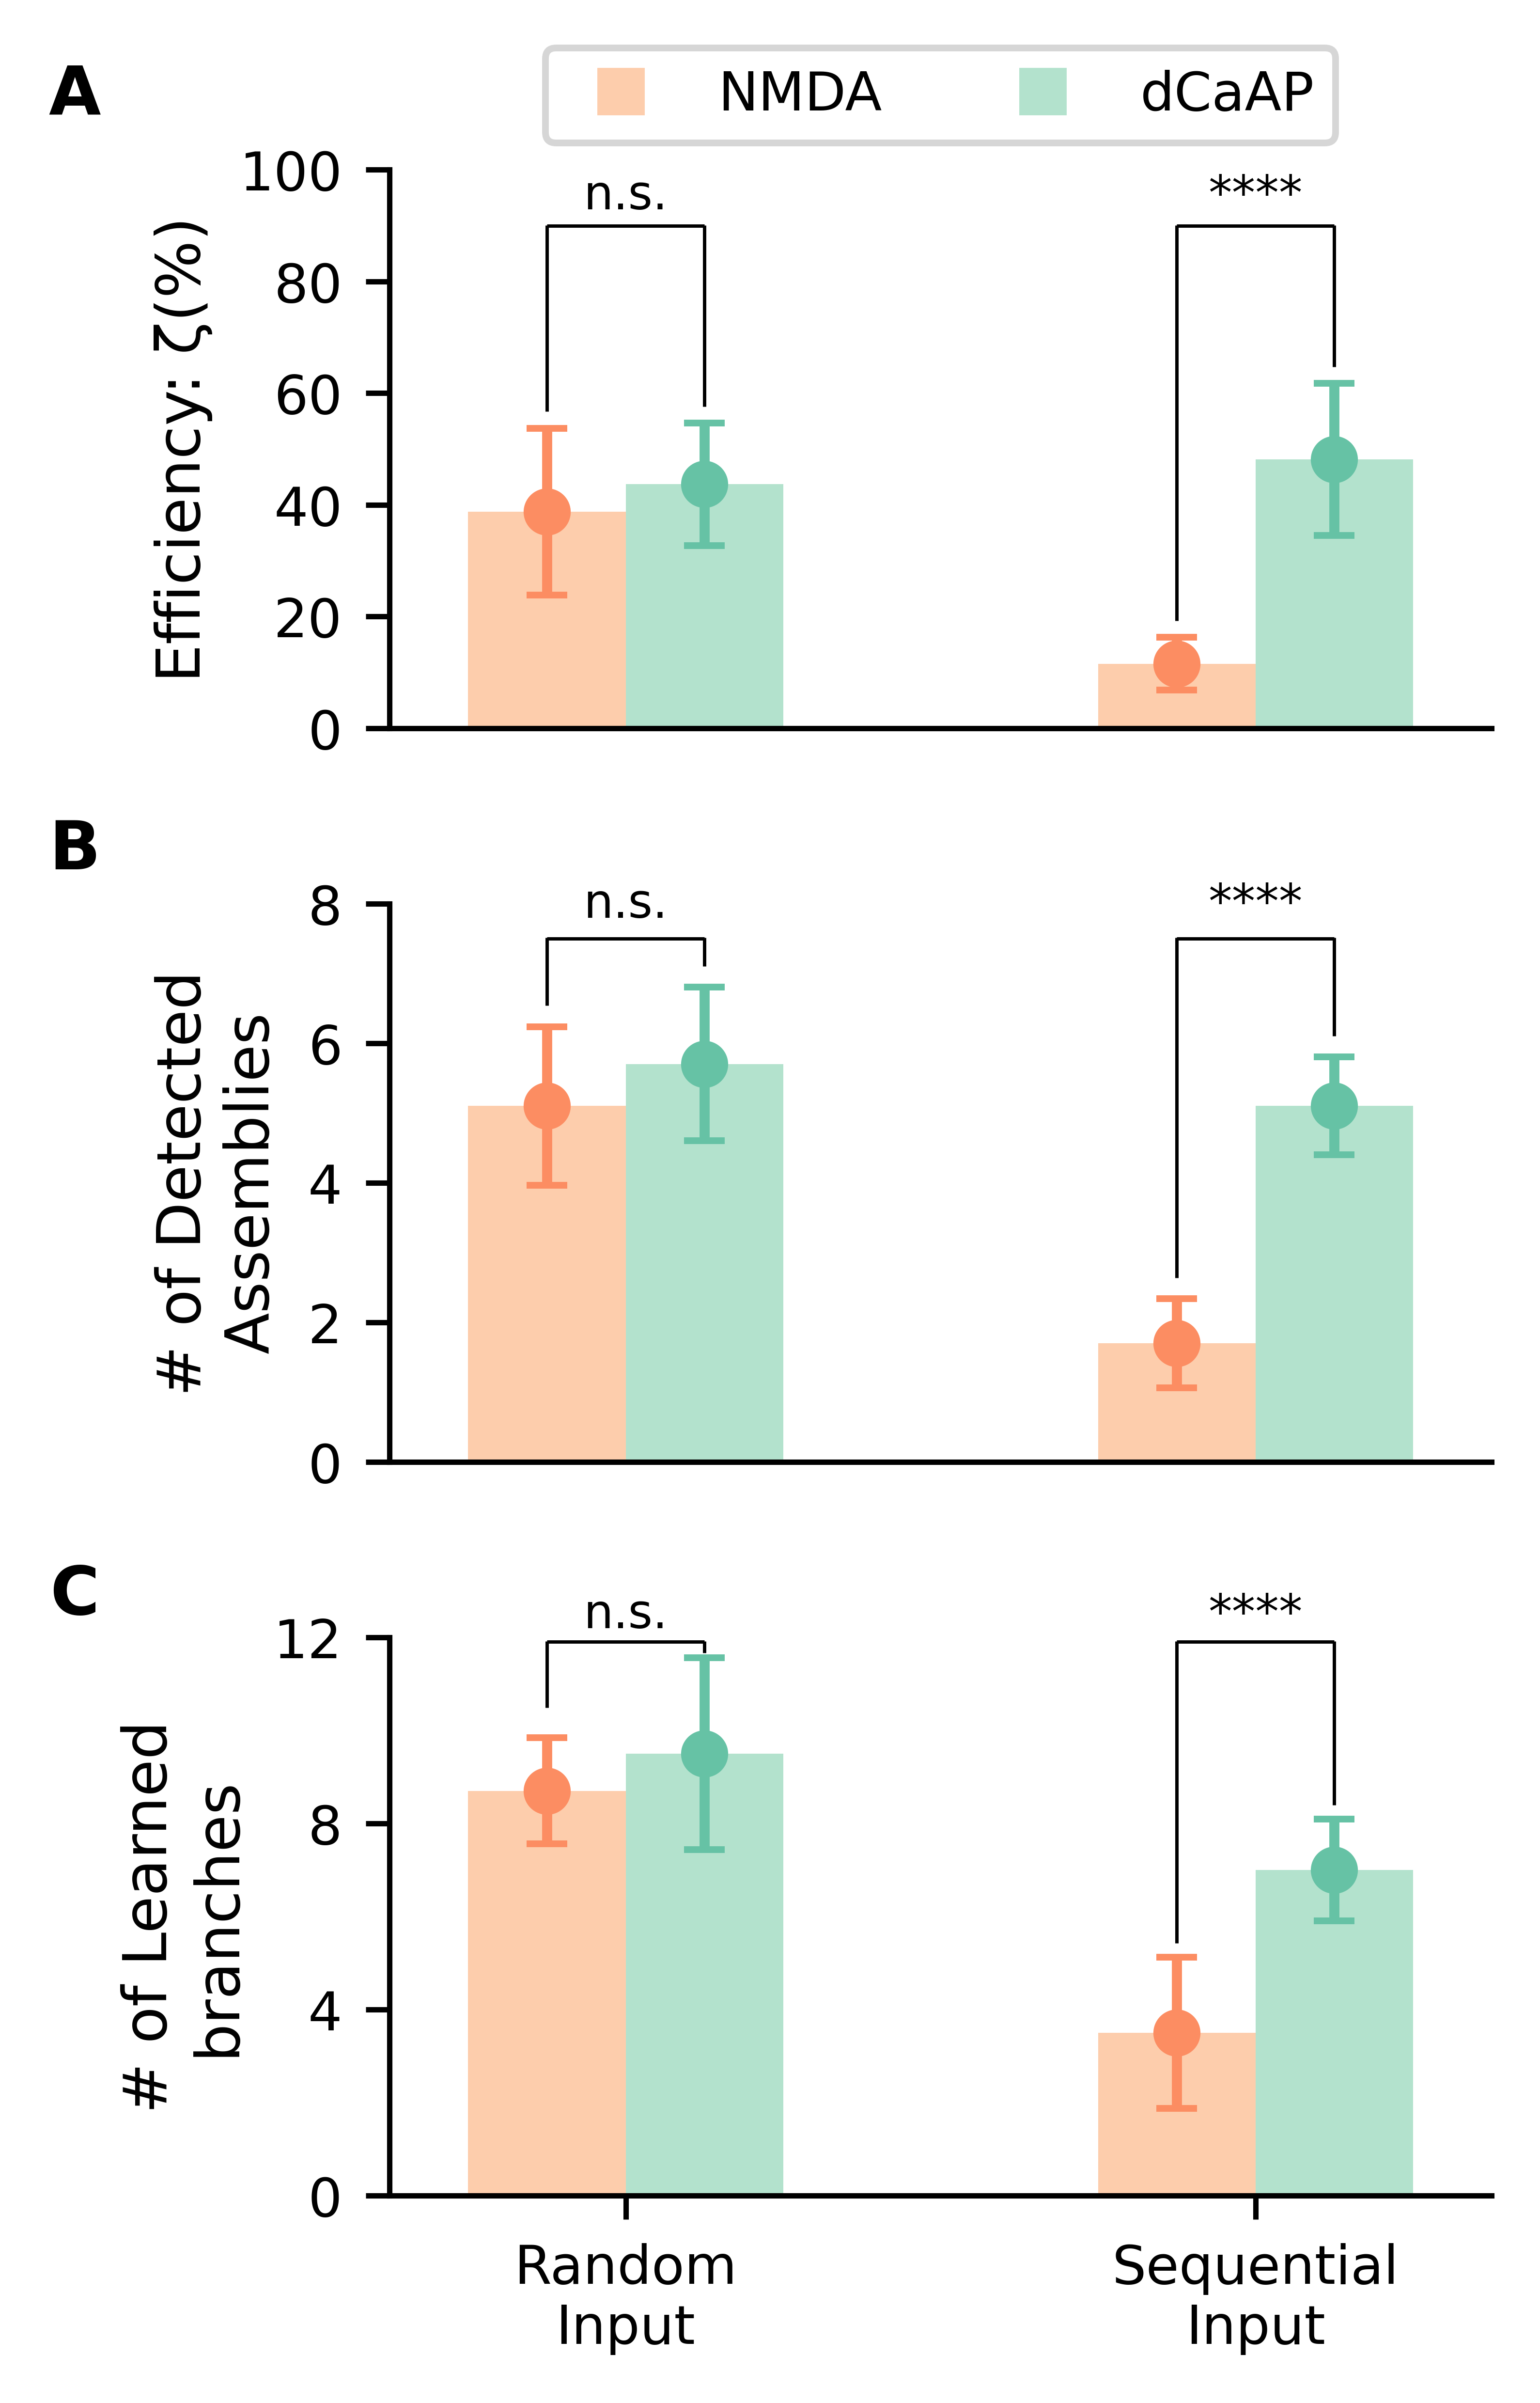

In [66]:
fig, ax = plt.subplots(3,1,figsize=(3.3, 5.0), dpi=1000)
x_pos =[[0.8,0.9],[1.2,1.3]]
x_lim = (0.7,1.4)
w = 0.1

############################################################## bottom
ax[2].text(x_pos[0][0]-.3 , 12.5, "C", ha='center', fontsize = 10,fontweight='bold')

ax[2].bar(x_pos[0][0], EXP2_dend[0],width = w,color = NMDA_color,label="NMDA")
ax[2].errorbar(x_pos[0][0], EXP2_dend[0], yerr=EXP2_assemb_err[0], fmt='o', color=NMDA_error_color, ecolor=NMDA_error_color, capsize=3, label="NMDA")

ax[2].bar(x_pos[0][1], EXP2_dend[1],width = w,color = dCaAP_color,label="dCaAP")
ax[2].errorbar(x_pos[0][1], EXP2_dend[1], yerr=EXP2_dend_err[1], fmt='o', color=dCaAP_error_color, ecolor=dCaAP_error_color, capsize=3, label="dCaAP")


ax[2].bar(x_pos[1][0], EXP3_dend[0],width = w,color = NMDA_color,label="NMDA")
ax[2].errorbar(x_pos[1][0], EXP3_dend[0], yerr=EXP3_dend_err[0], fmt='o', color=NMDA_error_color, ecolor=NMDA_error_color, capsize=3, label="NMDA")

ax[2].bar(x_pos[1][1], EXP3_dend[1],width = w,color = dCaAP_color,label="dCaAP")
ax[2].errorbar(x_pos[1][1], EXP3_dend[1], yerr=EXP3_dend_err[1], fmt='o', color=dCaAP_error_color, ecolor=dCaAP_error_color, capsize=3, label="dCaAP")


# p_value left
ax[2].hlines(11.9, x_pos[0][0],x_pos[0][1], colors='k', linestyles='-', linewidth=0.5)
ax[2].vlines(x_pos[0][0],EXP2_dend[0]+EXP2_dend_err[0]+0.3,11.91, colors='k', linestyles='-', linewidth=0.5)
ax[2].vlines(x_pos[0][1],EXP2_dend[1]+EXP2_dend_err[1]+0.1,11.91, colors='k', linestyles='-', linewidth=0.5)
ax[2].text((x_pos[0][0]+x_pos[0][1])/2, 12.2, p_value_reporting(random_dend_p), ha='center', fontsize = 7)
#####
# p_value right
ax[2].hlines(11.9, x_pos[1][0],x_pos[1][1], colors='k', linestyles='-', linewidth=0.5)
ax[2].vlines(x_pos[1][0],EXP3_dend[0]+EXP3_dend_err[0]+0.3,11.91, colors='k', linestyles='-', linewidth=0.5)
ax[2].vlines(x_pos[1][1],EXP3_dend[1]+EXP3_dend_err[1]+0.3,11.91, colors='k', linestyles='-', linewidth=0.5)
ax[2].text((x_pos[1][0]+x_pos[1][1])/2, 12.2, p_value_reporting(seq_dend_p), ha='center', fontsize = 7)
######

ax[2].set_xlim(x_lim)
ax[2].set_ylim(0,12)
ax[2].set_xticks([np.mean(x_pos[0]),np.mean(x_pos[1])],['Random\nInput' ,'Sequential\nInput'])
ax[2].set_yticks(np.arange(0,13,4))
ax[2].set_ylabel('# of Learned\nbranches')
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)

############################################################### middle
ax[1].text(x_pos[0][0]-.3 , 8.5, "B", ha='center', fontsize = 10,fontweight='bold')

ax[1].bar(x_pos[0][0], EXP2_assemb[0],width = w,color = NMDA_color,label="NMDA")
ax[1].errorbar(x_pos[0][0], EXP2_assemb[0], yerr=EXP2_assemb_err[0], fmt='o', color=NMDA_error_color, ecolor=NMDA_error_color, capsize=3, label="NMDA")

ax[1].bar(x_pos[0][1], EXP2_assemb[1],width = w,color = dCaAP_color,label="dCaAP")
ax[1].errorbar(x_pos[0][1], EXP2_assemb[1], yerr=EXP2_assemb_err[1], fmt='o', color=dCaAP_error_color, ecolor=dCaAP_error_color, capsize=3, label="dCaAP")


ax[1].bar(x_pos[1][0], EXP3_assemb[0],width = w,color = NMDA_color,label="NMDA")
ax[1].errorbar(x_pos[1][0], EXP3_assemb[0], yerr=EXP3_assemb_err[0], fmt='o', color=NMDA_error_color, ecolor=NMDA_error_color, capsize=3, label="NMDA")

ax[1].bar(x_pos[1][1], EXP3_assemb[1],width = w,color = dCaAP_color,label="dCaAP")
ax[1].errorbar(x_pos[1][1], EXP3_assemb[1], yerr=EXP3_assemb_err[1], fmt='o', color=dCaAP_error_color, ecolor=dCaAP_error_color, capsize=3, label="dCaAP")

# p_value left
ax[1].hlines(7.5, x_pos[0][0],x_pos[0][1], colors='k', linestyles='-', linewidth=0.5)
ax[1].vlines(x_pos[0][0],EXP2_assemb[0]+EXP2_assemb_err[0]+0.3,7.51, colors='k', linestyles='-', linewidth=0.5)
ax[1].vlines(x_pos[0][1],EXP2_assemb[1]+EXP2_assemb_err[1]+0.3,7.51, colors='k', linestyles='-', linewidth=0.5)
ax[1].text((x_pos[0][0]+x_pos[0][1])/2, 7.8, p_value_reporting(random_assemb_p), ha='center', fontsize = 7)
#####
# p_value right
ax[1].hlines(7.5, x_pos[1][0],x_pos[1][1], colors='k', linestyles='-', linewidth=0.5)
ax[1].vlines(x_pos[1][0],EXP3_assemb[0]+EXP3_assemb_err[0]+0.3,7.51, colors='k', linestyles='-', linewidth=0.5)
ax[1].vlines(x_pos[1][1],EXP3_assemb[1]+EXP3_assemb_err[1]+0.3,7.51, colors='k', linestyles='-', linewidth=0.5)
ax[1].text((x_pos[1][0]+x_pos[1][1])/2, 7.8, p_value_reporting(seq_assemb_p), ha='center', fontsize = 7)
######

ax[1].set_xlim(x_lim)
ax[1].set_ylim(0,8)
ax[1].set_xticks([])
ax[1].set_ylabel('# of Detected\nAssemblies')
ax[1].spines['top'].set_visible(False)
# ax[1].spines['bottom'].set_visible(False)
ax[1].spines['right'].set_visible(False)

########################################################### top
ax[0].text(x_pos[0][0]-.3 , 110, "A", ha='center', fontsize = 10,fontweight='bold')

ax[0].bar(x_pos[0][0], EXP2_eff[0],width = w,color = NMDA_color,label="NMDA")
ax[0].errorbar(x_pos[0][0], EXP2_eff[0], yerr=EXP2_eff_err[0], fmt='o', color=NMDA_error_color, ecolor=NMDA_error_color, capsize=3, label="NMDA")

ax[0].bar(x_pos[0][1], EXP2_eff[1],width = w,color = dCaAP_color,label="dCaAP")
ax[0].errorbar(x_pos[0][1], EXP2_eff[1], yerr=EXP2_eff_err[1], fmt='o', color=dCaAP_error_color, ecolor=dCaAP_error_color, capsize=3, label="dCaAP")


ax[0].bar(x_pos[1][0], EXP3_eff[0],width = w,color = NMDA_color,label="NMDA")
ax[0].errorbar(x_pos[1][0], EXP3_eff[0], yerr=EXP3_eff_err[0], fmt='o', color=NMDA_error_color, ecolor=NMDA_error_color, capsize=3, label="NMDA")

ax[0].bar(x_pos[1][1], EXP3_eff[1],width = w,color = dCaAP_color,label="dCaAP")
ax[0].errorbar(x_pos[1][1], EXP3_eff[1], yerr=EXP3_eff_err[1], fmt='o', color=dCaAP_error_color, ecolor=dCaAP_error_color, capsize=3, label="dCaAP")


ax[0].set_xlim(x_lim)
ax[0].set_ylim(0,100)
ax[0].set_xticks([])
ax[0].set_ylabel('Efficiency: \u03B6(%)')
ax[0].spines['top'].set_visible(False)
# ax[0].spines['bottom'].set_visible(False)
ax[0].spines['right'].set_visible(False)

# p_value left
ax[0].hlines(90, x_pos[0][0],x_pos[0][1], colors='k', linestyles='-', linewidth=0.5)
ax[0].vlines(x_pos[0][0],EXP2_eff[0]+EXP2_eff_err[0] + 3,90.1, colors='k', linestyles='-', linewidth=0.5)
ax[0].vlines(x_pos[0][1],EXP2_eff[1]+EXP2_eff_err[1] + 3,90.1, colors='k', linestyles='-', linewidth=0.5)
ax[0].text((x_pos[0][0]+x_pos[0][1])/2, 93, p_value_reporting(random_eff_p), ha='center', fontsize = 7)
#####
# p_value right
ax[0].hlines(90, x_pos[1][0],x_pos[1][1], colors='k', linestyles='-', linewidth=0.5)
ax[0].vlines(x_pos[1][0],EXP3_eff[0]+ EXP3_eff_err[0] + 3,90.1, colors='k', linestyles='-', linewidth=0.5)
ax[0].vlines(x_pos[1][1],EXP3_eff[1]+ EXP3_eff_err[1] + 3,90.1, colors='k', linestyles='-', linewidth=0.5)
ax[0].text((x_pos[1][0]+x_pos[1][1])/2, 93, p_value_reporting(seq_eff_p), ha='center', fontsize = 7)
######


ax[0].legend(handles=[NMDA_legend,dCaAP_legend],loc='lower center',bbox_to_anchor = (0.5,1), ncol = 2)
plt.tight_layout()


fig.savefig("Figures/pdf/Random_Sequential.pdf", format='pdf',bbox_inches='tight')
fig.savefig("Figures/svg/Random_Sequential.svg", format='svg',bbox_inches='tight')

## Results of the dCaAP model with constant dendritic spike amplitude (not graded)

In [69]:
grade_EXP3_dend =[]
grade_EXP3_dend_err=[]
grade_EXP3_assemb = []
grade_EXP3_assemb_err=[]
grade_EXP3_eff =[]
grade_EXP3_eff_err=[]

dend_list = [basic_seq_gidon_dend]
assembly_list = [basic_seq_gidon_assemb]
eff_list = [basic_seq_gidon_eff]
#################################################
exp_name = "rewiring_ex3"
exp_result_name_folder = 'Sequential_input_not_graded'
for model_name in ['Gidon_dend']:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        sep_ass = sep_ass[:len(sep_dend)]
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)

        dend_list.append(sep_dend)
        assembly_list.append(sep_ass)
        eff_list.append(eff)
        
        grade_EXP3_dend.append(np.mean(sep_dend))
        grade_EXP3_dend_err.append(np.std(sep_dend))
        grade_EXP3_assemb.append(np.mean(sep_ass))
        grade_EXP3_assemb_err.append(np.std(sep_ass))
        grade_EXP3_eff.append(np.mean(eff))
        grade_EXP3_eff_err.append(np.std(eff))

In [71]:
seq_grade_eff_p = permutation_test(eff_list[0], eff_list[1])
seq_grade_dend_p = permutation_test(dend_list[0], dend_list[1])
seq_grade_assemb_p = permutation_test(assembly_list[0], assembly_list[1])

## Results of the dCaAP model with lower Dendritic Threshold V_thr = -36 --> -55 mv

In [74]:
thr_EXP3_dend =[]
thr_EXP3_dend_err=[]
thr_EXP3_assemb = []
thr_EXP3_assemb_err=[]
thr_EXP3_eff =[]
thr_EXP3_eff_err=[]

dend_list = [basic_seq_gidon_dend]
assembly_list = [basic_seq_gidon_assemb]
eff_list = [basic_seq_gidon_eff]
#################################################
exp_name = "rewiring_ex3"
exp_result_name_folder = 'Sequential_input_d_thr'
for model_name in ['Gidon_dend']:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        sep_ass = sep_ass[:len(sep_dend)]
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)

        dend_list.append(sep_dend)
        assembly_list.append(sep_ass)
        eff_list.append(eff)
        
        thr_EXP3_dend.append(np.mean(sep_dend))
        thr_EXP3_dend_err.append(np.std(sep_dend))
        thr_EXP3_assemb.append(np.mean(sep_ass))
        thr_EXP3_assemb_err.append(np.std(sep_ass))
        thr_EXP3_eff.append(np.mean(eff))
        thr_EXP3_eff_err.append(np.std(eff))

In [76]:
seq_thr_eff_p = permutation_test(eff_list[0], eff_list[1])
seq_thr_dend_p = permutation_test(dend_list[0], dend_list[1])
seq_thr_assemb_p = permutation_test(assembly_list[0], assembly_list[1])

## Results of the dCaAP model with shorter dendritic refractory time

In [79]:
ref_EXP3_dend =[]
ref_EXP3_dend_err=[]
ref_EXP3_assemb = []
ref_EXP3_assemb_err=[]
ref_EXP3_eff =[]
ref_EXP3_eff_err=[]

dend_list = [basic_seq_gidon_dend]
assembly_list = [basic_seq_gidon_assemb]
eff_list = [basic_seq_gidon_eff]
#################################################
exp_name = "rewiring_ex3"
exp_result_name_folder = 'Sequential_input_ref'
for model_name in ['Gidon_dend']:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        sep_ass = sep_ass[:len(sep_dend)]
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)

        dend_list.append(sep_dend)
        assembly_list.append(sep_ass)
        eff_list.append(eff)
        
        ref_EXP3_dend.append(np.mean(sep_dend))
        ref_EXP3_dend_err.append(np.std(sep_dend))
        ref_EXP3_assemb.append(np.mean(sep_ass))
        ref_EXP3_assemb_err.append(np.std(sep_ass))
        ref_EXP3_eff.append(np.mean(eff))
        ref_EXP3_eff_err.append(np.std(eff))

In [81]:
seq_ref_eff_p = permutation_test(eff_list[0], eff_list[1])
seq_ref_dend_p = permutation_test(dend_list[0], dend_list[1])
seq_ref_assemb_p = permutation_test(assembly_list[0], assembly_list[1])

## Results of the dCaAP model with lower dendritic spike amplitude

In [84]:
amp_EXP3_dend =[]
amp_EXP3_dend_err=[]
amp_EXP3_assemb = []
amp_EXP3_assemb_err=[]
amp_EXP3_eff =[]
amp_EXP3_eff_err=[]

dend_list = [basic_seq_gidon_dend]
assembly_list = [basic_seq_gidon_assemb]
eff_list = [basic_seq_gidon_eff]
#################################################
exp_name = "rewiring_ex3"
exp_result_name_folder = 'Sequential_input_amp'
for model_name in ['Gidon_dend']:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        sep_ass = sep_ass[:len(sep_dend)]
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)

        dend_list.append(sep_dend)
        assembly_list.append(sep_ass)
        eff_list.append(eff)
        
        amp_EXP3_dend.append(np.mean(sep_dend))
        amp_EXP3_dend_err.append(np.std(sep_dend))
        amp_EXP3_assemb.append(np.mean(sep_ass))
        amp_EXP3_assemb_err.append(np.std(sep_ass))
        amp_EXP3_eff.append(np.mean(eff))
        amp_EXP3_eff_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/2584055424.py:44: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [86]:
seq_amp_eff_p = permutation_test(eff_list[0], eff_list[1])
seq_amp_dend_p = permutation_test(dend_list[0], dend_list[1])
seq_amp_assemb_p = permutation_test(assembly_list[0], assembly_list[1])

## plot the results of changed parameters

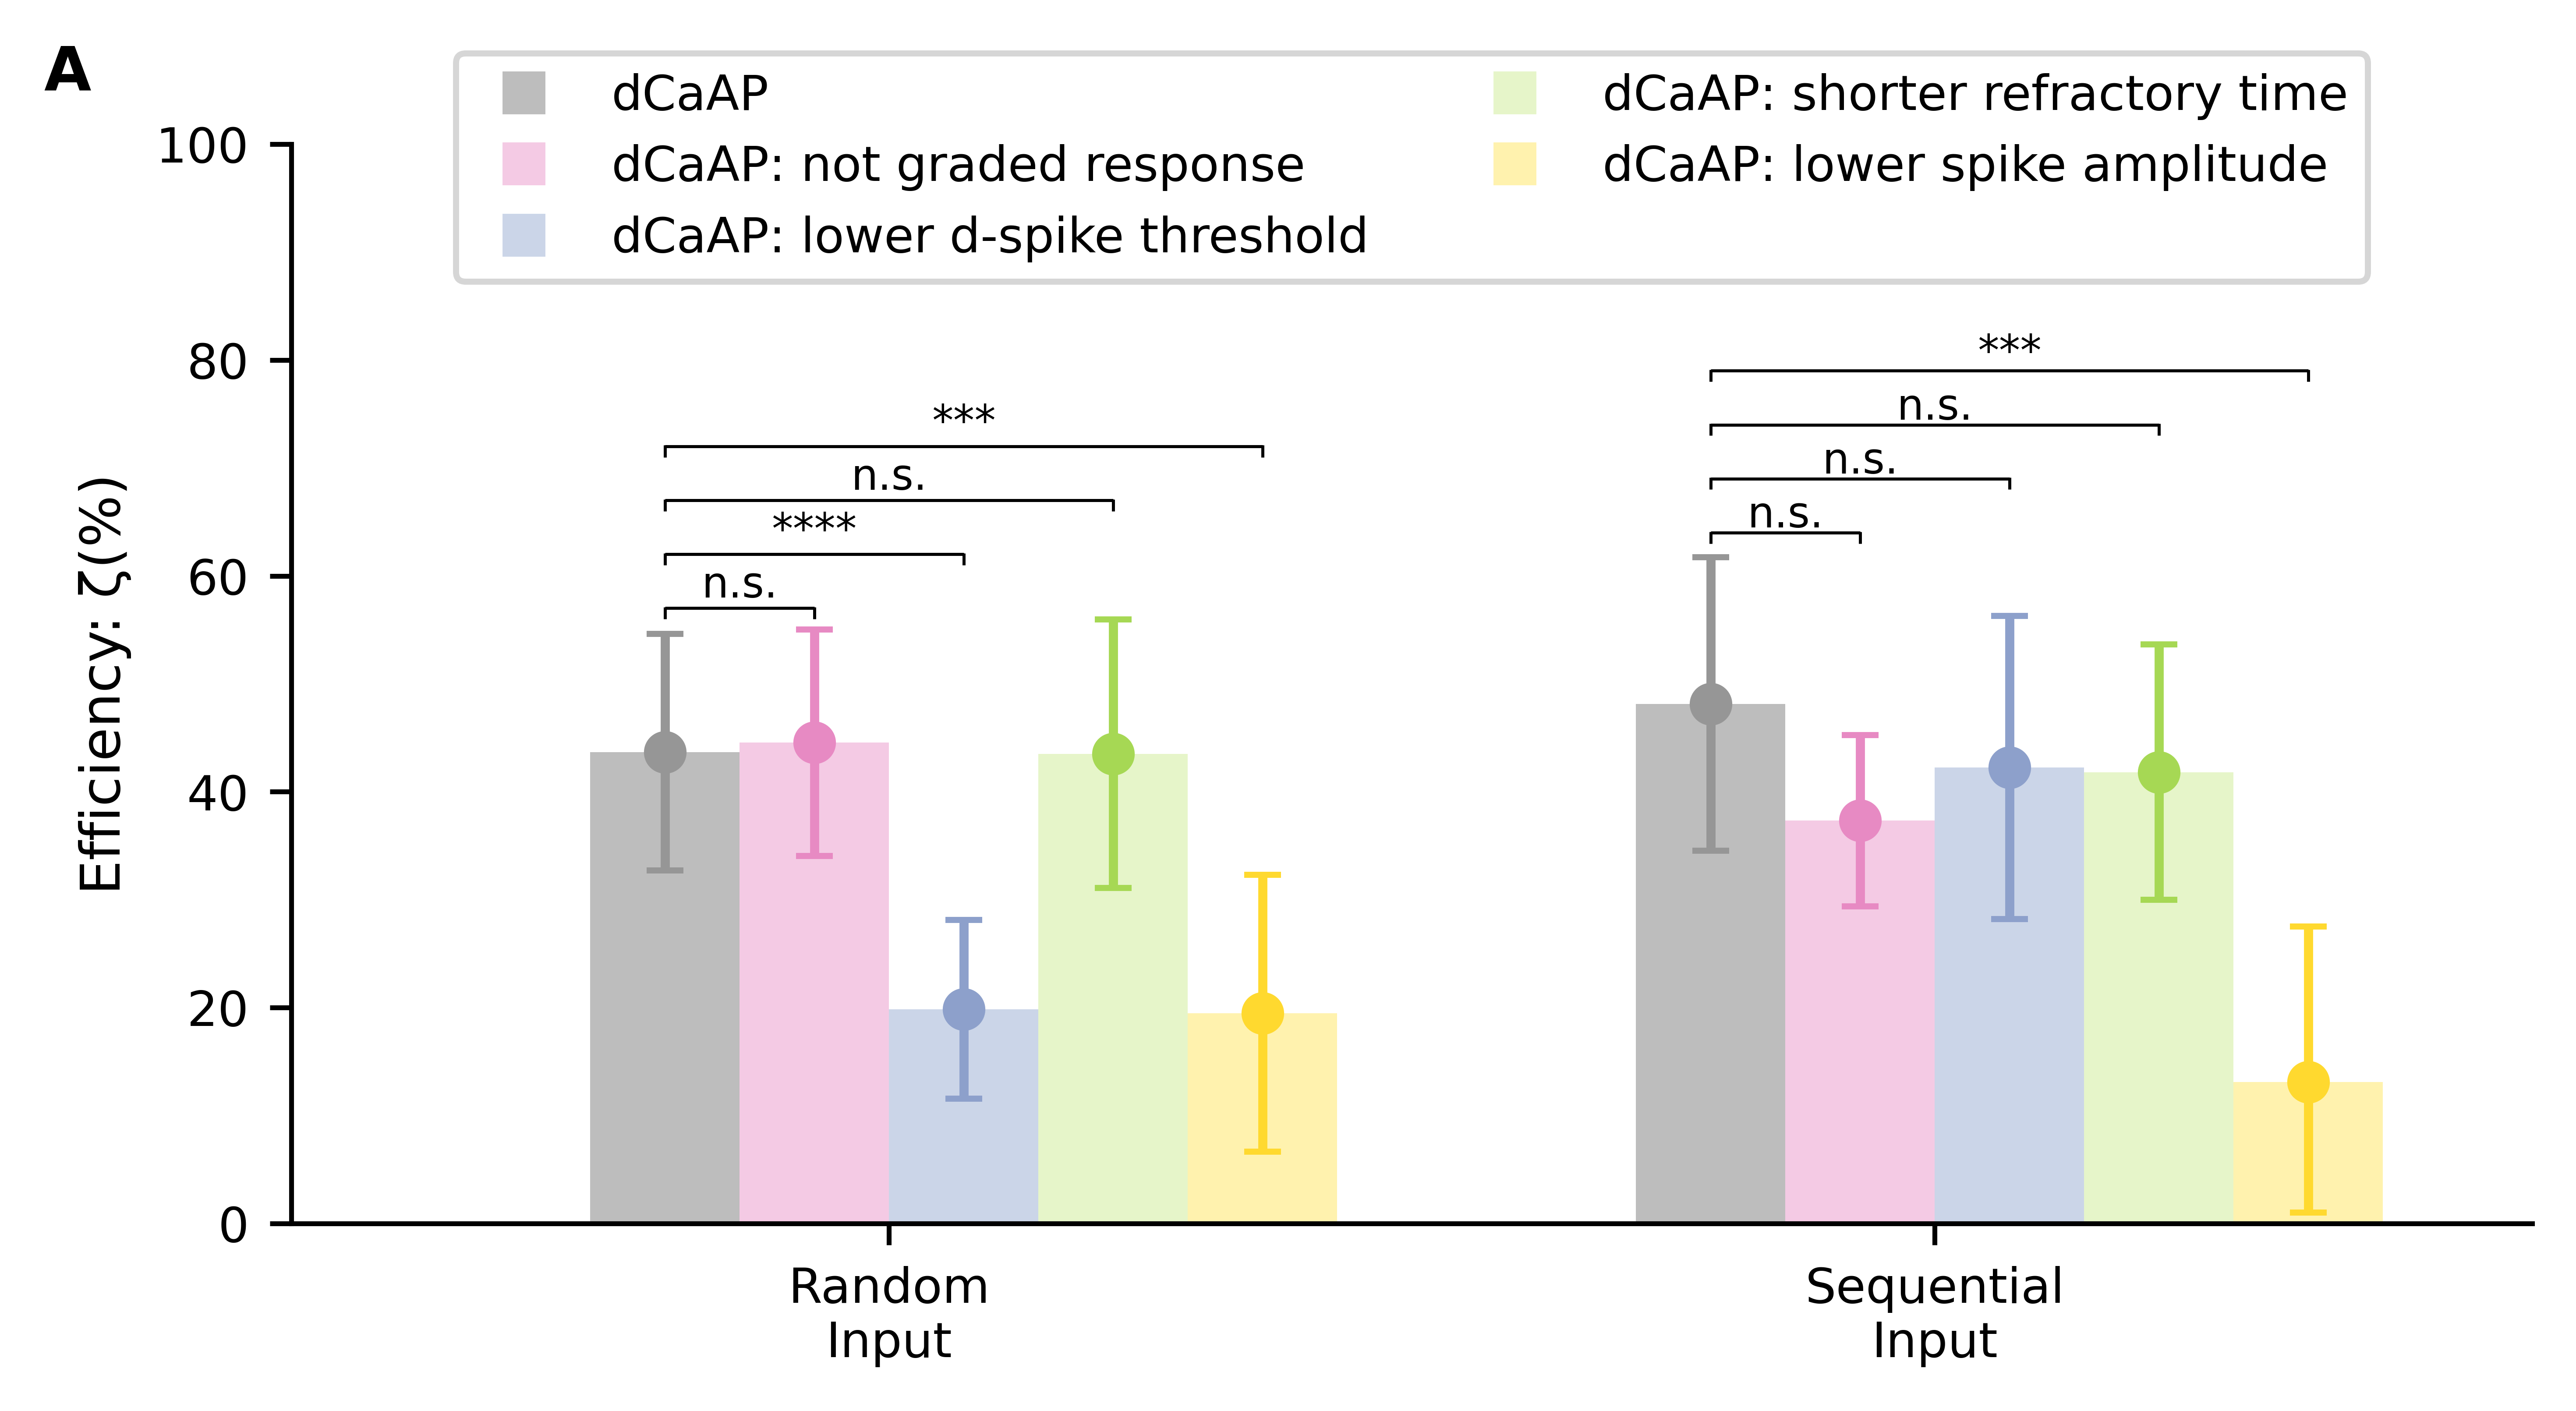

In [265]:
fig, ax = plt.subplots(figsize=(6.6, 3.2), dpi=1000)
x_pos =[[0.8,0.9,1.0,1.1,1.2,1.3],[1.5,1.6,1.7,1.8,1.9,2.0]]
w =0.1

######################################### Random input########################################
####################### Basic dCaAP
ax.bar(x_pos[0][1],EXP2_eff[1],width = w,color = dCaAP_color2,label = 'dCaAP')
ax.errorbar(x_pos[0][1],EXP2_eff[1],yerr=EXP2_eff_err[1],fmt='o',color = dCaAP_error_color2,label = 'dCaAP', capsize=3)

####################### Not graded
ax.bar(x_pos[0][2],grade_EXP2_eff[0],width = w,color = grade_color,label = 'Not_graded')
ax.errorbar(x_pos[0][2],grade_EXP2_eff[0],yerr=grade_EXP2_eff_err[0],fmt='o',color = grade_error_color,label = 'Not_graded', capsize=3)
# p_value
ax.hlines(57, x_pos[0][1],x_pos[0][2], colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[0][1],56,57.1, colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[0][2],56,57.1, colors='k', linestyles='-', linewidth=0.5)
ax.text((x_pos[0][1]+x_pos[0][2])/2, 58, p_value_reporting(random_grade_eff_p), ha='center', fontsize = 7)
#################################
####################### lower threshold
ax.bar(x_pos[0][3],thr_EXP2_eff[0],width = w,color = thr_color,label = 'Threshold')
ax.errorbar(x_pos[0][3],thr_EXP2_eff[0],yerr=thr_EXP2_eff_err[0],fmt='o',color = thr_error_color,label = 'Threshold', capsize=3)
# p_value
ax.hlines(62, x_pos[0][1],x_pos[0][3], colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[0][1],61,62.1, colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[0][3],61,62.1, colors='k', linestyles='-', linewidth=0.5)
ax.text((x_pos[0][1]+x_pos[0][3])/2, 63, p_value_reporting(random_thr_eff_p), ha='center', fontsize = 7)
#################################
####################### refractory
ax.bar(x_pos[0][4],ref_EXP2_eff[0],width = w,color = ref_color,label = 'Refractory')
ax.errorbar(x_pos[0][4],ref_EXP2_eff[0],yerr=ref_EXP2_eff_err[0],fmt='o',color = ref_error_color,label = 'Refractory', capsize=3)
# p_value
ax.hlines(67, x_pos[0][1],x_pos[0][4], colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[0][1],66,67.1, colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[0][4],66,67.1, colors='k', linestyles='-', linewidth=0.5)
ax.text((x_pos[0][1]+x_pos[0][4])/2, 68, p_value_reporting(random_ref_eff_p), ha='center', fontsize = 7)
#################################
####################### lower amplitude
ax.bar(x_pos[0][5],amp_EXP2_eff[0],width = w,color = amp_color,label = 'Amplitude')
ax.errorbar(x_pos[0][5],amp_EXP2_eff[0],yerr=amp_EXP2_eff_err[0],fmt='o',color = amp_error_color,label = 'Amplitude', capsize=3)
# p_value
ax.hlines(72, x_pos[0][1],x_pos[0][5], colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[0][1],71,72.1, colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[0][5],71,72.1, colors='k', linestyles='-', linewidth=0.5)
ax.text((x_pos[0][1]+x_pos[0][5])/2, 73, p_value_reporting(random_amp_eff_p), ha='center', fontsize = 7)
#################################


######################################### Sequential input########################################
####################### Basic dCaAP
ax.bar(x_pos[1][1],EXP3_eff[1],width = w,color = dCaAP_color2,label = 'dCaAP')
ax.errorbar(x_pos[1][1],EXP3_eff[1],yerr=EXP3_eff_err[1],fmt='o',color = dCaAP_error_color2,label = 'dCaAP', capsize=3)

####################### Not graded
ax.bar(x_pos[1][2],grade_EXP3_eff[0],width = w,color = grade_color,label = 'Not_graded')
ax.errorbar(x_pos[1][2],grade_EXP3_eff[0],yerr=grade_EXP3_eff_err[0],fmt='o',color = grade_error_color,label = 'Not_graded', capsize=3)
# p_value
ax.hlines(64, x_pos[1][1],x_pos[1][2], colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[1][1],63,64.1, colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[1][2],63,64.1, colors='k', linestyles='-', linewidth=0.5)
ax.text((x_pos[1][1]+x_pos[1][2])/2, 64.5, p_value_reporting(seq_grade_eff_p), ha='center', fontsize = 7)
#################################
####################### lower threshold
ax.bar(x_pos[1][3],thr_EXP3_eff[0],width = w,color = thr_color,label = 'Threshold')
ax.errorbar(x_pos[1][3],thr_EXP3_eff[0],yerr = thr_EXP3_eff_err[0],fmt='o',color = thr_error_color,label = 'Threshold', capsize=3)

# p_value
ax.hlines(69, x_pos[1][1],x_pos[1][3], colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[1][1],68,69.1, colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[1][3],68,69.1, colors='k', linestyles='-', linewidth=0.5)
ax.text((x_pos[1][1]+x_pos[1][3])/2, 69.5, p_value_reporting(seq_thr_eff_p), ha='center', fontsize = 7)
#################################
####################### refractory
ax.bar(x_pos[1][4],ref_EXP3_eff[0],width = w,color = ref_color,label = 'Refractory')
ax.errorbar(x_pos[1][4],ref_EXP3_eff[0],yerr = ref_EXP3_eff_err[0],fmt='o',color = ref_error_color,label = 'Refractory', capsize=3)

# p_value
ax.hlines(74, x_pos[1][1],x_pos[1][4], colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[1][1],73,74.1, colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[1][4],73,74.1, colors='k', linestyles='-', linewidth=0.5)
ax.text((x_pos[1][1]+x_pos[1][4])/2, 74.5, p_value_reporting(seq_ref_eff_p), ha='center', fontsize = 7)
#################################
####################### lower amplitude
ax.bar(x_pos[1][5],amp_EXP3_eff[0],width = w,color = amp_color,label = 'Amplitude')
lower_err = np.minimum(amp_EXP3_eff_err[0], amp_EXP3_eff[0])  # clip so it never goes below zero
upper_err = amp_EXP3_eff_err[0]
yerr = [[lower_err-1], [upper_err]]

ax.errorbar(x_pos[1][5],amp_EXP3_eff[0],yerr = yerr,fmt='o',color = amp_error_color,label = 'Amplitude', capsize=3)
# p_value
ax.hlines(79, x_pos[1][1],x_pos[1][5], colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[1][1],78,79.1, colors='k', linestyles='-', linewidth=0.5)
ax.vlines(x_pos[1][5],78,79.1, colors='k', linestyles='-', linewidth=0.5)
ax.text((x_pos[1][1]+x_pos[1][5])/2, 79.5, p_value_reporting(seq_amp_eff_p), ha='center', fontsize = 7)
#################################

# ax.legend()
ax.set_ylim(0,100)
ax.set_xlim(0.65,2.15)
ax.set_xticks([np.mean(x_pos[0]),np.mean(x_pos[1])],['Random\nInput','Sequential\nInput'])
ax.set_ylabel('Efficiency: \u03B6(%)')

ax.text(0.5, 105, "A", ha='center', fontsize = 10,fontweight='bold')

ax.legend(handles=[dCaAP_legend2,grade_legend,thr_legend,ref_legend,amp_legend],loc='lower center',bbox_to_anchor = (0.5,0.85), ncol = 2)
#########

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_bounds(0, 100)

        
        
#######
fig.savefig("Figures/pdf/changed_random_sequential.pdf", format='pdf',bbox_inches='tight')
fig.savefig("Figures/svg/changed_random_sequential.svg", format='svg',bbox_inches='tight')

## Results for the Sequential input model without structural plasctisity

In [106]:
str_EXP3_dend =[]
str_EXP3_dend_err=[]
str_EXP3_assemb = []
str_EXP3_assemb_err=[]
str_EXP3_eff =[]
str_EXP3_eff_err=[]

seq_str_dend_list = []
seq_str_assembly_list = []
seq_str_eff_list = []
#################################################
exp_name = "rewiring_ex3"
exp_result_name_folder = 'Sequential_input_no_str'
for model_name in ['Limbacher','Gidon_dend']:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        sep_ass = sep_ass[:len(sep_dend)]
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)

        seq_str_dend_list.append(sep_dend)
        seq_str_assembly_list.append(sep_ass)
        seq_str_eff_list.append(eff)
        
        str_EXP3_dend.append(np.mean(sep_dend))
        str_EXP3_dend_err.append(np.std(sep_dend))
        str_EXP3_assemb.append(np.mean(sep_ass))
        str_EXP3_assemb_err.append(np.std(sep_ass))
        str_EXP3_eff.append(np.mean(eff))
        str_EXP3_eff_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/1656695252.py:44: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [108]:
seq_str_eff_p = [permutation_test(seq_str_eff_list[0], basic_seq_limb_eff),permutation_test(seq_str_eff_list[1], basic_seq_gidon_eff)]
seq_str_eff_p

[0.0003, 0.0004]

## Results for the Sequential input model without functional plasctisity

In [111]:
func_EXP3_dend =[]
func_EXP3_dend_err=[]
func_EXP3_assemb = []
func_EXP3_assemb_err=[]
func_EXP3_eff =[]
func_EXP3_eff_err=[]

seq_func_dend_list = []
seq_func_assembly_list = []
seq_func_eff_list = []
#################################################
exp_name = "rewiring_ex3"
exp_result_name_folder = 'Sequential_input_no_func'
for model_name in ['Limbacher','Gidon_dend']:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        sep_ass = sep_ass[:len(sep_dend)]
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)

        seq_func_dend_list.append(sep_dend)
        seq_func_assembly_list.append(sep_ass)
        seq_func_eff_list.append(eff)
        
        func_EXP3_dend.append(np.mean(sep_dend))
        func_EXP3_dend_err.append(np.std(sep_dend))
        func_EXP3_assemb.append(np.mean(sep_ass))
        func_EXP3_assemb_err.append(np.std(sep_ass))
        func_EXP3_eff.append(np.mean(eff))
        func_EXP3_eff_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/505397533.py:44: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [113]:
seq_func_eff_p = [permutation_test(seq_func_eff_list[0], basic_seq_limb_eff),permutation_test(seq_func_eff_list[1], basic_seq_gidon_eff)]
seq_func_eff_p

[0.0, 0.0]

## Results for the Sequential input model without stdp plasctisity

In [116]:
stdp_EXP3_dend =[]
stdp_EXP3_dend_err=[]
stdp_EXP3_assemb = []
stdp_EXP3_assemb_err=[]
stdp_EXP3_eff =[]
stdp_EXP3_eff_err=[]

seq_stdp_dend_list = []
seq_stdp_assembly_list = []
seq_stdp_eff_list = []
#################################################
exp_name = "rewiring_ex3"
exp_result_name_folder = 'Sequential_input_no_stdp'
for model_name in ['Limbacher','Gidon_dend']:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        sep_ass = sep_ass[:len(sep_dend)]
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)

        seq_stdp_dend_list.append(sep_dend)
        seq_stdp_assembly_list.append(sep_ass)
        seq_stdp_eff_list.append(eff)
        
        stdp_EXP3_dend.append(np.mean(sep_dend))
        stdp_EXP3_dend_err.append(np.std(sep_dend))
        stdp_EXP3_assemb.append(np.mean(sep_ass))
        stdp_EXP3_assemb_err.append(np.std(sep_ass))
        stdp_EXP3_eff.append(np.mean(eff))
        stdp_EXP3_eff_err.append(np.std(eff))

In [118]:
seq_stdp_eff_p = [permutation_test(seq_stdp_eff_list[0], basic_seq_limb_eff),permutation_test(seq_stdp_eff_list[1], basic_seq_gidon_eff)]
seq_stdp_eff_p

[0.0358, 0.007]

# Co-active Assemblies

## Basic

In [122]:
EXP4_dend_limb =[EXP2_dend[0]]
EXP4_dend_limb_err=[EXP2_dend_err[0]]
EXP4_assemb_limb = [EXP2_assemb[0]]
EXP4_assemb_limb_err=[EXP2_assemb_err[0]]
EXP4_eff_limb =[EXP2_eff[0]]
EXP4_eff_limb_err=[EXP2_eff_err[0]]

coactive_limb_dend_list = [basic_random_limb_dend]
coactive_limb_assembly_list = [basic_random_limb_assemb]
coactive_limb_eff_list = [basic_random_limb_eff]
#####################
EXP4_dend_gid =[EXP2_dend[1]]
EXP4_dend_gid_err=[EXP2_dend_err[1]]
EXP4_assemb_gid = [EXP2_assemb[1]]
EXP4_assemb_gid_err=[EXP2_assemb_err[1]]
EXP4_eff_gid =[EXP2_eff[1]]
EXP4_eff_gid_err=[EXP2_eff_err[1]]

coactive_gidon_dend_list = [basic_random_gidon_dend]
coactive_gidon_assembly_list = [basic_random_gidon_assemb]
coactive_gidon_eff_list = [basic_random_gidon_eff]
#################################################
exp_name = "rewiring_ex4"
exp_result_name_folder_list = ['coactive2','coactive3','coactive4','coactive5','coactive6','coactive7','coactive8']

for model_name in ['Limbacher','Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Limbacher":
            
            coactive_limb_dend_list.append(sep_dend)
            coactive_limb_assembly_list.append(sep_ass)
            coactive_limb_eff_list.append(eff)
            
            EXP4_dend_limb.append(np.mean(sep_dend))
            EXP4_dend_limb_err.append(np.std(sep_dend))
            EXP4_assemb_limb.append(np.mean(sep_ass))
            EXP4_assemb_limb_err.append(np.std(sep_ass))
            EXP4_eff_limb.append(np.mean(eff))
            EXP4_eff_limb_err.append(np.std(eff))
        elif model_name == "Gidon_dend":
            
            coactive_gidon_dend_list.append(sep_dend)
            coactive_gidon_assembly_list.append(sep_ass)
            coactive_gidon_eff_list.append(eff)

            
            EXP4_dend_gid.append(np.mean(sep_dend))
            EXP4_dend_gid_err.append(np.std(sep_dend))
            EXP4_assemb_gid.append(np.mean(sep_ass))
            EXP4_assemb_gid_err.append(np.std(sep_ass))
            EXP4_eff_gid.append(np.mean(eff))
            EXP4_eff_gid_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/304041704.py:58: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


## Number of Detected Assemblies

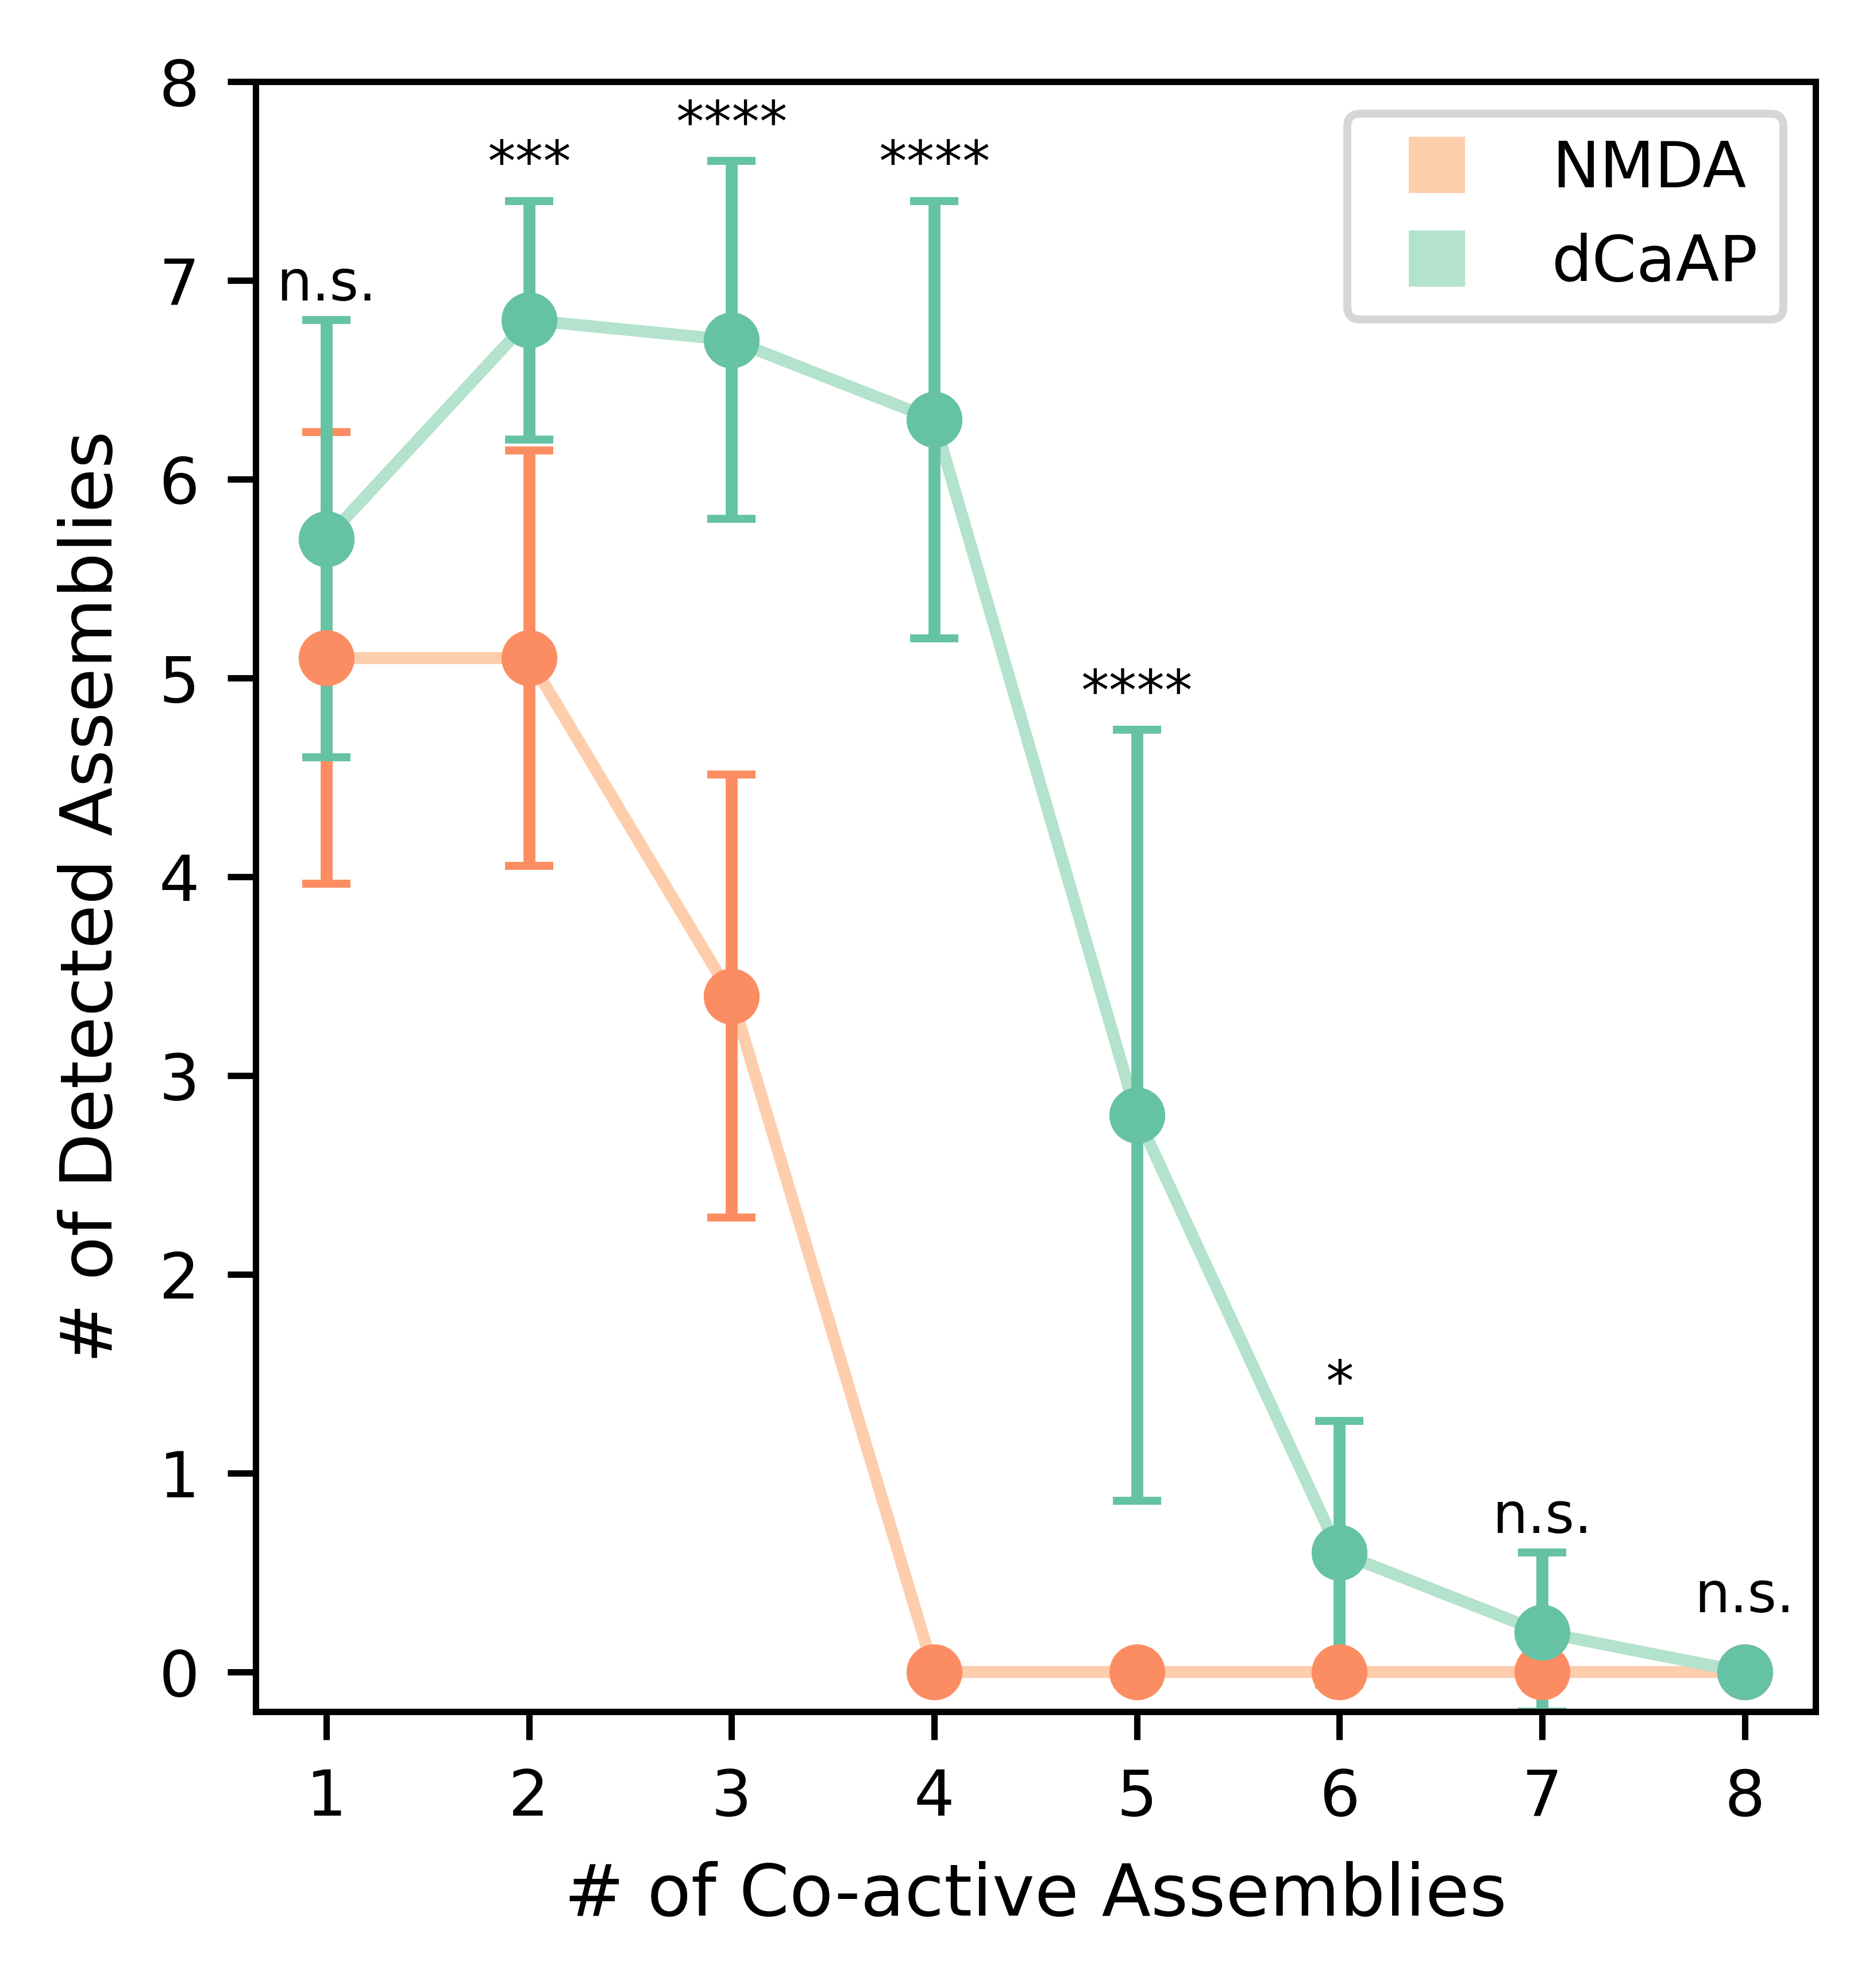

In [130]:
coactive = np.arange(1,9)

fig, ax = plt.subplots(figsize=(3.3, 3.5), dpi=1000)
ax.plot(coactive[0],EXP4_assemb_limb[0],color=NMDA_color,linestyle = '-',label="NMDA spike model" )
ax.plot(coactive[0],EXP4_assemb_gid[0],color=dCaAP_color,linestyle = '-',label="number of detected assemblies" )

ax.plot(coactive[:len(EXP4_dend_limb)],EXP4_assemb_limb,color=NMDA_color)
ax.errorbar(coactive[:len(EXP4_dend_limb)], EXP4_assemb_limb, yerr=EXP4_assemb_limb_err, fmt="o", color=NMDA_error_color,capsize = 3)


ax.plot(coactive,EXP4_assemb_gid,color=dCaAP_color)
ax.errorbar(coactive, EXP4_assemb_gid, yerr=EXP4_assemb_gid_err, fmt="o", color=dCaAP_error_color,capsize = 3)


# p_values
for n_coactive in coactive:
    ax.text(n_coactive, max(EXP4_assemb_gid_err[n_coactive-1]+EXP4_assemb_gid[n_coactive-1], EXP4_assemb_limb_err[n_coactive-1]+EXP4_assemb_limb[n_coactive-1],0.2) +.1, p_value_reporting(permutation_test(coactive_limb_assembly_list[n_coactive-1], coactive_gidon_assembly_list[n_coactive-1])), ha='center', fontsize = 7)
######

#########
ax.set_xlabel("# of Co-active Assemblies")
plt.xticks(range(1,9))
plt.yticks()
ax.set_ylabel("# of Detected Assemblies")
plt.ylim(-0.2,8)



ax.legend(handles=[NMDA_legend,dCaAP_legend],loc='upper right')

plt.tight_layout()
# plt.show()
fig.savefig("Figures/pdf/coactive_detected_assemblies.pdf", format='pdf',bbox_inches='tight')
fig.savefig("Figures/svg/coactive_detected_assemblies.svg", format='svg',bbox_inches='tight')

## Efficiency

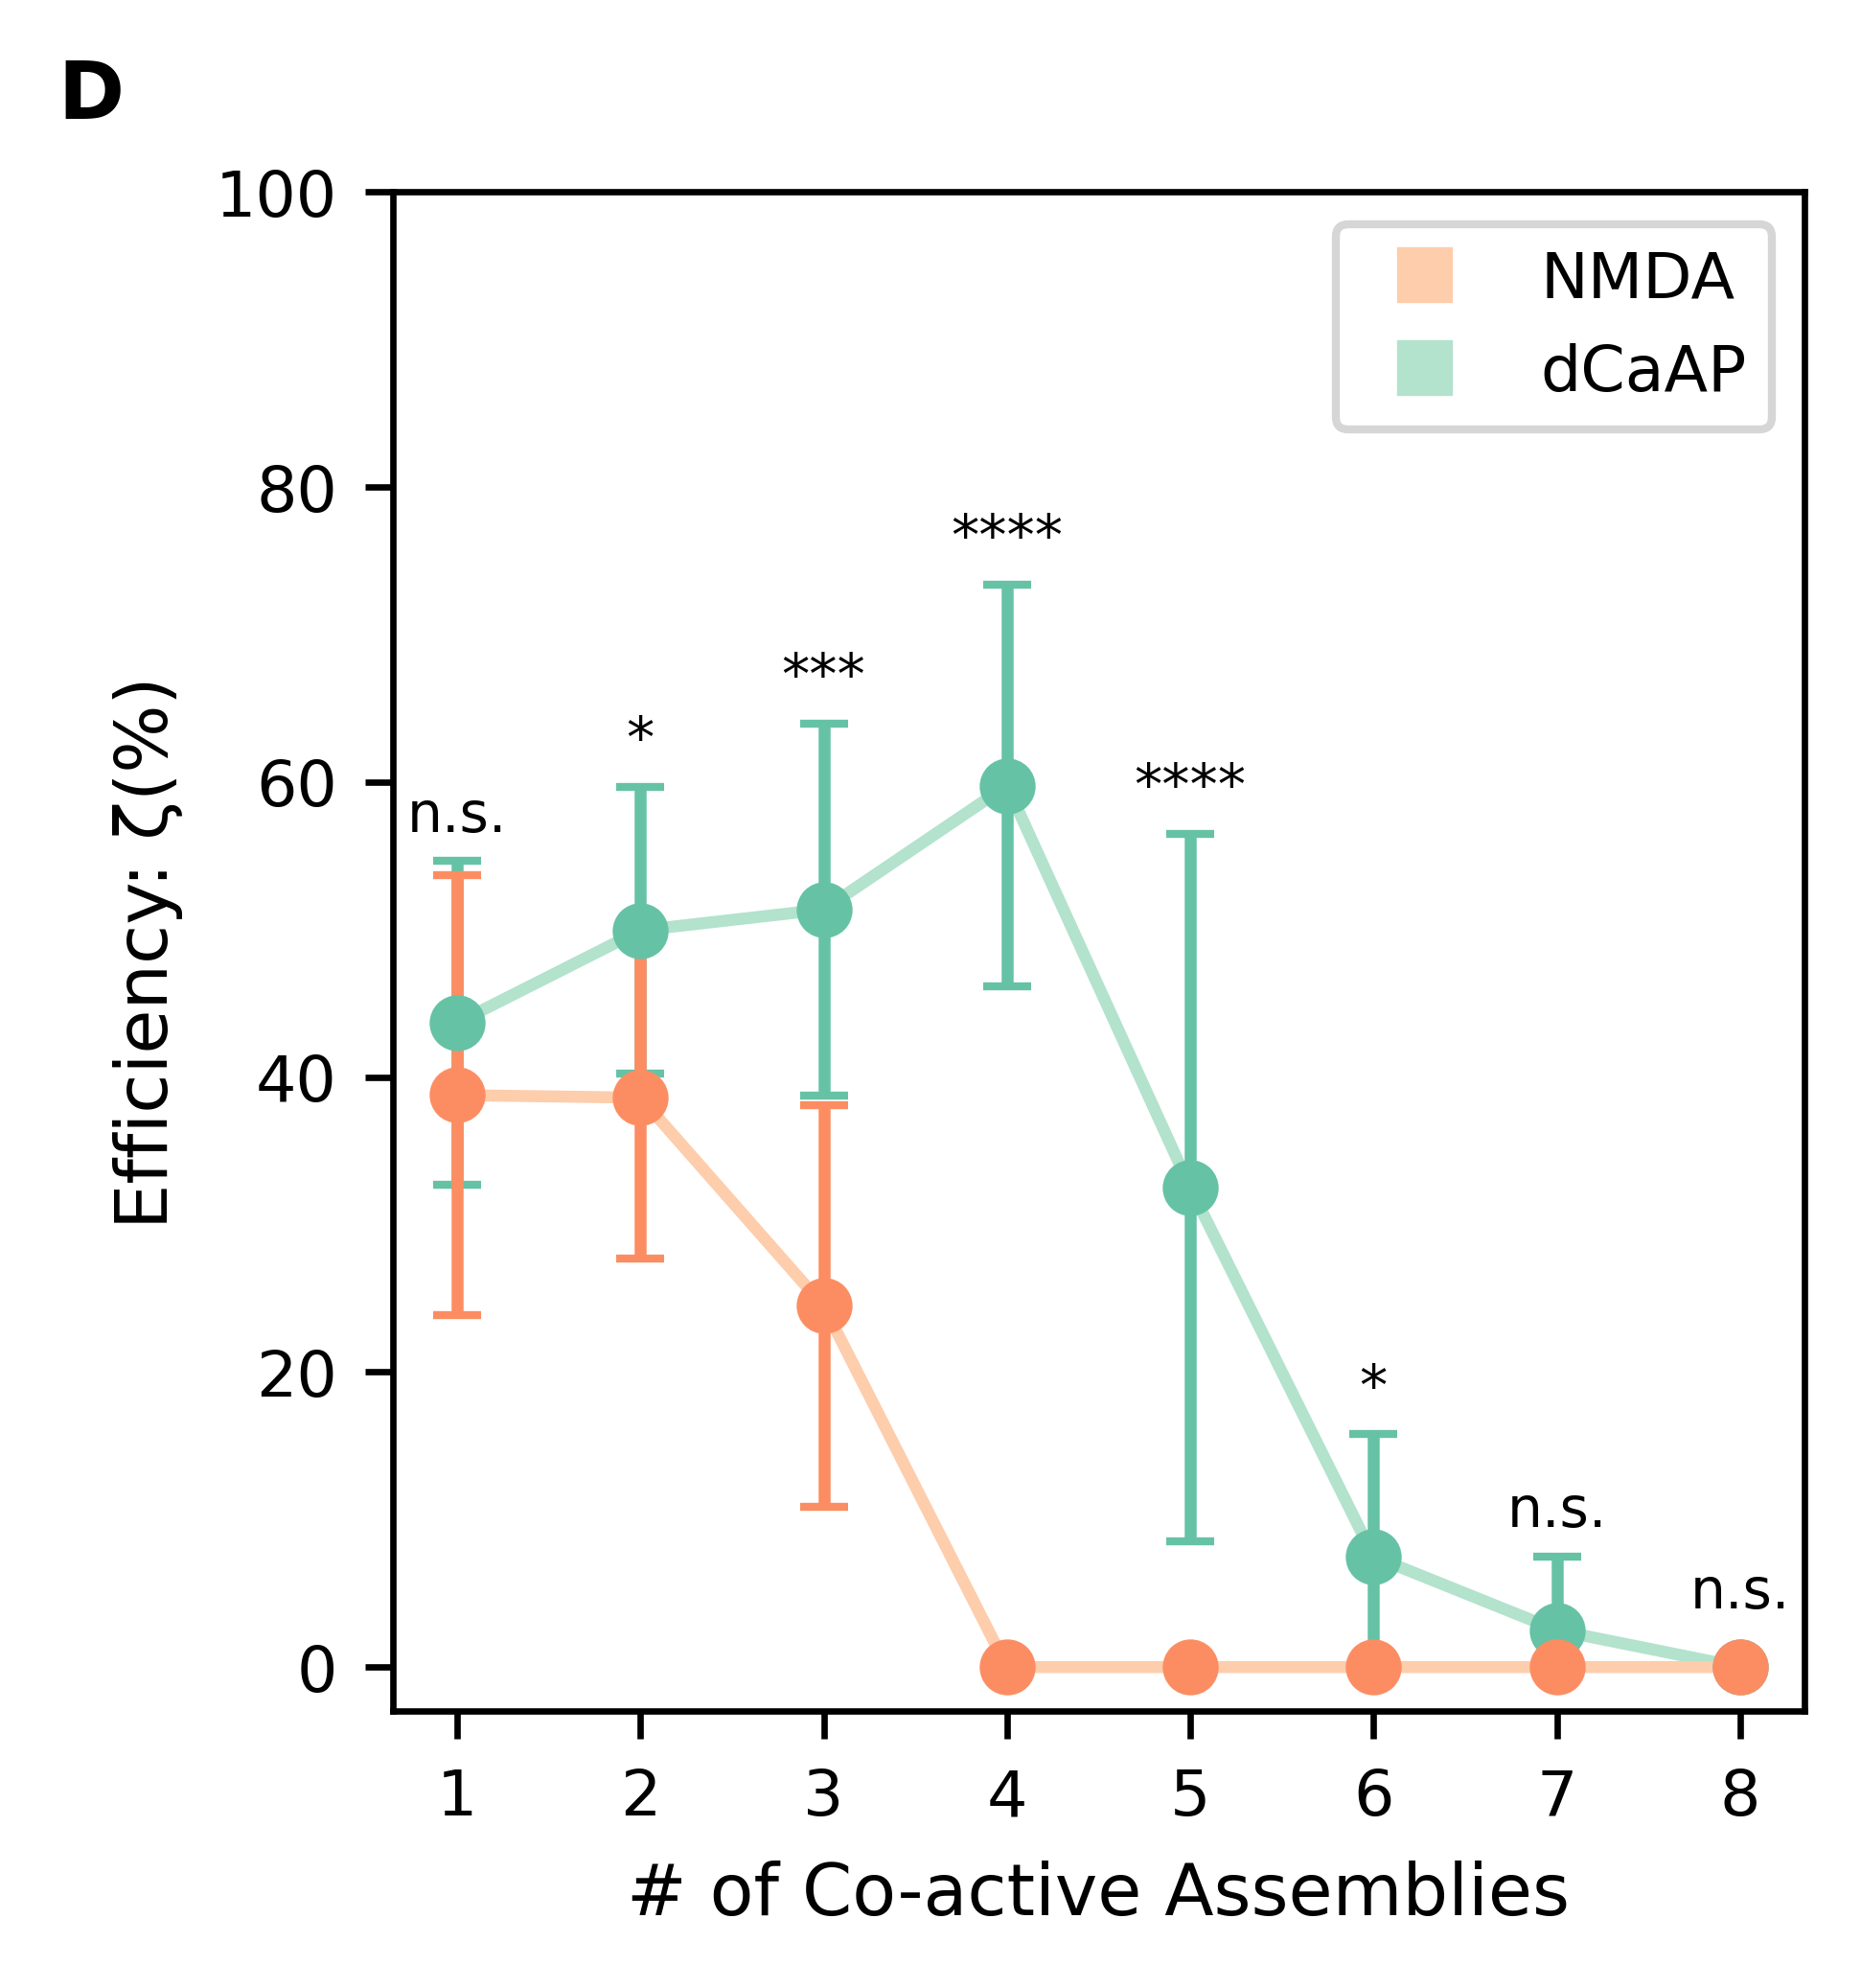

In [132]:
coactive = np.arange(1,9)


fig, ax = plt.subplots(figsize=(3.3, 3.5), dpi=600)
ax.set_ylim(-3,100)


ax.plot(coactive,EXP4_eff_gid,color=dCaAP_color,label="dCaAP")
lower_err = np.minimum(EXP4_eff_gid_err, EXP4_eff_gid)  # clip so it never goes below zero
upper_err = EXP4_eff_gid_err
yerr = [lower_err, upper_err]
ax.errorbar(coactive, EXP4_eff_gid, yerr=yerr, fmt="o", color=dCaAP_error_color,capsize = 3)


ax.plot(coactive,EXP4_eff_limb,color=NMDA_color,label="NMDA")
lower_err = np.minimum(EXP4_eff_limb_err, EXP4_eff_limb)  # clip so it never goes below zero
upper_err = EXP4_eff_limb_err
yerr = [lower_err, upper_err]
ax.errorbar(coactive, EXP4_eff_limb, yerr=yerr, fmt="o", color=NMDA_error_color,capsize = 3)


# p_values
for n_coactive in coactive:
    ax.text(n_coactive, max(EXP4_eff_gid_err[n_coactive-1]+EXP4_eff_gid[n_coactive-1], EXP4_eff_limb_err[n_coactive-1]+EXP4_eff_limb[n_coactive-1], 2) + 2, p_value_reporting(permutation_test(coactive_limb_eff_list[n_coactive-1], coactive_gidon_eff_list[n_coactive-1])), ha='center', fontsize = 7)
######

ax.set_ylabel("Efficiency: \u03B6(%)")

ax.set_xlabel("# of Co-active Assemblies")
plt.xticks(range(1,9))
plt.yticks()


ax.legend(handles=[NMDA_legend,dCaAP_legend],loc='upper right')
ax.text(-1, 105, "D", ha='center', fontsize = 10,fontweight='bold')

plt.tight_layout()
# plt.show()
fig.savefig("Figures/pdf/coactive_efficiencies.pdf", format='pdf',bbox_inches='tight')
fig.savefig("Figures/svg/coactive_efficiencies.svg", format='svg',bbox_inches='tight')

## Results of the dCaAP model with constant dendritic spike amplitude (not graded)

In [135]:
grade_EXP4_dend_gid =[grade_EXP2_dend[0]]
grade_EXP4_dend_gid_err=[grade_EXP2_dend_err[0]]
grade_EXP4_assemb_gid = [grade_EXP2_assemb[0]]
grade_EXP4_assemb_gid_err=[grade_EXP2_assemb_err[0]]
grade_EXP4_eff_gid =[grade_EXP2_eff[0]]
grade_EXP4_eff_gid_err=[grade_EXP2_eff_err[0]]



exp4_grade_dend_list = []
exp4_grade_assembly_list = []
exp4_grade_eff_list = []
#################################################
exp_name = "rewiring_ex4"
exp_result_name_folder_list = ['not_graded_coactive2','not_graded_coactive3','not_graded_coactive4',
                               'not_graded_coactive5','not_graded_coactive6','not_graded_coactive7',
                               'not_graded_coactive8']

for model_name in ['Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Gidon_dend":
            
            exp4_grade_dend_list.append(sep_dend)
            exp4_grade_assembly_list.append(sep_ass)
            exp4_grade_eff_list.append(eff)
            
            grade_EXP4_dend_gid.append(np.mean(sep_dend))
            grade_EXP4_dend_gid_err.append(np.std(sep_dend))
            grade_EXP4_assemb_gid.append(np.mean(sep_ass))
            grade_EXP4_assemb_gid_err.append(np.std(sep_ass))
            grade_EXP4_eff_gid.append(np.mean(eff))
            grade_EXP4_eff_gid_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/4070007683.py:51: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [137]:
coactive_grade_eff_p = [permutation_test(exp4_grade_eff_list[i], coactive_gidon_eff_list[i+1]) for i in range(7) ]
coactive_grade_dend_p = [permutation_test(exp4_grade_dend_list[i], coactive_gidon_dend_list[i+1])  for i in range(7) ]
coactive_grade_assemb_p = [permutation_test(exp4_grade_assembly_list[i], coactive_gidon_assembly_list[i+1])  for i in range(7) ]

coactive_grade_eff_p.insert(0,random_grade_eff_p)
coactive_grade_dend_p.insert(0,random_grade_dend_p)
coactive_grade_assemb_p.insert(0,random_grade_assemb_p)

coactive_grade_eff_p

[0.861, 0.413, 0.4902, 0.1145, 0.0015, 0.0341, 0.4769, 1.0]

## Results of the dCaAP model with lower Dendritic Threshold V_thr = -36 --> -55 mv

In [140]:
thr_EXP4_dend_gid =[thr_EXP2_dend[0]]
thr_EXP4_dend_gid_err=[thr_EXP2_dend_err[0]]
thr_EXP4_assemb_gid = [thr_EXP2_assemb[0]]
thr_EXP4_assemb_gid_err=[thr_EXP2_assemb_err[0]]
thr_EXP4_eff_gid =[thr_EXP2_eff[0]]
thr_EXP4_eff_gid_err=[thr_EXP2_eff_err[0]]


exp4_thr_dend_list = []
exp4_thr_assembly_list = []
exp4_thr_eff_list = []

#################################################
exp_name = "rewiring_ex4"
exp_result_name_folder_list = ['d_thr_coactive2','d_thr_coactive3','d_thr_coactive4','d_thr_coactive5','d_thr_coactive6','d_thr_coactive7','d_thr_coactive8']

for model_name in ['Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Gidon_dend":

            exp4_thr_dend_list.append(sep_dend)
            exp4_thr_assembly_list.append(sep_ass)
            exp4_thr_eff_list.append(eff)
        
            thr_EXP4_dend_gid.append(np.mean(sep_dend))
            thr_EXP4_dend_gid_err.append(np.std(sep_dend))
            thr_EXP4_assemb_gid.append(np.mean(sep_ass))
            thr_EXP4_assemb_gid_err.append(np.std(sep_ass))
            thr_EXP4_eff_gid.append(np.mean(eff))
            thr_EXP4_eff_gid_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/2817830980.py:49: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [142]:
coactive_thr_eff_p = [permutation_test(exp4_thr_eff_list[i], coactive_gidon_eff_list[i+1]) for i in range(7) ]
coactive_thr_dend_p = [permutation_test(exp4_thr_dend_list[i], coactive_gidon_dend_list[i+1])  for i in range(7) ]
coactive_thr_assemb_p = [permutation_test(exp4_thr_assembly_list[i], coactive_gidon_assembly_list[i+1])  for i in range(7) ]

coactive_thr_eff_p.insert(0,random_thr_eff_p)
coactive_thr_dend_p.insert(0,random_thr_dend_p)
coactive_thr_assemb_p.insert(0,random_thr_assemb_p)

coactive_thr_eff_p

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0341, 0.4769, 1.0]

## Results of the dCaAP model with shorter Dendritic refractory t_ref = 200 --> 50 ms

In [145]:
ref_EXP4_dend_gid =[ref_EXP2_dend[0]]
ref_EXP4_dend_gid_err=[ref_EXP2_dend_err[0]]
ref_EXP4_assemb_gid = [ref_EXP2_assemb[0]]
ref_EXP4_assemb_gid_err=[ref_EXP2_assemb_err[0]]
ref_EXP4_eff_gid =[ref_EXP2_eff[0]]
ref_EXP4_eff_gid_err=[ref_EXP2_eff_err[0]]

exp4_ref_dend_list = []
exp4_ref_assembly_list = []
exp4_ref_eff_list = []

#################################################
exp_name = "rewiring_ex4"
exp_result_name_folder_list = ['ref_coactive2','ref_coactive3','ref_coactive4','ref_coactive5',
                               'ref_coactive6','ref_coactive7','ref_coactive8']

for model_name in ['Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Gidon_dend":

            exp4_ref_dend_list.append(sep_dend)
            exp4_ref_assembly_list.append(sep_ass)
            exp4_ref_eff_list.append(eff)
        
            ref_EXP4_dend_gid.append(np.mean(sep_dend))
            ref_EXP4_dend_gid_err.append(np.std(sep_dend))
            ref_EXP4_assemb_gid.append(np.mean(sep_ass))
            ref_EXP4_assemb_gid_err.append(np.std(sep_ass))
            ref_EXP4_eff_gid.append(np.mean(eff))
            ref_EXP4_eff_gid_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/726410814.py:49: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [147]:
coactive_ref_eff_p = [permutation_test(exp4_ref_eff_list[i], coactive_gidon_eff_list[i+1]) for i in range(7) ]
coactive_ref_dend_p = [permutation_test(exp4_ref_dend_list[i], coactive_gidon_dend_list[i+1])  for i in range(7) ]
coactive_ref_assemb_p = [permutation_test(exp4_ref_assembly_list[i], coactive_gidon_assembly_list[i+1])  for i in range(7) ]

coactive_ref_eff_p.insert(0,random_ref_eff_p)
coactive_ref_dend_p.insert(0,random_ref_dend_p)
coactive_ref_assemb_p.insert(0,random_ref_assemb_p)

coactive_ref_eff_p

[0.9712, 0.7245, 0.0622, 0.0, 0.0, 0.0341, 0.4769, 1.0]

## Results of the dCaAP model with lower Dendritic spike amplitude

In [150]:
amp_EXP4_dend_gid =[amp_EXP2_dend[0]]
amp_EXP4_dend_gid_err=[amp_EXP2_dend_err[0]]
amp_EXP4_assemb_gid = [amp_EXP2_assemb[0]]
amp_EXP4_assemb_gid_err=[amp_EXP2_assemb_err[0]]
amp_EXP4_eff_gid =[amp_EXP2_eff[0]]
amp_EXP4_eff_gid_err=[amp_EXP2_eff_err[0]]

exp4_amp_dend_list = []
exp4_amp_assembly_list = []
exp4_amp_eff_list = []

#################################################
exp_name = "rewiring_ex4"
exp_result_name_folder_list = ['amp_coactive2','amp_coactive3','amp_coactive4','amp_coactive5',
                               'amp_coactive6','amp_coactive7','amp_coactive8']

for model_name in ['Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Gidon_dend":

            exp4_amp_dend_list.append(sep_dend)
            exp4_amp_assembly_list.append(sep_ass)
            exp4_amp_eff_list.append(eff)
        
            amp_EXP4_dend_gid.append(np.mean(sep_dend))
            amp_EXP4_dend_gid_err.append(np.std(sep_dend))
            amp_EXP4_assemb_gid.append(np.mean(sep_ass))
            amp_EXP4_assemb_gid_err.append(np.std(sep_ass))
            amp_EXP4_eff_gid.append(np.mean(eff))
            amp_EXP4_eff_gid_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/1462309396.py:49: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [152]:
coactive_amp_eff_p = [permutation_test(exp4_amp_eff_list[i], coactive_gidon_eff_list[i+1]) for i in range(7) ]
coactive_amp_dend_p = [permutation_test(exp4_amp_dend_list[i], coactive_gidon_dend_list[i+1])  for i in range(7) ]
coactive_amp_assemb_p = [permutation_test(exp4_amp_assembly_list[i], coactive_gidon_assembly_list[i+1])  for i in range(7) ]

coactive_amp_eff_p.insert(0,random_amp_eff_p)
coactive_amp_dend_p.insert(0,random_amp_dend_p)
coactive_amp_assemb_p.insert(0,random_amp_assemb_p)

coactive_amp_eff_p

[0.0004, 0.0621, 0.6828, 0.0057, 0.1457, 0.0341, 0.4769, 1.0]

## plot the parameter check for the coactive experiment

Text(-1, 110, 'C')

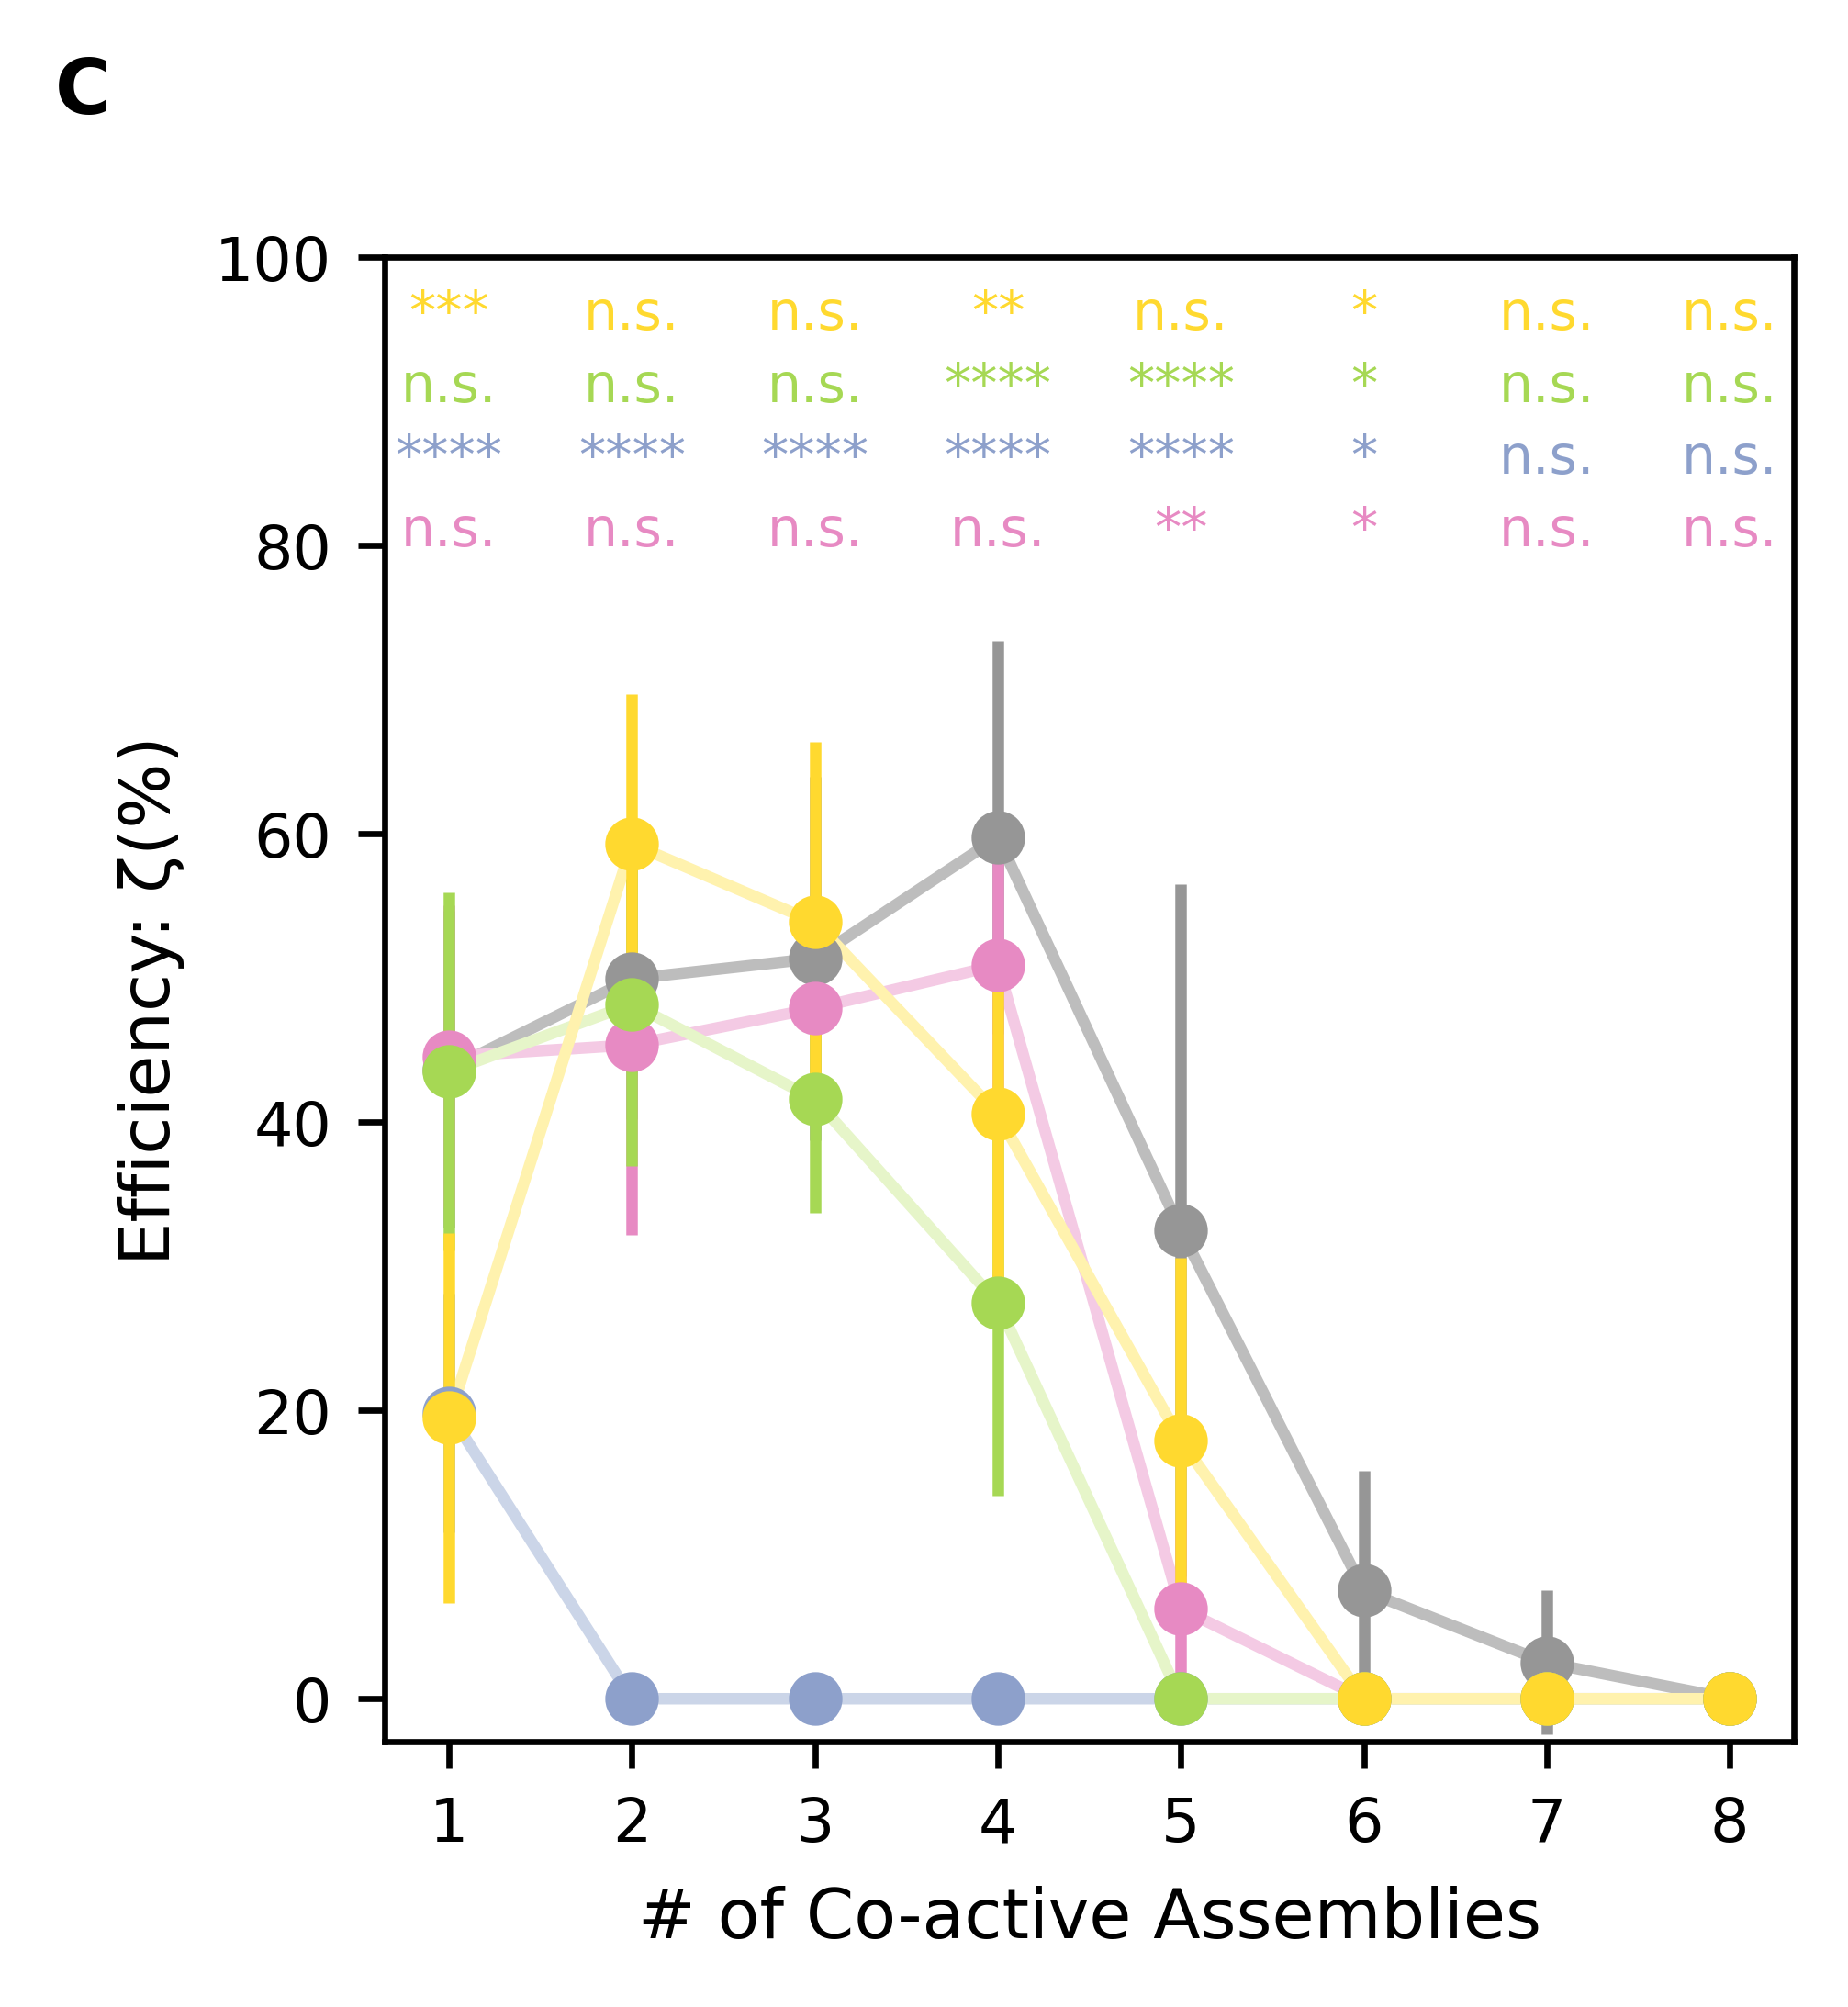

In [157]:
coactive = np.arange(1,9)


fig, ax = plt.subplots(figsize=(3.3, 3.5), dpi=600)
ax.set_ylim(-3,100)


ax.plot(coactive,EXP4_eff_gid,color=dCaAP_color2,label="dCaAP")
ax.errorbar(coactive, EXP4_eff_gid, yerr=EXP4_eff_gid_err, fmt="o", color=dCaAP_error_color2)


ax.plot(coactive,grade_EXP4_eff_gid,color=grade_color,label="not graded")
ax.errorbar(coactive, grade_EXP4_eff_gid, yerr=grade_EXP4_eff_gid_err, fmt="o", color=grade_error_color)
# p_values
for n_coactive in coactive:
    ax.text(n_coactive, 80, p_value_reporting(coactive_grade_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = grade_error_color )
######

ax.plot(coactive,thr_EXP4_eff_gid,color=thr_color,label="threshold")
ax.errorbar(coactive, thr_EXP4_eff_gid, yerr=thr_EXP4_eff_gid_err, fmt="o", color=thr_error_color)
# p_values
for n_coactive in coactive:
    ax.text(n_coactive, 85, p_value_reporting(coactive_thr_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = thr_error_color )
######

ax.plot(coactive,ref_EXP4_eff_gid,color=ref_color,label="refractory")
ax.errorbar(coactive, ref_EXP4_eff_gid, yerr=ref_EXP4_eff_gid_err, fmt="o", color=ref_error_color)
# p_values
for n_coactive in coactive:
    ax.text(n_coactive, 90, p_value_reporting(coactive_ref_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = ref_error_color )
######


ax.plot(coactive,amp_EXP4_eff_gid,color=amp_color,label="amplitude")
ax.errorbar(coactive, amp_EXP4_eff_gid, yerr=amp_EXP4_eff_gid_err, fmt="o", color=amp_error_color)
# p_values
for n_coactive in coactive:
    ax.text(n_coactive, 95, p_value_reporting(coactive_amp_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = amp_error_color )
######


ax.set_ylabel("Efficiency: \u03B6(%)")

ax.set_xlabel("# of Co-active Assemblies")
plt.xticks(range(1,9))
plt.yticks()
ax.text(-1, 110, "C", ha='center', fontsize = 10 , fontweight = "bold" )


# ax.legend(handles=[dCaAP_legend2,grade_legend,thr_legend,ref_legend,amp_legend],loc='lower center',bbox_to_anchor = (0.5,0.8), ncol = 2)

## Results for the coactive inputs model without structural plasctisity

In [159]:
str_EXP4_dend_limb =[str_EXP2_dend[0]]
str_EXP4_dend_limb_err=[str_EXP2_dend_err[0]]
str_EXP4_assemb_limb = [str_EXP2_assemb[0]]
str_EXP4_assemb_limb_err=[str_EXP2_assemb_err[0]]
str_EXP4_eff_limb =[str_EXP2_eff[0]]
str_EXP4_eff_limb_err=[str_EXP2_eff_err[0]]

str_coactive_limb_dend_list = [random_str_dend_list[0]]
str_coactive_limb_assembly_list = [random_str_assembly_list[0]]
str_coactive_limb_eff_list = [random_str_eff_list[0]]
#####################
str_EXP4_dend_gid =[str_EXP2_dend[1]]
str_EXP4_dend_gid_err=[str_EXP2_assemb[1]]
str_EXP4_assemb_gid = [str_EXP2_assemb[1]]
str_EXP4_assemb_gid_err=[str_EXP2_assemb_err[1]]
str_EXP4_eff_gid =[str_EXP2_eff[1]]
str_EXP4_eff_gid_err=[str_EXP2_eff_err[1]]

str_coactive_gidon_dend_list = [random_str_dend_list[1]]
str_coactive_gidon_assembly_list = [random_str_assembly_list[1]]
str_coactive_gidon_eff_list = [random_str_eff_list[1]]


#################################################
exp_name = "rewiring_ex4"
exp_result_name_folder_list = ['coactive2_no_str','coactive3_no_str','coactive4_no_str','coactive5_no_str',
                               'coactive6_no_str','coactive7_no_str','coactive8_no_str']

for model_name in ['Limbacher','Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Limbacher":

            str_coactive_limb_dend_list.append(sep_dend)
            str_coactive_limb_assembly_list.append(sep_ass)
            str_coactive_limb_eff_list.append(eff)
            
            str_EXP4_dend_limb.append(np.mean(sep_dend))
            str_EXP4_dend_limb_err.append(np.std(sep_dend))
            str_EXP4_assemb_limb.append(np.mean(sep_ass))
            str_EXP4_assemb_limb_err.append(np.std(sep_ass))
            str_EXP4_eff_limb.append(np.mean(eff))
            str_EXP4_eff_limb_err.append(np.std(eff))
        elif model_name == "Gidon_dend":

            str_coactive_gidon_dend_list.append(sep_dend)
            str_coactive_gidon_assembly_list.append(sep_ass)
            str_coactive_gidon_eff_list.append(eff)

        
            str_EXP4_dend_gid.append(np.mean(sep_dend))
            str_EXP4_dend_gid_err.append(np.std(sep_dend))
            str_EXP4_assemb_gid.append(np.mean(sep_ass))
            str_EXP4_assemb_gid_err.append(np.std(sep_ass))
            str_EXP4_eff_gid.append(np.mean(eff))
            str_EXP4_eff_gid_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/2672183177.py:61: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [161]:
coactive_str_gid_eff_p = [permutation_test(str_coactive_gidon_eff_list[i], coactive_gidon_eff_list[i]) for i in range(8) ]
coactive_str_limb_eff_p = [permutation_test(str_coactive_limb_eff_list[i], coactive_limb_eff_list[i]) for i in range(8) ]


coactive_str_gid_eff_p

[0.675, 0.9292, 0.1719, 0.2346, 0.2818, 1.0, 1.0, 1.0]

## Results for the coactive inputs model without functional plasctisity

In [164]:
func_EXP4_dend_limb =[func_EXP2_dend[0]]
func_EXP4_dend_limb_err=[func_EXP2_dend_err[0]]
func_EXP4_assemb_limb = [func_EXP2_assemb[0]]
func_EXP4_assemb_limb_err=[func_EXP2_assemb_err[0]]
func_EXP4_eff_limb =[func_EXP2_eff[0]]
func_EXP4_eff_limb_err=[func_EXP2_eff_err[0]]

func_coactive_limb_dend_list = [random_func_dend_list[0]]
func_coactive_limb_assembly_list = [random_func_assembly_list[0]]
func_coactive_limb_eff_list = [random_func_eff_list[0]]
#####################
func_EXP4_dend_gid =[func_EXP2_dend[1]]
func_EXP4_dend_gid_err=[func_EXP2_assemb[1]]
func_EXP4_assemb_gid = [func_EXP2_assemb[1]]
func_EXP4_assemb_gid_err=[func_EXP2_assemb_err[1]]
func_EXP4_eff_gid =[func_EXP2_eff[1]]
func_EXP4_eff_gid_err=[func_EXP2_eff_err[1]]

func_coactive_gidon_dend_list = [random_func_dend_list[1]]
func_coactive_gidon_assembly_list = [random_func_assembly_list[1]]
func_coactive_gidon_eff_list = [random_func_eff_list[1]]


#################################################
exp_name = "rewiring_ex4"
exp_result_name_folder_list = ['coactive2_no_func','coactive3_no_func','coactive4_no_func','coactive5_no_func',
                               'coactive6_no_func','coactive7_no_func','coactive8_no_func']

for model_name in ['Limbacher','Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Limbacher":

            func_coactive_limb_dend_list.append(sep_dend)
            func_coactive_limb_assembly_list.append(sep_ass)
            func_coactive_limb_eff_list.append(eff)
            
            func_EXP4_dend_limb.append(np.mean(sep_dend))
            func_EXP4_dend_limb_err.append(np.std(sep_dend))
            func_EXP4_assemb_limb.append(np.mean(sep_ass))
            func_EXP4_assemb_limb_err.append(np.std(sep_ass))
            func_EXP4_eff_limb.append(np.mean(eff))
            func_EXP4_eff_limb_err.append(np.std(eff))
        elif model_name == "Gidon_dend":

            func_coactive_gidon_dend_list.append(sep_dend)
            func_coactive_gidon_assembly_list.append(sep_ass)
            func_coactive_gidon_eff_list.append(eff)

        
            func_EXP4_dend_gid.append(np.mean(sep_dend))
            func_EXP4_dend_gid_err.append(np.std(sep_dend))
            func_EXP4_assemb_gid.append(np.mean(sep_ass))
            func_EXP4_assemb_gid_err.append(np.std(sep_ass))
            func_EXP4_eff_gid.append(np.mean(eff))
            func_EXP4_eff_gid_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/3456829148.py:61: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [166]:
coactive_func_gid_eff_p = [permutation_test(func_coactive_gidon_eff_list[i], coactive_gidon_eff_list[i]) for i in range(8) ]
coactive_func_limb_eff_p = [permutation_test(func_coactive_limb_eff_list[i], coactive_limb_eff_list[i]) for i in range(8) ]


coactive_func_gid_eff_p

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0341, 0.4769, 1.0]

## Results for the coactive inputs model without STDP plactisity

In [169]:
stdp_EXP4_dend_limb =[stdp_EXP2_dend[0]]
stdp_EXP4_dend_limb_err=[stdp_EXP2_dend_err[0]]
stdp_EXP4_assemb_limb = [stdp_EXP2_assemb[0]]
stdp_EXP4_assemb_limb_err=[stdp_EXP2_assemb_err[0]]
stdp_EXP4_eff_limb =[stdp_EXP2_eff[0]]
stdp_EXP4_eff_limb_err=[stdp_EXP2_eff_err[0]]

stdp_coactive_limb_dend_list = [random_stdp_dend_list[0]]
stdp_coactive_limb_assembly_list = [random_stdp_assembly_list[0]]
stdp_coactive_limb_eff_list = [random_stdp_eff_list[0]]
#####################
stdp_EXP4_dend_gid =[stdp_EXP2_dend[1]]
stdp_EXP4_dend_gid_err=[stdp_EXP2_assemb[1]]
stdp_EXP4_assemb_gid = [stdp_EXP2_assemb[1]]
stdp_EXP4_assemb_gid_err=[stdp_EXP2_assemb_err[1]]
stdp_EXP4_eff_gid =[stdp_EXP2_eff[1]]
stdp_EXP4_eff_gid_err=[stdp_EXP2_eff_err[1]]

stdp_coactive_gidon_dend_list = [random_stdp_dend_list[1]]
stdp_coactive_gidon_assembly_list = [random_stdp_assembly_list[1]]
stdp_coactive_gidon_eff_list = [random_stdp_eff_list[1]]


#################################################
exp_name = "rewiring_ex4"
exp_result_name_folder_list = ['coactive2_no_stdp','coactive3_no_stdp','coactive4_no_stdp','coactive5_no_stdp',
                               'coactive6_no_stdp','coactive7_no_stdp','coactive8_no_stdp']

for model_name in ['Limbacher','Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Limbacher":

            stdp_coactive_limb_dend_list.append(sep_dend)
            stdp_coactive_limb_assembly_list.append(sep_ass)
            stdp_coactive_limb_eff_list.append(eff)
            
            stdp_EXP4_dend_limb.append(np.mean(sep_dend))
            stdp_EXP4_dend_limb_err.append(np.std(sep_dend))
            stdp_EXP4_assemb_limb.append(np.mean(sep_ass))
            stdp_EXP4_assemb_limb_err.append(np.std(sep_ass))
            stdp_EXP4_eff_limb.append(np.mean(eff))
            stdp_EXP4_eff_limb_err.append(np.std(eff))
        elif model_name == "Gidon_dend":

            stdp_coactive_gidon_dend_list.append(sep_dend)
            stdp_coactive_gidon_assembly_list.append(sep_ass)
            stdp_coactive_gidon_eff_list.append(eff)

        
            stdp_EXP4_dend_gid.append(np.mean(sep_dend))
            stdp_EXP4_dend_gid_err.append(np.std(sep_dend))
            stdp_EXP4_assemb_gid.append(np.mean(sep_ass))
            stdp_EXP4_assemb_gid_err.append(np.std(sep_ass))
            stdp_EXP4_eff_gid.append(np.mean(eff))
            stdp_EXP4_eff_gid_err.append(np.std(eff))

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/2314308061.py:61: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [171]:
coactive_stdp_gid_eff_p = [permutation_test(stdp_coactive_gidon_eff_list[i], coactive_gidon_eff_list[i]) for i in range(8) ]
coactive_stdp_limb_eff_p = [permutation_test(stdp_coactive_limb_eff_list[i], coactive_limb_eff_list[i]) for i in range(8) ]


coactive_stdp_gid_eff_p
coactive_stdp_limb_eff_p

[0.7301, 0.0884, 0.3441, 1.0, 1.0, 1.0, 1.0, 1.0]

# Overlapping Assemblies

## Basic

In [175]:
EXP5_dend_limb =[EXP2_dend[0]]
EXP5_dend_limb_err=[EXP2_dend_err[0]]
EXP5_assemb_limb = [EXP2_assemb[0]]
EXP5_assemb_limb_err=[EXP2_assemb_err[0]]
EXP5_eff_limb =[EXP2_eff[0]]
EXP5_eff_limb_err=[EXP2_eff_err[0]]

overlap_limb_dend_list = [basic_random_limb_dend]
overlap_limb_assembly_list = [basic_random_limb_assemb]
overlap_limb_eff_list = [basic_random_limb_eff]
#####################
EXP5_dend_gid =[EXP2_dend[1]]
EXP5_dend_gid_err=[EXP2_dend_err[1]]
EXP5_assemb_gid = [EXP2_assemb[1]]
EXP5_assemb_gid_err=[EXP2_assemb_err[1]]
EXP5_eff_gid =[EXP2_eff[1]]
EXP5_eff_gid_err=[EXP2_eff_err[1]]

overlap_gidon_dend_list = [basic_random_gidon_dend]
overlap_gidon_assembly_list = [basic_random_gidon_assemb]
overlap_gidon_eff_list = [basic_random_gidon_eff]

#################################################
exp_name = "rewiring_ex5"
exp_result_name_folder_list = ['overlap25','overlap50','overlap75']

for model_name in ['Limbacher','Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 38:
                        line_as_list = ast.literal_eval(line[29:])
#                         print(line_as_list)
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Limbacher":

            overlap_limb_dend_list.append(sep_dend)
            overlap_limb_assembly_list.append(sep_ass)
            overlap_limb_eff_list.append(eff)
            
            EXP5_dend_limb.append(np.mean(sep_dend))
            EXP5_dend_limb_err.append(np.std(sep_dend))
            EXP5_assemb_limb.append(np.mean(sep_ass))
            EXP5_assemb_limb_err.append(np.std(sep_ass))
            EXP5_eff_limb.append(np.mean(eff))
            EXP5_eff_limb_err.append(np.std(eff))
        elif model_name == "Gidon_dend":

            overlap_gidon_dend_list.append(sep_dend)
            overlap_gidon_assembly_list.append(sep_ass)
            overlap_gidon_eff_list.append(eff)

        
            EXP5_dend_gid.append(np.mean(sep_dend))
            EXP5_dend_gid_err.append(np.std(sep_dend))
            EXP5_assemb_gid.append(np.mean(sep_ass))
            EXP5_assemb_gid_err.append(np.std(sep_ass))
            EXP5_eff_gid.append(np.mean(eff))
            EXP5_eff_gid_err.append(np.std(eff))
            
            

## Number of Detected Assemblies

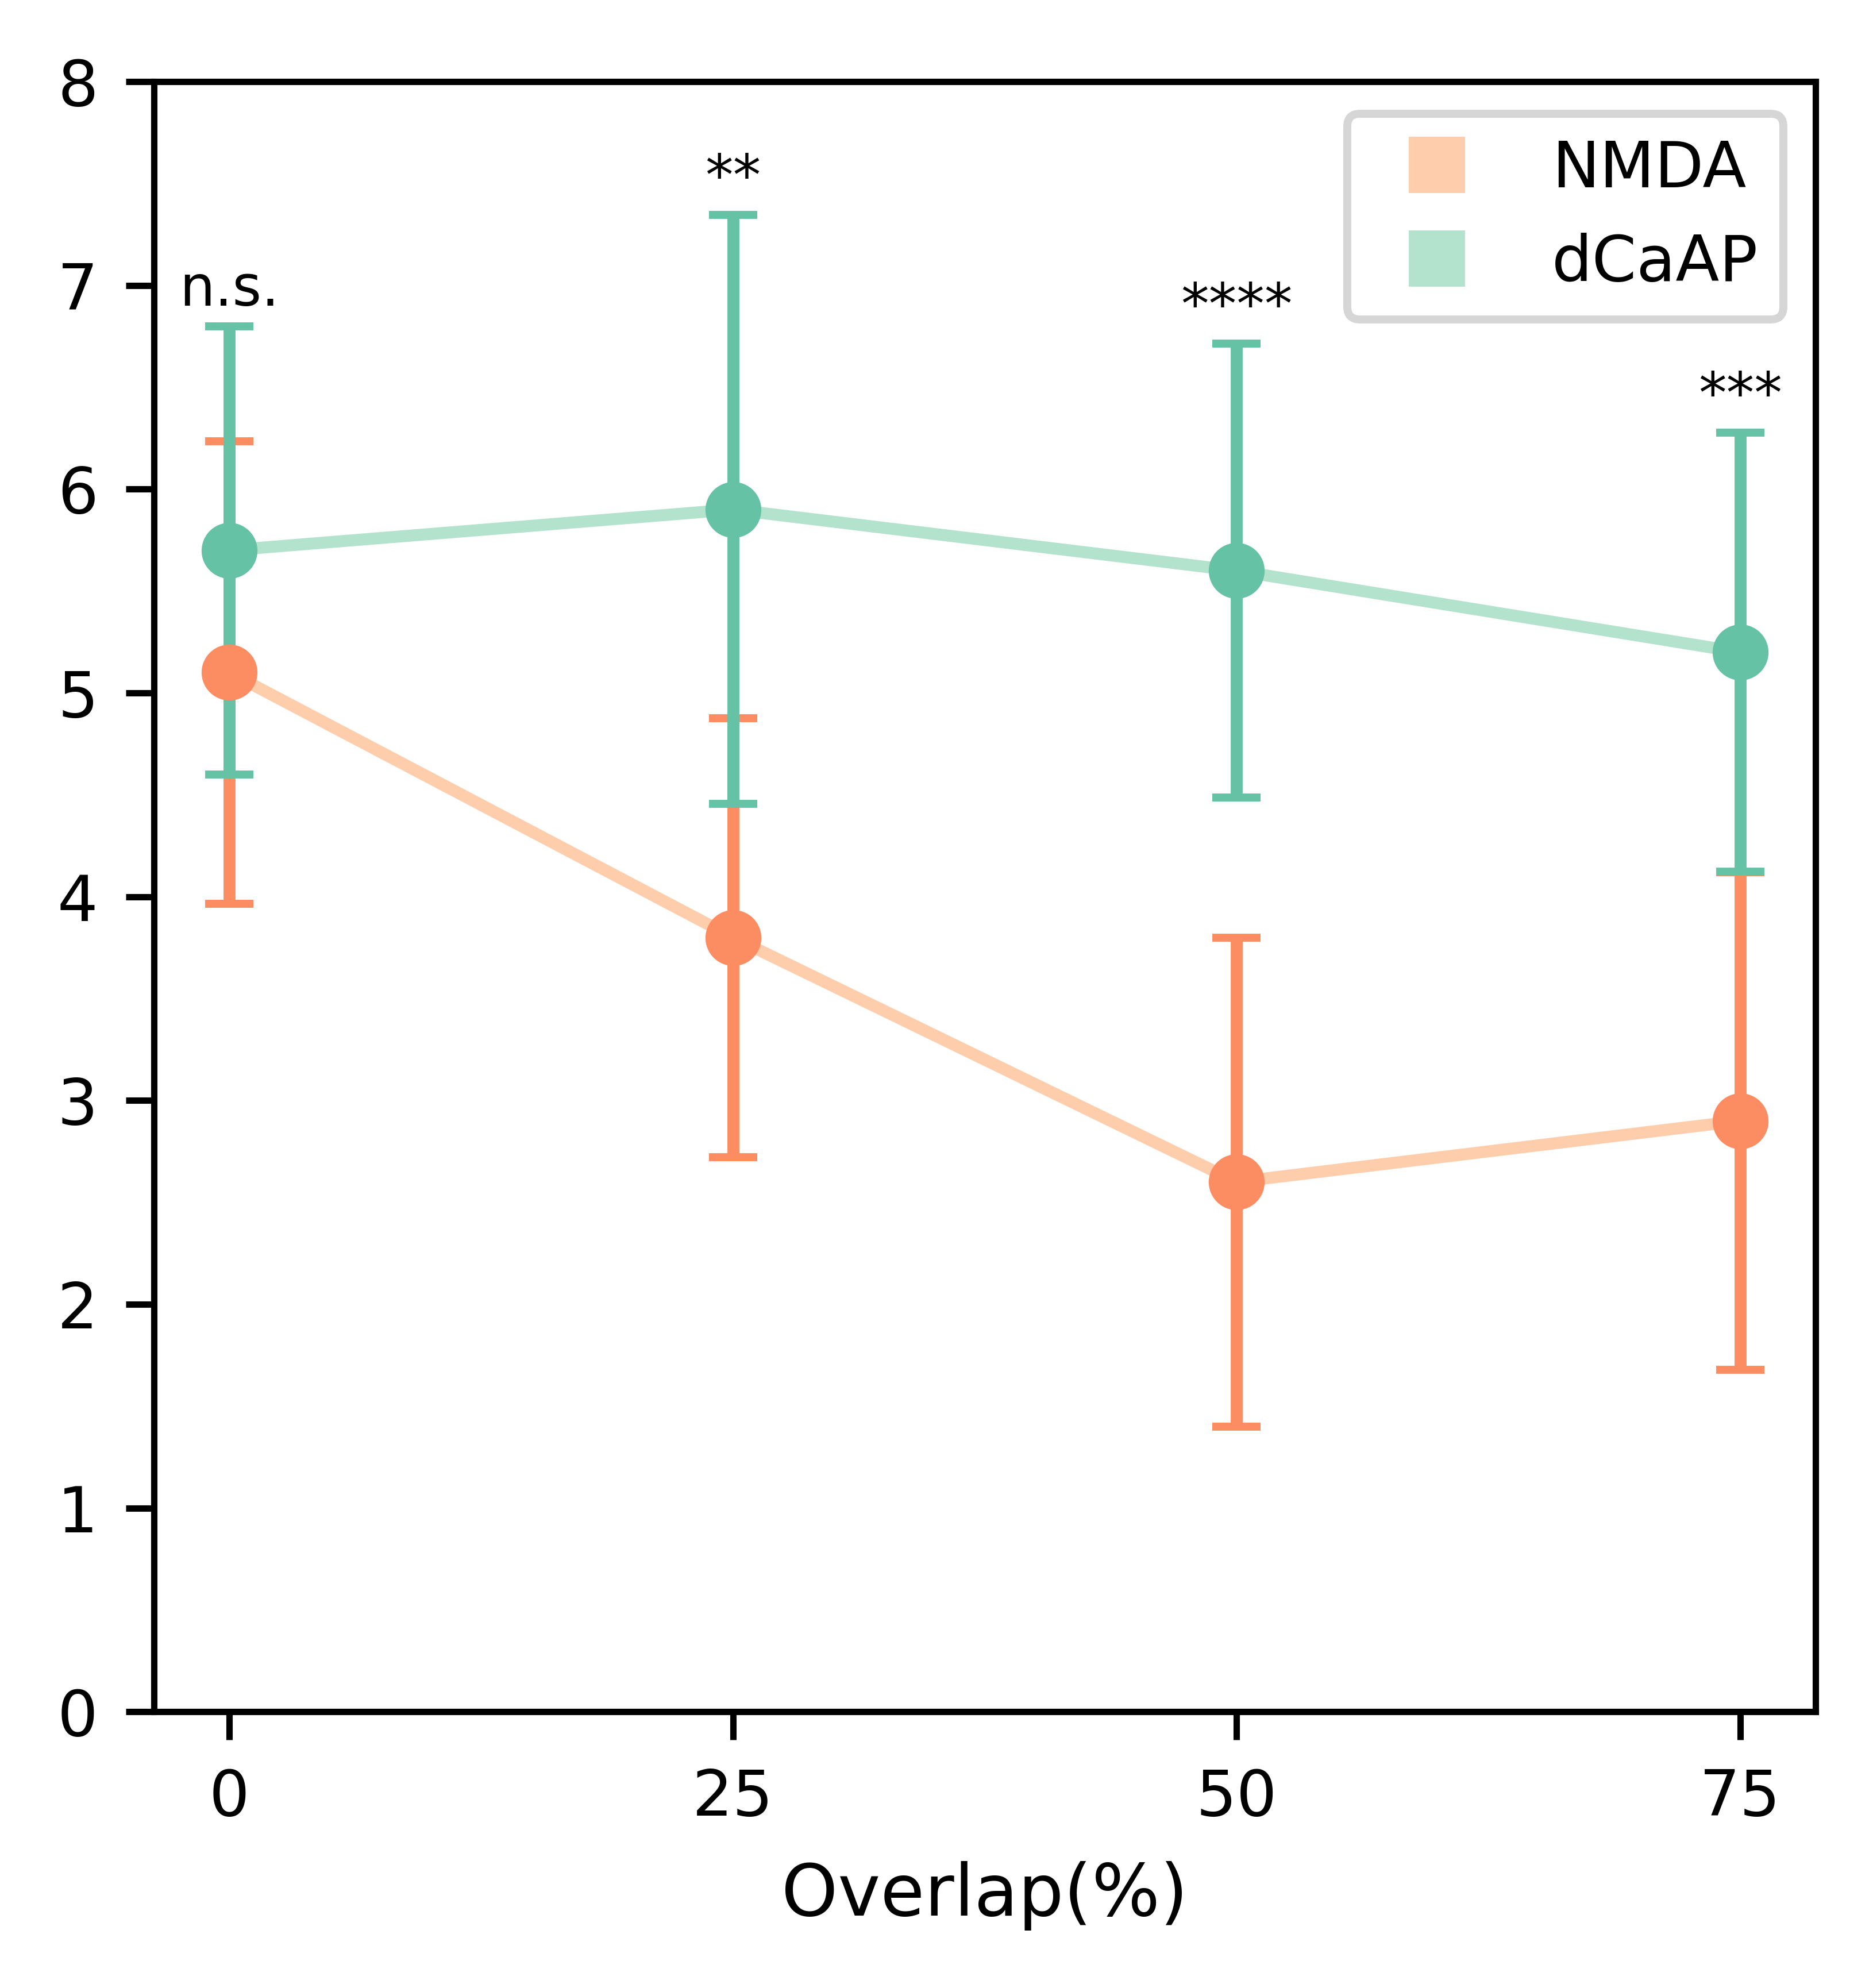

In [178]:
overlap_percentage = np.array([0,25,50,75])

fig, ax = plt.subplots(figsize=(3.3, 3.5), dpi=1000)
ax.set_ylim(0,101)


ax.plot(overlap_percentage,EXP5_assemb_limb,color=NMDA_color)
ax.errorbar(overlap_percentage, EXP5_assemb_limb, yerr=EXP5_assemb_limb_err, fmt="o", color=NMDA_error_color, capsize = 3)

ax.plot(overlap_percentage,EXP5_assemb_gid,color=dCaAP_color)
ax.errorbar(overlap_percentage, EXP5_assemb_gid, yerr=EXP5_assemb_gid_err, fmt="o", color=dCaAP_error_color , capsize = 3)

# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax.text(p_overlap, max(EXP5_assemb_limb_err[i]+EXP5_assemb_limb[i], EXP5_assemb_gid[i]+EXP5_assemb_gid_err[i],0.2) +.1, p_value_reporting(permutation_test(overlap_limb_assembly_list[i], overlap_gidon_assembly_list[i])), ha='center', fontsize = 7)
######


ax.set_xlabel("Overlap(%)")
plt.xticks(overlap_percentage)
plt.yticks()
plt.ylim(0,8)


ax.legend(handles=[NMDA_legend,dCaAP_legend],loc='upper right')

plt.tight_layout()

fig.savefig("Figures/pdf/overlapping_detected_assemblies.pdf", format='pdf',bbox_inches='tight')
fig.savefig("Figures/svg/overlapping_detected_assemblies.svg", format='svg',bbox_inches='tight')

## Efficiency

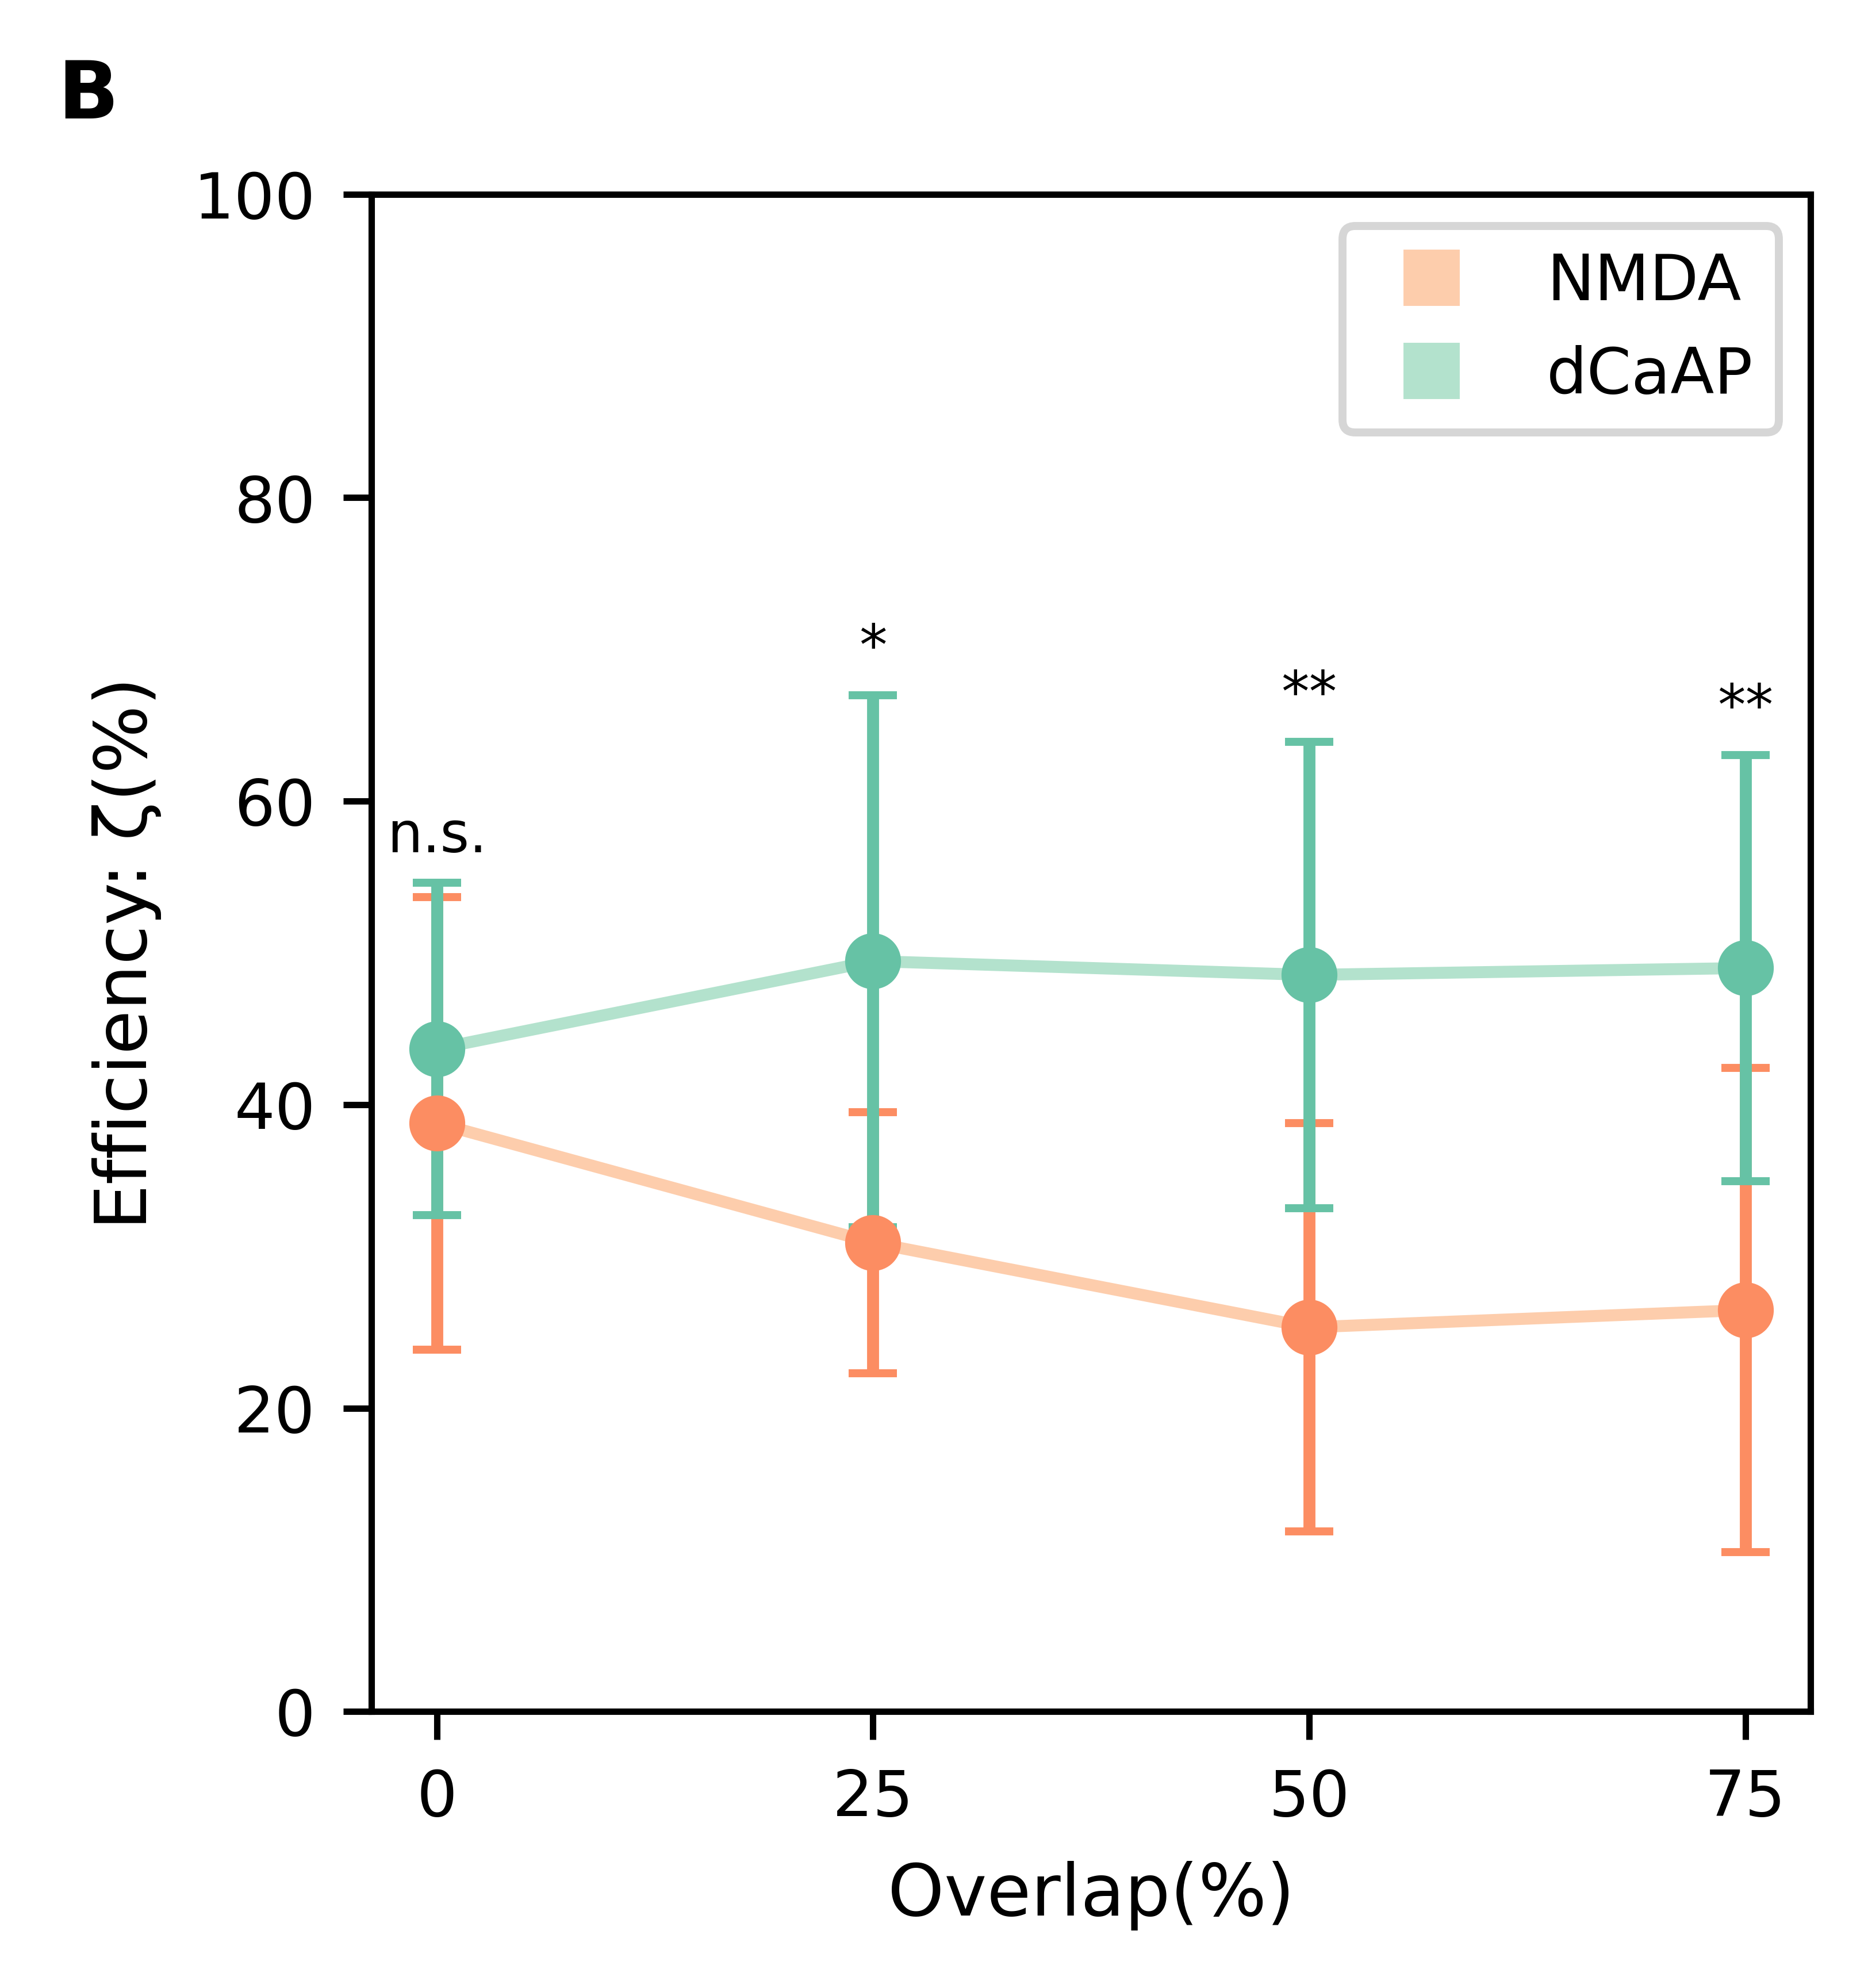

In [181]:
overlap_percentage = np.array([0,25,50,75])


fig, ax = plt.subplots(figsize=(3.3, 3.5), dpi=1000)
ax.set_ylim(0,100)


ax.plot(overlap_percentage,EXP5_eff_limb,color=NMDA_color,label="NMDA")
ax.errorbar(overlap_percentage, EXP5_eff_limb, yerr=EXP5_eff_limb_err, fmt="o", color=NMDA_error_color , capsize = 3)

ax.plot(overlap_percentage[:len(EXP5_eff_gid)],EXP5_eff_gid,color=dCaAP_color,label="dCaAP")
ax.errorbar(overlap_percentage[:len(EXP5_eff_gid)], EXP5_eff_gid, yerr=EXP5_eff_gid_err, fmt="o", color=dCaAP_error_color, capsize = 3)

# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax.text(p_overlap, max(EXP5_eff_limb_err[i]+EXP5_eff_limb[i], EXP5_eff_gid[i]+EXP5_eff_gid_err[i],0.2) +2, p_value_reporting(permutation_test(overlap_limb_eff_list[i], overlap_gidon_eff_list[i])), ha='center', fontsize = 7)
######

ax.set_ylabel("Efficiency: \u03B6(%)")
ax.set_xlabel("Overlap(%)")
plt.xticks(overlap_percentage)
plt.yticks()
ax.text(-20, 105, "B", ha='center', fontsize = 10,fontweight='bold')


ax.legend(handles=[NMDA_legend,dCaAP_legend],loc='upper right')

plt.tight_layout()
fig.savefig("Figures/pdf/overlapping_efficiencies.pdf", format='pdf',bbox_inches='tight')
fig.savefig("Figures/svg/overlapping_efficiencies.svg", format='svg',bbox_inches='tight')

## Results of the dCaAP model with constant dendritic spike amplitude (not graded)

In [184]:
grade_EXP5_dend_gid =[grade_EXP2_dend[0]]
grade_EXP5_dend_gid_err=[grade_EXP2_dend_err[0]]
grade_EXP5_assemb_gid = [grade_EXP2_assemb[0]]
grade_EXP5_assemb_gid_err=[grade_EXP2_assemb_err[0]]
grade_EXP5_eff_gid =[grade_EXP2_eff[0]]
grade_EXP5_eff_gid_err=[grade_EXP2_eff_err[0]]

exp5_grade_dend_list = []
exp5_grade_assembly_list = []
exp5_grade_eff_list = []

#################################################
exp_name = "rewiring_ex5"
exp_result_name_folder_list = ['not_graded_overlap25','not_graded_overlap50','not_graded_overlap75']

for model_name in ['Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 38:
                        line_as_list = ast.literal_eval(line[29:])
#                         print(line_as_list)
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Gidon_dend":

            exp5_grade_dend_list.append(sep_dend)
            exp5_grade_assembly_list.append(sep_ass)
            exp5_grade_eff_list.append(eff)
        
            grade_EXP5_dend_gid.append(np.mean(sep_dend))
            grade_EXP5_dend_gid_err.append(np.std(sep_dend))
            grade_EXP5_assemb_gid.append(np.mean(sep_ass))
            grade_EXP5_assemb_gid_err.append(np.std(sep_ass))
            grade_EXP5_eff_gid.append(np.mean(eff))
            grade_EXP5_eff_gid_err.append(np.std(eff))
            
            

In [186]:
overlap_grade_eff_p = [permutation_test(exp5_grade_eff_list[i], overlap_gidon_eff_list[i+1]) for i in range(3) ]
overlap_grade_dend_p = [permutation_test(exp5_grade_dend_list[i], overlap_gidon_dend_list[i+1])  for i in range(3) ]
overlap_grade_assemb_p = [permutation_test(exp5_grade_assembly_list[i], overlap_gidon_assembly_list[i+1])  for i in range(3) ]

overlap_grade_eff_p.insert(0,random_grade_eff_p)
overlap_grade_dend_p.insert(0,random_grade_dend_p)
overlap_grade_assemb_p.insert(0,random_grade_assemb_p)

overlap_grade_eff_p

[0.861, 0.6632, 0.7426, 0.7399]

## Results of the dCaAP model with lower Dendritic Threshold V_thr = -36 --> -55 mv

In [189]:
thr_EXP5_dend_gid =[thr_EXP2_dend[0]]
thr_EXP5_dend_gid_err=[thr_EXP2_dend_err[0]]
thr_EXP5_assemb_gid = [thr_EXP2_assemb[0]]
thr_EXP5_assemb_gid_err=[thr_EXP2_assemb_err[0]]
thr_EXP5_eff_gid =[thr_EXP2_eff[0]]
thr_EXP5_eff_gid_err=[thr_EXP2_eff_err[0]]

exp5_thr_dend_list = []
exp5_thr_assembly_list = []
exp5_thr_eff_list = []
#################################################
exp_name = "rewiring_ex5"
exp_result_name_folder_list = ['thr_overlap25','thr_overlap50','thr_overlap75']

for model_name in ['Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 38:
                        line_as_list = ast.literal_eval(line[29:])
#                         print(line_as_list)
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Gidon_dend":

            exp5_thr_dend_list.append(sep_dend)
            exp5_thr_assembly_list.append(sep_ass)
            exp5_thr_eff_list.append(eff)
        
            thr_EXP5_dend_gid.append(np.mean(sep_dend))
            thr_EXP5_dend_gid_err.append(np.std(sep_dend))
            thr_EXP5_assemb_gid.append(np.mean(sep_ass))
            thr_EXP5_assemb_gid_err.append(np.std(sep_ass))
            thr_EXP5_eff_gid.append(np.mean(eff))
            thr_EXP5_eff_gid_err.append(np.std(eff))
            
            

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/3844964487.py:48: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [191]:
overlap_thr_eff_p = [permutation_test(exp5_thr_eff_list[i], overlap_gidon_eff_list[i+1]) for i in range(3) ]
overlap_thr_dend_p = [permutation_test(exp5_thr_dend_list[i], overlap_gidon_dend_list[i+1])  for i in range(3) ]
overlap_thr_assemb_p = [permutation_test(exp5_thr_assembly_list[i], overlap_gidon_assembly_list[i+1])  for i in range(3) ]

overlap_thr_eff_p.insert(0,random_thr_eff_p)
overlap_thr_dend_p.insert(0,random_thr_dend_p)
overlap_thr_assemb_p.insert(0,random_thr_assemb_p)

overlap_thr_eff_p

[0.0, 0.0002, 0.0003, 0.0024]

## Results of the dCaAP model with shorter Dendritic refractory t_ref = 200 --> 50 ms

In [194]:
ref_EXP5_dend_gid =[ref_EXP2_dend[0]]
ref_EXP5_dend_gid_err=[ref_EXP2_dend_err[0]]
ref_EXP5_assemb_gid = [ref_EXP2_assemb[0]]
ref_EXP5_assemb_gid_err=[ref_EXP2_assemb_err[0]]
ref_EXP5_eff_gid =[ref_EXP2_eff[0]]
ref_EXP5_eff_gid_err=[ref_EXP2_eff_err[0]]

exp5_ref_dend_list = []
exp5_ref_assembly_list = []
exp5_ref_eff_list = []

#################################################
exp_name = "rewiring_ex5"
exp_result_name_folder_list = ['ref_overlap25','ref_overlap50','ref_overlap75']

for model_name in ['Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 38:
                        line_as_list = ast.literal_eval(line[29:])
#                         print(line_as_list)
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Gidon_dend":

            exp5_ref_dend_list.append(sep_dend)
            exp5_ref_assembly_list.append(sep_ass)
            exp5_ref_eff_list.append(eff)
        
            ref_EXP5_dend_gid.append(np.mean(sep_dend))
            ref_EXP5_dend_gid_err.append(np.std(sep_dend))
            ref_EXP5_assemb_gid.append(np.mean(sep_ass))
            ref_EXP5_assemb_gid_err.append(np.std(sep_ass))
            ref_EXP5_eff_gid.append(np.mean(eff))
            ref_EXP5_eff_gid_err.append(np.std(eff))
            
            

In [196]:
overlap_ref_eff_p = [permutation_test(exp5_ref_eff_list[i], overlap_gidon_eff_list[i+1]) for i in range(3) ]
overlap_ref_dend_p = [permutation_test(exp5_ref_dend_list[i], overlap_gidon_dend_list[i+1])  for i in range(3) ]
overlap_ref_assemb_p = [permutation_test(exp5_ref_assembly_list[i], overlap_gidon_assembly_list[i+1])  for i in range(3) ]

overlap_ref_eff_p.insert(0,random_ref_eff_p)
overlap_ref_dend_p.insert(0,random_ref_dend_p)
overlap_ref_assemb_p.insert(0,random_ref_assemb_p)

overlap_ref_eff_p

[0.9712, 0.5842, 0.3215, 0.5233]

## Results of the dCaAP model with lower Dendritic spike amplitude

In [199]:
amp_EXP5_dend_gid =[amp_EXP2_dend[0]]
amp_EXP5_dend_gid_err=[amp_EXP2_dend_err[0]]
amp_EXP5_assemb_gid = [amp_EXP2_assemb[0]]
amp_EXP5_assemb_gid_err=[amp_EXP2_assemb_err[0]]
amp_EXP5_eff_gid =[amp_EXP2_eff[0]]
amp_EXP5_eff_gid_err=[amp_EXP2_eff_err[0]]

exp5_amp_dend_list = []
exp5_amp_assembly_list = []
exp5_amp_eff_list = []

#################################################
exp_name = "rewiring_ex5"
exp_result_name_folder_list = ['amp_overlap25','amp_overlap50','amp_overlap75']

for model_name in ['Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 38:
                        line_as_list = ast.literal_eval(line[29:])
#                         print(line_as_list)
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Gidon_dend":

            exp5_amp_dend_list.append(sep_dend)
            exp5_amp_assembly_list.append(sep_ass)
            exp5_amp_eff_list.append(eff)

        
            amp_EXP5_dend_gid.append(np.mean(sep_dend))
            amp_EXP5_dend_gid_err.append(np.std(sep_dend))
            amp_EXP5_assemb_gid.append(np.mean(sep_ass))
            amp_EXP5_assemb_gid_err.append(np.std(sep_ass))
            amp_EXP5_eff_gid.append(np.mean(eff))
            amp_EXP5_eff_gid_err.append(np.std(eff))
            
            

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/3247398864.py:49: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [201]:
overlap_amp_eff_p = [permutation_test(exp5_amp_eff_list[i], overlap_gidon_eff_list[i+1]) for i in range(3) ]
overlap_amp_dend_p = [permutation_test(exp5_amp_dend_list[i], overlap_gidon_dend_list[i+1])  for i in range(3) ]
overlap_amp_assemb_p = [permutation_test(exp5_amp_assembly_list[i], overlap_gidon_assembly_list[i+1])  for i in range(3) ]

overlap_amp_eff_p.insert(0,random_amp_eff_p)
overlap_amp_dend_p.insert(0,random_amp_dend_p)
overlap_amp_assemb_p.insert(0,random_amp_assemb_p)

overlap_amp_eff_p

[0.0004, 0.0062, 0.0001, 0.0013]

## Plotting the resutls of changed parameters

Text(-20, 110, 'B')

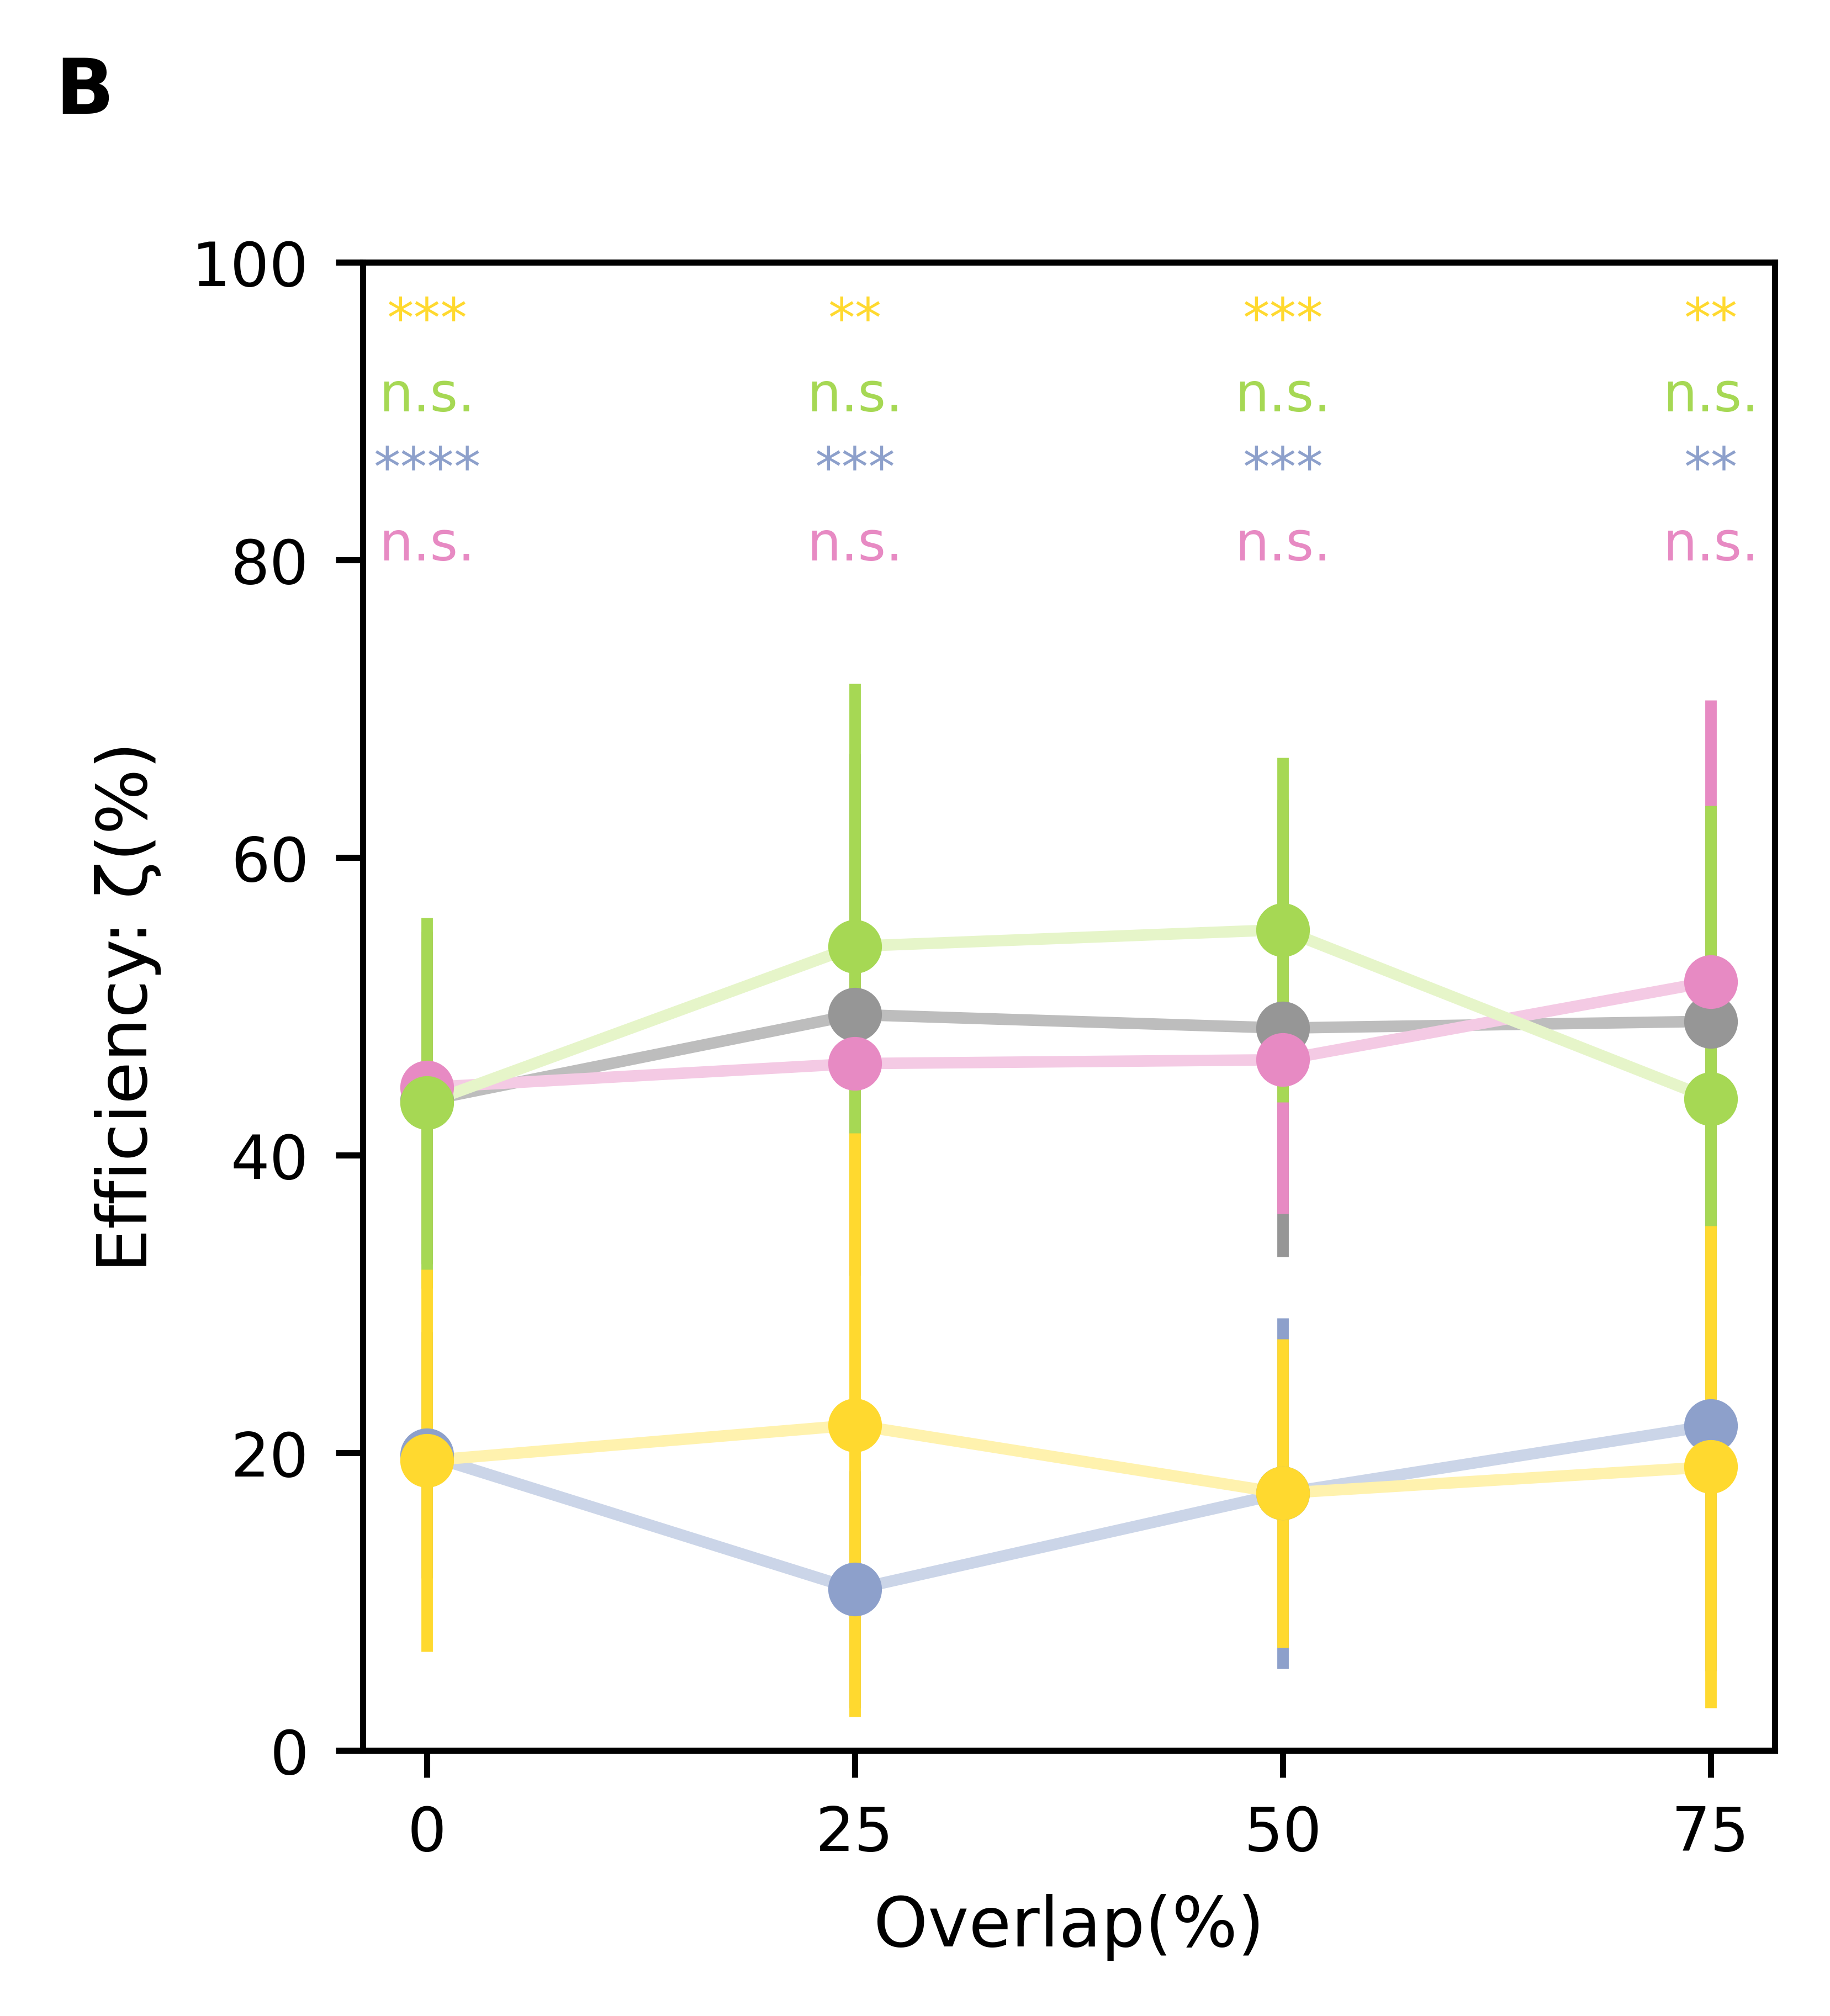

In [206]:
overlap_percentage = np.array([0,25,50,75])


fig, ax = plt.subplots(figsize=(3.3, 3.5), dpi=1000)
ax.set_ylim(0,100)


# ax.plot(overlap_percentage,EXP5_eff_limb,color=NMDA_color,label="NMDA")
# ax.errorbar(overlap_percentage, EXP5_eff_limb, yerr=EXP5_eff_limb_err, fmt="o", color=NMDA_error_color)

ax.plot(overlap_percentage,EXP5_eff_gid,color=dCaAP_color2,label="dCaAP")
ax.errorbar(overlap_percentage, EXP5_eff_gid, yerr=EXP5_eff_gid_err, fmt="o", color=dCaAP_error_color2)

ax.plot(overlap_percentage,grade_EXP5_eff_gid,color=grade_color,label="not graded")
ax.errorbar(overlap_percentage, grade_EXP5_eff_gid, yerr=grade_EXP5_eff_gid_err, fmt="o", color=grade_error_color)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax.text(p_overlap, 80, p_value_reporting(overlap_grade_eff_p[i]), ha='center', fontsize = 7 , color = grade_error_color )
######


ax.plot(overlap_percentage,thr_EXP5_eff_gid,color=thr_color,label="Threshold")
ax.errorbar(overlap_percentage, thr_EXP5_eff_gid, yerr=thr_EXP5_eff_gid_err, fmt="o", color=thr_error_color)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax.text(p_overlap, 85, p_value_reporting(overlap_thr_eff_p[i]), ha='center', fontsize = 7 , color = thr_error_color )
######


ax.plot(overlap_percentage,ref_EXP5_eff_gid,color=ref_color,label="refractory")
ax.errorbar(overlap_percentage, ref_EXP5_eff_gid, yerr=ref_EXP5_eff_gid_err, fmt="o", color=ref_error_color)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax.text(p_overlap, 90, p_value_reporting(overlap_ref_eff_p[i]), ha='center', fontsize = 7 , color = ref_error_color )
######


ax.plot(overlap_percentage,amp_EXP5_eff_gid,color=amp_color,label="amplitude")
ax.errorbar(overlap_percentage, amp_EXP5_eff_gid, yerr=amp_EXP5_eff_gid_err, fmt="o", color=amp_error_color)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax.text(p_overlap, 95, p_value_reporting(overlap_amp_eff_p[i]), ha='center', fontsize = 7 , color = amp_error_color )
######



ax.set_ylabel("Efficiency: \u03B6(%)")
ax.set_xlabel("Overlap(%)")
plt.xticks(overlap_percentage)
plt.yticks()
ax.text(-20, 110, "B", ha='center', fontsize = 10 , fontweight = "bold" )


# ax.legend(handles=[dCaAP_legend2,grade_legend,thr_legend,amp_legend],loc='lower center',bbox_to_anchor = (0.5,1.0), ncol = 2)

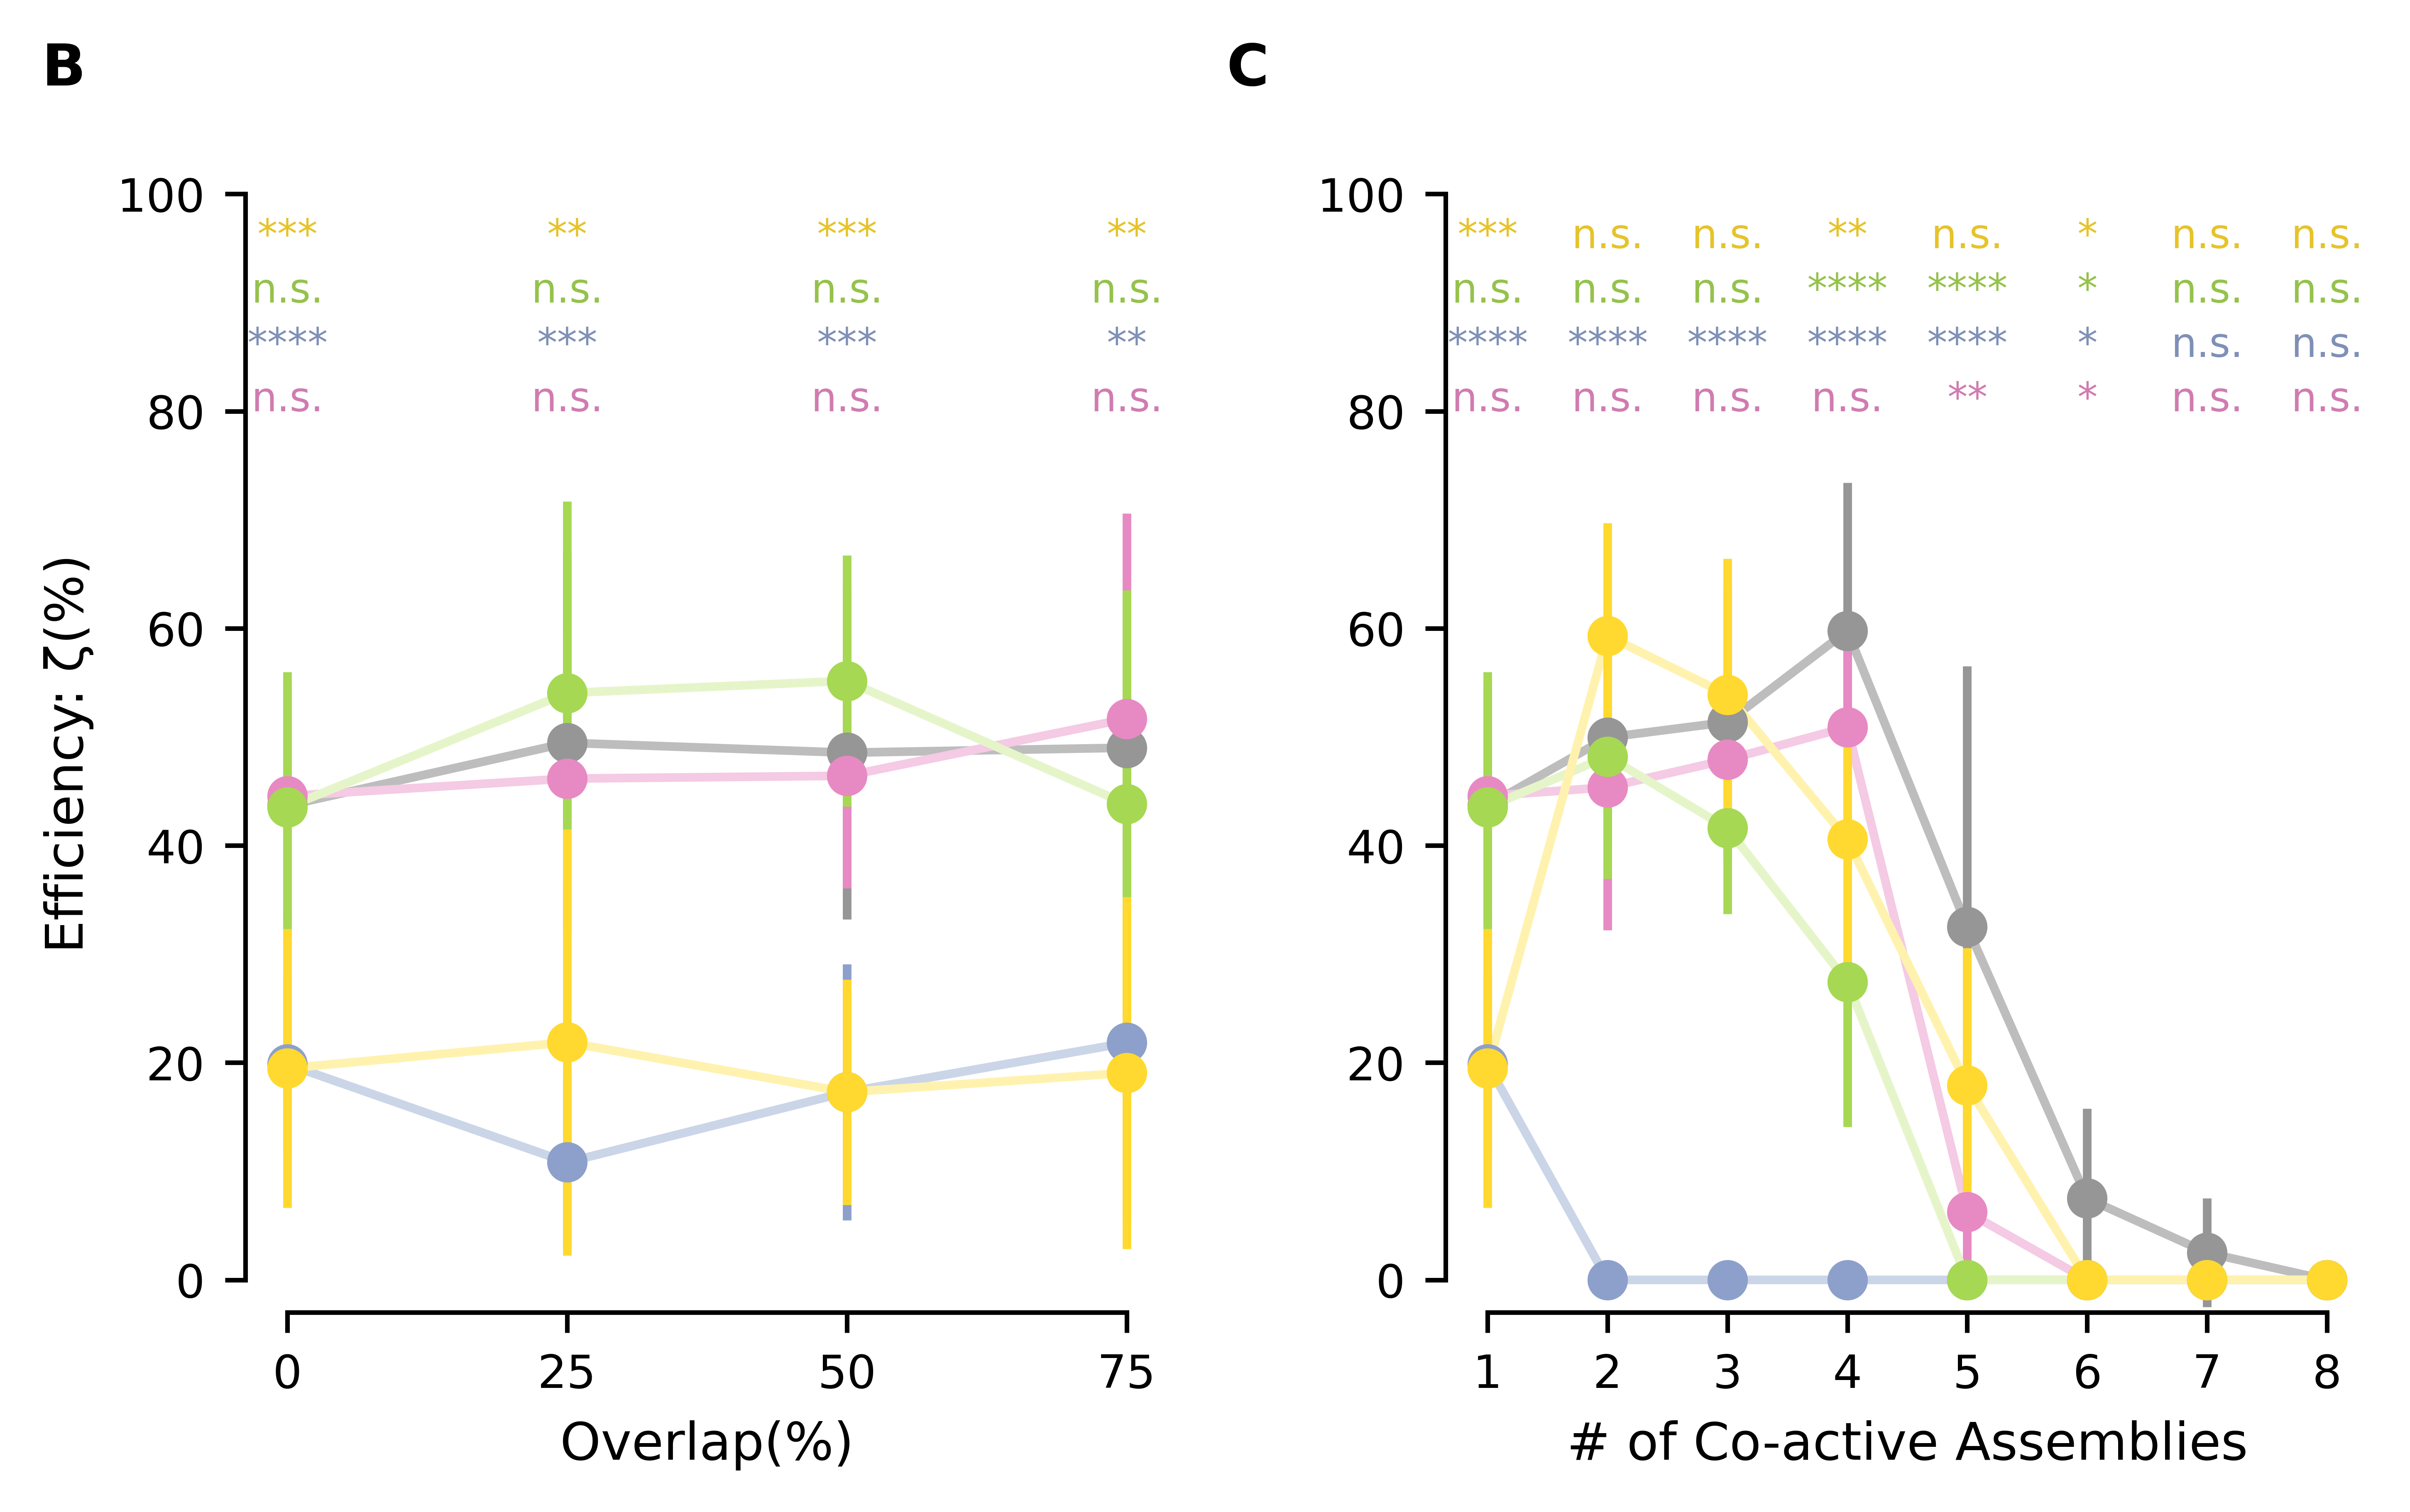

In [285]:
import matplotlib.colors as mcolors
def darken(color, factor=0.9):
    rgb = mcolors.to_rgb(color)
    dark_rgb = tuple(factor*x for x in rgb)
    return dark_rgb

grade_pval_color = darken(grade_error_color)
thr_pval_color   = darken(thr_error_color)
ref_pval_color   = darken(ref_error_color)
amp_pval_color   = darken(amp_error_color)

# grade_pval_color = mcolors.to_rgba(grade_error_color, alpha=1)  # darker
# thr_pval_color   = mcolors.to_rgba(thr_error_color, alpha=1)
# ref_pval_color   = mcolors.to_rgba(ref_error_color, alpha=1)
# amp_pval_color   = mcolors.to_rgba(amp_error_color, alpha=1)

fig, ax = plt.subplots(1,2,figsize=(6.6, 3.5), dpi=1000)

coactive = np.arange(1,9)

ax[1].set_ylim(-3,100)


ax[1].plot(coactive,EXP4_eff_gid,color=dCaAP_color2,label="dCaAP")
ax[1].errorbar(coactive, EXP4_eff_gid, yerr=EXP4_eff_gid_err, fmt="o", color=dCaAP_error_color2)


ax[1].plot(coactive,grade_EXP4_eff_gid,color=grade_color,label="not graded")
ax[1].errorbar(coactive, grade_EXP4_eff_gid, yerr=grade_EXP4_eff_gid_err, fmt="o", color=grade_error_color)
# p_values
for n_coactive in coactive:
    ax[1].text(n_coactive, 80, p_value_reporting(coactive_grade_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = grade_pval_color )
######

ax[1].plot(coactive,thr_EXP4_eff_gid,color=thr_color,label="threshold")
ax[1].errorbar(coactive, thr_EXP4_eff_gid, yerr=thr_EXP4_eff_gid_err, fmt="o", color=thr_error_color)
# p_values
for n_coactive in coactive:
    ax[1].text(n_coactive, 85, p_value_reporting(coactive_thr_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = thr_pval_color )
######

ax[1].plot(coactive,ref_EXP4_eff_gid,color=ref_color,label="refractory")
ax[1].errorbar(coactive, ref_EXP4_eff_gid, yerr=ref_EXP4_eff_gid_err, fmt="o", color=ref_error_color)
# p_values
for n_coactive in coactive:
    ax[1].text(n_coactive, 90, p_value_reporting(coactive_ref_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = ref_pval_color )
######


ax[1].plot(coactive,amp_EXP4_eff_gid,color=amp_color,label="amplitude")
ax[1].errorbar(coactive, amp_EXP4_eff_gid, yerr=amp_EXP4_eff_gid_err, fmt="o", color=amp_error_color)
# p_values
for n_coactive in coactive:
    ax[1].text(n_coactive, 95, p_value_reporting(coactive_amp_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = amp_pval_color )
######


# ax[1].set_ylabel("Efficiency: \u03B6(%)")

ax[1].set_xlabel("# of Co-active Assemblies")
ax[1].set_xticks(range(1,9))
# plt.yticks()
ax[1].text(-1, 110, "C", ha='center', fontsize = 10 , fontweight = "bold" )


overlap_percentage = np.array([0,25,50,75])


ax[0].set_ylim(-3,100)


# ax.plot(overlap_percentage,EXP5_eff_limb,color=NMDA_color,label="NMDA")
# ax.errorbar(overlap_percentage, EXP5_eff_limb, yerr=EXP5_eff_limb_err, fmt="o", color=NMDA_error_color)

ax[0].plot(overlap_percentage,EXP5_eff_gid,color=dCaAP_color2,label="dCaAP")
ax[0].errorbar(overlap_percentage, EXP5_eff_gid, yerr=EXP5_eff_gid_err, fmt="o", color=dCaAP_error_color2)

ax[0].plot(overlap_percentage,grade_EXP5_eff_gid,color=grade_color,label="not graded")
ax[0].errorbar(overlap_percentage, grade_EXP5_eff_gid, yerr=grade_EXP5_eff_gid_err, fmt="o", color=grade_error_color)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax[0].text(p_overlap, 80, p_value_reporting(overlap_grade_eff_p[i]), ha='center', fontsize = 7 , color = grade_pval_color )
######


ax[0].plot(overlap_percentage,thr_EXP5_eff_gid,color=thr_color,label="Threshold")
ax[0].errorbar(overlap_percentage, thr_EXP5_eff_gid, yerr=thr_EXP5_eff_gid_err, fmt="o", color=thr_error_color)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax[0].text(p_overlap, 85, p_value_reporting(overlap_thr_eff_p[i]), ha='center', fontsize = 7 , color = thr_pval_color  )
######


ax[0].plot(overlap_percentage,ref_EXP5_eff_gid,color=ref_color,label="refractory")
ax[0].errorbar(overlap_percentage, ref_EXP5_eff_gid, yerr=ref_EXP5_eff_gid_err, fmt="o", color=ref_error_color)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax[0].text(p_overlap, 90, p_value_reporting(overlap_ref_eff_p[i]), ha='center', fontsize = 7 , color = ref_pval_color )
######


ax[0].plot(overlap_percentage,amp_EXP5_eff_gid,color=amp_color,label="amplitude")
ax[0].errorbar(overlap_percentage, amp_EXP5_eff_gid, yerr=amp_EXP5_eff_gid_err, fmt="o", color=amp_error_color)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax[0].text(p_overlap, 95, p_value_reporting(overlap_amp_eff_p[i]), ha='center', fontsize = 7 , color = amp_pval_color )
######



ax[0].set_ylabel("Efficiency: \u03B6(%)")
ax[0].set_xlabel("Overlap(%)")
ax[0].set_xticks(overlap_percentage)
# plt.yticks()
ax[0].text(-20, 110, "B", ha='center', fontsize = 10 , fontweight = "bold" )

#########
for i,axes in enumerate(ax.flat):
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)
    axes.spines['left'].set_bounds(0, 100)
    if i == 0 :
        axes.spines['bottom'].set_bounds(0, 75)
    elif i == 1 :
        axes.spines['bottom'].set_bounds(1, 8)
        
        
#######



plt.subplots_adjust(wspace = 0.3)
# fig.legend(handles=[NMDA_legend,dCaAP_legend,grade_legend,thr_legend,amp_legend],loc='lower center',bbox_to_anchor = (0.5,0.8), ncol = 2)

fig.savefig("Figures/pdf/changed_overlapp_coactive.pdf", format='pdf',bbox_inches='tight')
fig.savefig("Figures/svg/changed_overlapp_coactive.svg", format='svg',bbox_inches='tight')

## Results for the overlapping inputs model without structural plasctisity

In [210]:
str_EXP5_dend_limb =[str_EXP2_dend[0]]
str_EXP5_dend_limb_err=[str_EXP2_dend_err[0]]
str_EXP5_assemb_limb = [str_EXP2_assemb[0]]
str_EXP5_assemb_limb_err=[str_EXP2_assemb_err[0]]
str_EXP5_eff_limb =[str_EXP2_eff[0]]
str_EXP5_eff_limb_err=[str_EXP2_eff_err[0]]

str_overlap_limb_dend_list = [random_str_dend_list[0]]
str_overlap_limb_assembly_list = [random_str_assembly_list[0]]
str_overlap_limb_eff_list = [random_str_eff_list[0]]
#####################
str_EXP5_dend_gid =[str_EXP2_dend[1]]
str_EXP5_dend_gid_err=[str_EXP2_assemb[1]]
str_EXP5_assemb_gid = [str_EXP2_assemb[1]]
str_EXP5_assemb_gid_err=[str_EXP2_assemb_err[1]]
str_EXP5_eff_gid =[str_EXP2_eff[1]]
str_EXP5_eff_gid_err=[str_EXP2_eff_err[1]]

str_overlap_gidon_dend_list = [random_str_dend_list[1]]
str_overlap_gidon_assembly_list = [random_str_assembly_list[1]]
str_overlap_gidon_eff_list = [random_str_eff_list[1]]

#################################################
exp_name = "rewiring_ex5"
exp_result_name_folder_list = ['overlap25_no_str','overlap50_no_str','overlap75_no_str']

for model_name in ['Limbacher','Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 38:
                        line_as_list = ast.literal_eval(line[29:])
#                         print(line_as_list)
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Limbacher":

            str_overlap_limb_dend_list.append(sep_dend)
            str_overlap_limb_assembly_list.append(sep_ass)
            str_overlap_limb_eff_list.append(eff)
            
            str_EXP5_dend_limb.append(np.mean(sep_dend))
            str_EXP5_dend_limb_err.append(np.std(sep_dend))
            str_EXP5_assemb_limb.append(np.mean(sep_ass))
            str_EXP5_assemb_limb_err.append(np.std(sep_ass))
            str_EXP5_eff_limb.append(np.mean(eff))
            str_EXP5_eff_limb_err.append(np.std(eff))
        elif model_name == "Gidon_dend":

            str_overlap_gidon_dend_list.append(sep_dend)
            str_overlap_gidon_assembly_list.append(sep_ass)
            str_overlap_gidon_eff_list.append(eff)

        
            str_EXP5_dend_gid.append(np.mean(sep_dend))
            str_EXP5_dend_gid_err.append(np.std(sep_dend))
            str_EXP5_assemb_gid.append(np.mean(sep_ass))
            str_EXP5_assemb_gid_err.append(np.std(sep_ass))
            str_EXP5_eff_gid.append(np.mean(eff))
            str_EXP5_eff_gid_err.append(np.std(eff))
            

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/902733905.py:60: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [212]:
overlap_str_gid_eff_p = [permutation_test(str_overlap_gidon_eff_list[i], overlap_gidon_eff_list[i]) for i in range(4) ]
overlap_str_limb_eff_p = [permutation_test(str_overlap_limb_eff_list[i], overlap_limb_eff_list[i]) for i in range(4) ]

overlap_str_gid_eff_p

[0.675, 0.6407, 0.8902, 0.4076]

## Results for the overlapping inputs model without functional plasctisity

In [215]:
func_EXP5_dend_limb =[func_EXP2_dend[0]]
func_EXP5_dend_limb_err=[func_EXP2_dend_err[0]]
func_EXP5_assemb_limb = [func_EXP2_assemb[0]]
func_EXP5_assemb_limb_err=[func_EXP2_assemb_err[0]]
func_EXP5_eff_limb =[func_EXP2_eff[0]]
func_EXP5_eff_limb_err=[func_EXP2_eff_err[0]]

func_overlap_limb_dend_list = [random_func_dend_list[0]]
func_overlap_limb_assembly_list = [random_func_assembly_list[0]]
func_overlap_limb_eff_list = [random_func_eff_list[0]]
#####################
func_EXP5_dend_gid =[func_EXP2_dend[1]]
func_EXP5_dend_gid_err=[func_EXP2_assemb[1]]
func_EXP5_assemb_gid = [func_EXP2_assemb[1]]
func_EXP5_assemb_gid_err=[func_EXP2_assemb_err[1]]
func_EXP5_eff_gid =[func_EXP2_eff[1]]
func_EXP5_eff_gid_err=[func_EXP2_eff_err[1]]

func_overlap_gidon_dend_list = [random_func_dend_list[1]]
func_overlap_gidon_assembly_list = [random_func_assembly_list[1]]
func_overlap_gidon_eff_list = [random_func_eff_list[1]]

#################################################
exp_name = "rewiring_ex5"
exp_result_name_folder_list = ['overlap25_no_func','overlap50_no_func','overlap75_no_func']

for model_name in ['Limbacher','Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 38:
                        line_as_list = ast.literal_eval(line[29:])
#                         print(line_as_list)
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Limbacher":

            func_overlap_limb_dend_list.append(sep_dend)
            func_overlap_limb_assembly_list.append(sep_ass)
            func_overlap_limb_eff_list.append(eff)
            
            func_EXP5_dend_limb.append(np.mean(sep_dend))
            func_EXP5_dend_limb_err.append(np.std(sep_dend))
            func_EXP5_assemb_limb.append(np.mean(sep_ass))
            func_EXP5_assemb_limb_err.append(np.std(sep_ass))
            func_EXP5_eff_limb.append(np.mean(eff))
            func_EXP5_eff_limb_err.append(np.std(eff))
        elif model_name == "Gidon_dend":

            func_overlap_gidon_dend_list.append(sep_dend)
            func_overlap_gidon_assembly_list.append(sep_ass)
            func_overlap_gidon_eff_list.append(eff)

        
            func_EXP5_dend_gid.append(np.mean(sep_dend))
            func_EXP5_dend_gid_err.append(np.std(sep_dend))
            func_EXP5_assemb_gid.append(np.mean(sep_ass))
            func_EXP5_assemb_gid_err.append(np.std(sep_ass))
            func_EXP5_eff_gid.append(np.mean(eff))
            func_EXP5_eff_gid_err.append(np.std(eff))
            

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/559278310.py:60: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [217]:
overlap_func_gid_eff_p = [permutation_test(func_overlap_gidon_eff_list[i], overlap_gidon_eff_list[i]) for i in range(4) ]
overlap_func_limb_eff_p = [permutation_test(func_overlap_limb_eff_list[i], overlap_limb_eff_list[i]) for i in range(4) ]


overlap_func_gid_eff_p

[0.0, 0.0, 0.0, 0.0]

## Results for the overlapping inputs model without STDP plactisity

In [220]:
stdp_EXP5_dend_limb =[stdp_EXP2_dend[0]]
stdp_EXP5_dend_limb_err=[stdp_EXP2_dend_err[0]]
stdp_EXP5_assemb_limb = [stdp_EXP2_assemb[0]]
stdp_EXP5_assemb_limb_err=[stdp_EXP2_assemb_err[0]]
stdp_EXP5_eff_limb =[stdp_EXP2_eff[0]]
stdp_EXP5_eff_limb_err=[stdp_EXP2_eff_err[0]]

stdp_overlap_limb_dend_list = [random_stdp_dend_list[0]]
stdp_overlap_limb_assembly_list = [random_stdp_assembly_list[0]]
stdp_overlap_limb_eff_list = [random_stdp_eff_list[0]]
#####################
stdp_EXP5_dend_gid =[stdp_EXP2_dend[1]]
stdp_EXP5_dend_gid_err=[stdp_EXP2_assemb[1]]
stdp_EXP5_assemb_gid = [stdp_EXP2_assemb[1]]
stdp_EXP5_assemb_gid_err=[stdp_EXP2_assemb_err[1]]
stdp_EXP5_eff_gid =[stdp_EXP2_eff[1]]
stdp_EXP5_eff_gid_err=[stdp_EXP2_eff_err[1]]

stdp_overlap_gidon_dend_list = [random_stdp_dend_list[1]]
stdp_overlap_gidon_assembly_list = [random_stdp_assembly_list[1]]
stdp_overlap_gidon_eff_list = [random_stdp_eff_list[1]]

#################################################
exp_name = "rewiring_ex5"
exp_result_name_folder_list = ['overlap25_no_stdp','overlap50_no_stdp','overlap75_no_stdp']

for model_name in ['Limbacher','Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 38:
                        line_as_list = ast.literal_eval(line[29:])
#                         print(line_as_list)
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Limbacher":

            stdp_overlap_limb_dend_list.append(sep_dend)
            stdp_overlap_limb_assembly_list.append(sep_ass)
            stdp_overlap_limb_eff_list.append(eff)
            
            stdp_EXP5_dend_limb.append(np.mean(sep_dend))
            stdp_EXP5_dend_limb_err.append(np.std(sep_dend))
            stdp_EXP5_assemb_limb.append(np.mean(sep_ass))
            stdp_EXP5_assemb_limb_err.append(np.std(sep_ass))
            stdp_EXP5_eff_limb.append(np.mean(eff))
            stdp_EXP5_eff_limb_err.append(np.std(eff))
        elif model_name == "Gidon_dend":

            stdp_overlap_gidon_dend_list.append(sep_dend)
            stdp_overlap_gidon_assembly_list.append(sep_ass)
            stdp_overlap_gidon_eff_list.append(eff)

        
            stdp_EXP5_dend_gid.append(np.mean(sep_dend))
            stdp_EXP5_dend_gid_err.append(np.std(sep_dend))
            stdp_EXP5_assemb_gid.append(np.mean(sep_ass))
            stdp_EXP5_assemb_gid_err.append(np.std(sep_ass))
            stdp_EXP5_eff_gid.append(np.mean(eff))
            stdp_EXP5_eff_gid_err.append(np.std(eff))
            

In [222]:
overlap_stdp_gid_eff_p = [permutation_test(stdp_overlap_gidon_eff_list[i], overlap_gidon_eff_list[i]) for i in range(4) ]
overlap_stdp_limb_eff_p = [permutation_test(stdp_overlap_limb_eff_list[i], overlap_limb_eff_list[i]) for i in range(4) ]



overlap_stdp_gid_eff_p

[0.3504, 0.8562, 0.5817, 0.9597]

# Plotting the contributions of plasticity terms for overlapping inputs

/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/1605470108.py:400: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


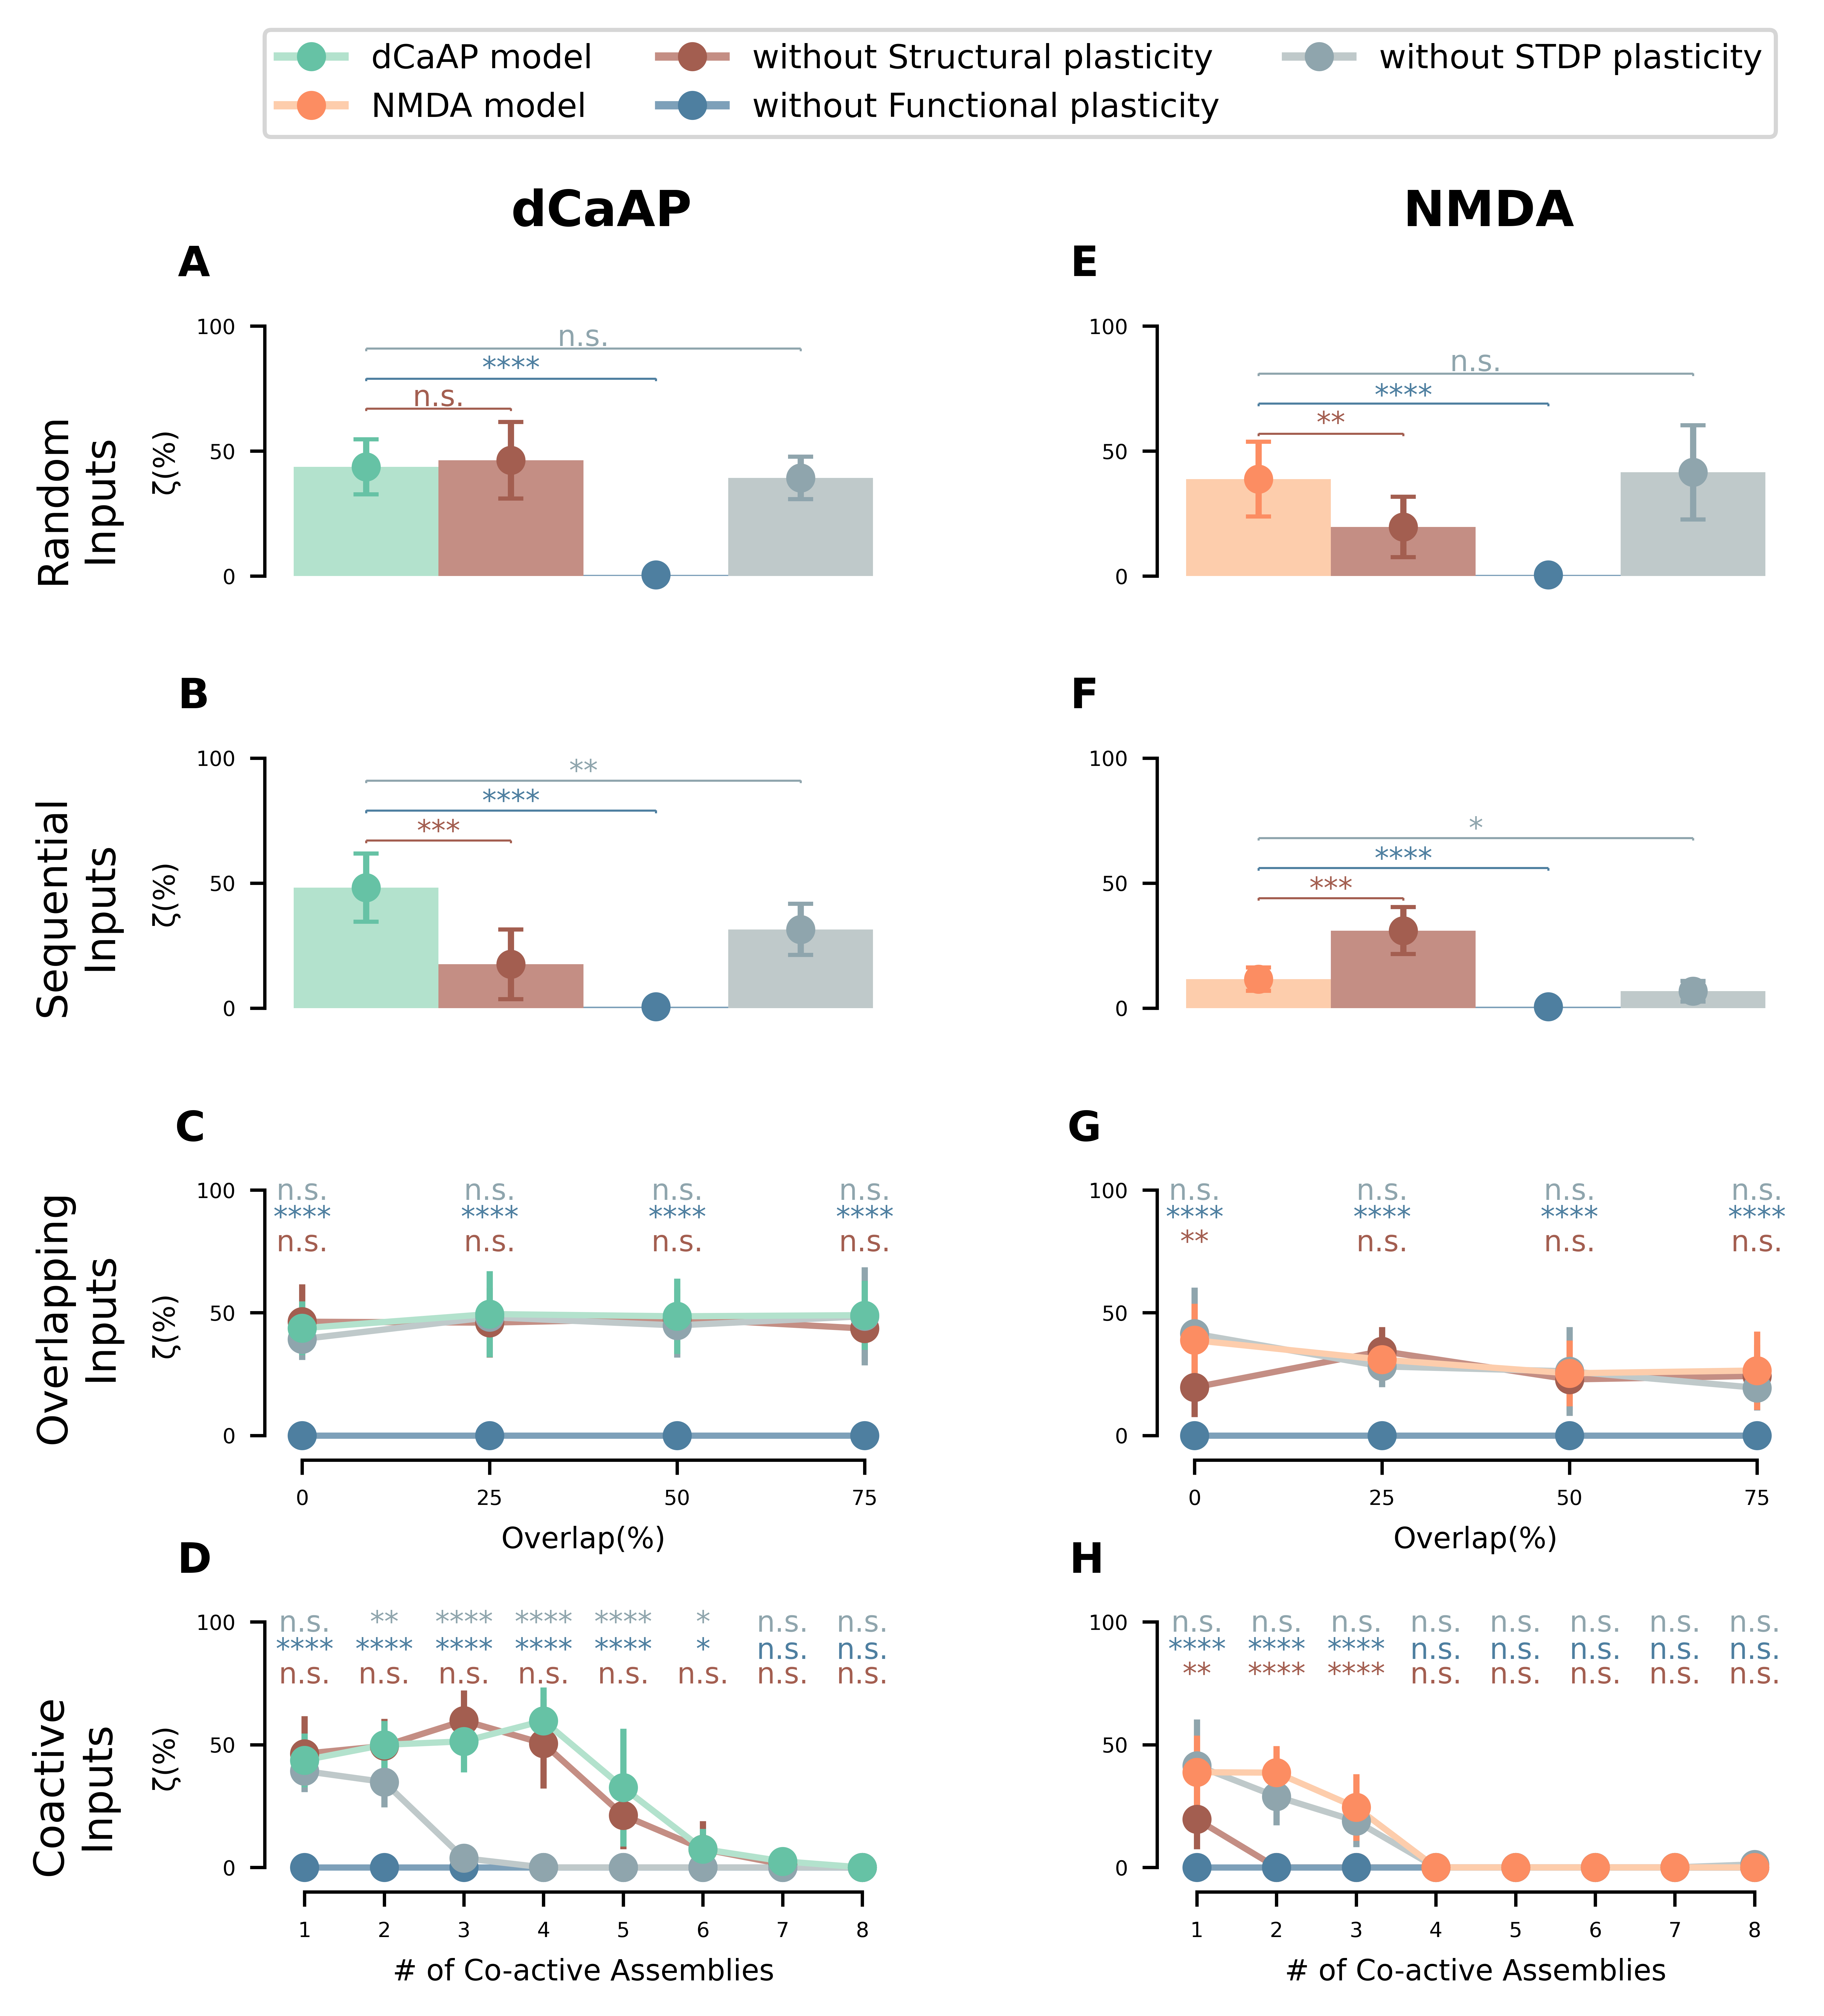

In [239]:
fig, ax = plt.subplots(4,2,figsize=(2*3.3, 4*1.7), dpi=1000)


str_color = '#C48E84'
func_color = '#7DA0B9'
stdp_color = '#BFC9CA'

str_color_err = '#A35E50'
func_color_err = '#4E7FA0'
stdp_color_err = '#8FA5AD'


################################################## Random ###########################################################
######################################################################################################################
######################################################################################################################
x_pos =[[0.8,0.9,1.0,1.1,1.2,1.3],[1.5,1.6,1.7,1.8,1.9,2.0]]
w =0.1
visible = 0.5
# ax[0][0].set_title('dCaAP\nRandom input')
# ax[0][1].set_title('NMDA\nRandom input')
ax[0][0].set_ylabel('\u03B6(%)',fontsize = 7)
ax[0][0].set_ylim(0,100)
ax[1][0].set_ylim(0,100)
ax[0][0].set_ylim(-8,100)
ax[0][1].set_ylim(-8,100)
##############################################Basic 
#######################dCaAP
ax[0][0].bar(x_pos[0][1],EXP2_eff[1],width = w,color = dCaAP_color,label = 'dCaAP')
ax[0][0].errorbar(x_pos[0][1],EXP2_eff[1],yerr=EXP2_eff_err[1],fmt='o',color = dCaAP_error_color,label = 'dCaAP', capsize=3)
####################### NMDA
ax[0][1].bar(x_pos[0][1],EXP2_eff[0],width = w,color = NMDA_color,label = 'NMDA')
ax[0][1].errorbar(x_pos[0][1],EXP2_eff[0],yerr=EXP2_eff_err[0],fmt='o',color = NMDA_error_color,label = 'NMDA', capsize=3)


####################### No Structural Plasticity
#######################dCaAP
ax[0][0].bar(x_pos[0][2],str_EXP2_eff[1],width = w,color = str_color,label = 'No Structural Plasticity')
ax[0][0].errorbar(x_pos[0][2],str_EXP2_eff[1],yerr=str_EXP2_eff_err[1],fmt='o',color = str_color_err,label = 'No Structural Plasticity', capsize=3)
# p_value
ax[0][0].hlines(67, x_pos[0][1],x_pos[0][2], colors=str_color_err, linestyles='-', linewidth=0.5)
ax[0][0].vlines(x_pos[0][1],66,67.1, colors=str_color_err, linestyles='-', linewidth=0.5)
ax[0][0].vlines(x_pos[0][2],66,67.1, colors=str_color_err, linestyles='-', linewidth=0.5)
ax[0][0].text((x_pos[0][1]+x_pos[0][2])/2, 68, p_value_reporting(random_str_eff_p[1]), ha='center', fontsize = 7, color = str_color_err)
#################################
####################### NMDA
ax[0][1].bar(x_pos[0][2],str_EXP2_eff[0],width = w,color = str_color,label = 'No Structural Plasticity')
ax[0][1].errorbar(x_pos[0][2],str_EXP2_eff[0],yerr=str_EXP2_eff_err[0],fmt='o',color = str_color_err,label = 'No Structural Plasticity', capsize=3)
# p_value
ax[0][1].hlines(57, x_pos[0][1],x_pos[0][2], colors=str_color_err, linestyles='-', linewidth=0.5)
ax[0][1].vlines(x_pos[0][1],56,57.1, colors=str_color_err, linestyles='-', linewidth=0.5)
ax[0][1].vlines(x_pos[0][2],56,57.1, colors=str_color_err, linestyles='-', linewidth=0.5)
ax[0][1].text((x_pos[0][1]+x_pos[0][2])/2, 57.5, p_value_reporting(random_str_eff_p[0]), ha='center', fontsize = 7 , color = str_color_err)
#################################


####################### No Functional Plasticity
#######################dCaAP
ax[0][0].bar(x_pos[0][3],func_EXP2_eff[1]+visible,width = w,color = func_color,label = 'No Functional Plasticity')
ax[0][0].errorbar(x_pos[0][3],func_EXP2_eff[1]+visible,yerr=func_EXP2_eff_err[1],fmt='o',color = func_color_err,label = 'No Functional Plasticity', capsize=3)
# p_value
ax[0][0].hlines(79, x_pos[0][1],x_pos[0][3], colors=func_color_err, linestyles='-', linewidth=0.5)
ax[0][0].vlines(x_pos[0][1],78,79.1, colors=func_color_err, linestyles='-', linewidth=0.5)
ax[0][0].vlines(x_pos[0][3],78,79.1, colors=func_color_err, linestyles='-', linewidth=0.5)
ax[0][0].text((x_pos[0][1]+x_pos[0][3])/2, 79.5, p_value_reporting(random_func_eff_p[1]), ha='center', fontsize = 7 , color = func_color_err)
#################################
####################### NMDA
ax[0][1].bar(x_pos[0][3],func_EXP2_eff[0]+visible,width = w,color = func_color,label = 'No Functional Plasticity')
ax[0][1].errorbar(x_pos[0][3],func_EXP2_eff[0]+visible,yerr=func_EXP2_eff_err[0],fmt='o',color = func_color_err,label = 'No Functional Plasticity', capsize=3)
# p_value
ax[0][1].hlines(69, x_pos[0][1],x_pos[0][3], colors=func_color_err, linestyles='-', linewidth=0.5)
ax[0][1].vlines(x_pos[0][1],68,69.1, colors=func_color_err, linestyles='-', linewidth=0.5)
ax[0][1].vlines(x_pos[0][3],68,69.1, colors=func_color_err, linestyles='-', linewidth=0.5)
ax[0][1].text((x_pos[0][1]+x_pos[0][3])/2, 68.5, p_value_reporting(random_func_eff_p[0]), ha='center', fontsize = 7 ,color = func_color_err)
#################################

####################### No STDP Plasticity
#######################dCaAP
ax[0][0].bar(x_pos[0][4],stdp_EXP2_eff[1],width = w,color = stdp_color,label = 'No STDP Plasticity')
ax[0][0].errorbar(x_pos[0][4],stdp_EXP2_eff[1],yerr=stdp_EXP2_eff_err[1],fmt='o',color = stdp_color_err,label = 'No STDP Plasticity', capsize=3)
# p_value
ax[0][0].hlines(91, x_pos[0][1],x_pos[0][4], colors=stdp_color_err, linestyles='-', linewidth=0.5)
ax[0][0].vlines(x_pos[0][1],90,91.1, colors=stdp_color_err, linestyles='-', linewidth=0.5)
ax[0][0].vlines(x_pos[0][4],90,91.1, colors=stdp_color_err, linestyles='-', linewidth=0.5)
ax[0][0].text((x_pos[0][1]+x_pos[0][4])/2, 92, p_value_reporting(random_stdp_eff_p[1]), ha='center', fontsize = 7 , color = stdp_color_err)
#################################
####################### NMDA
ax[0][1].bar(x_pos[0][4],stdp_EXP2_eff[0],width = w,color = stdp_color,label = 'No STDP Plasticity')
ax[0][1].errorbar(x_pos[0][4],stdp_EXP2_eff[0],yerr=stdp_EXP2_eff_err[0],fmt='o',color = stdp_color_err,label = 'No STDP Plasticity', capsize=3)
# p_value
ax[0][1].hlines(81, x_pos[0][1],x_pos[0][4], colors=stdp_color_err, linestyles='-', linewidth=0.5)
ax[0][1].vlines(x_pos[0][1],80,81.1, colors=stdp_color_err, linestyles='-', linewidth=0.5)
ax[0][1].vlines(x_pos[0][4],80,81.1, colors=stdp_color_err, linestyles='-', linewidth=0.5)
ax[0][1].text((x_pos[0][1]+x_pos[0][4])/2, 82, p_value_reporting(random_stdp_eff_p[0]), ha='center', fontsize = 7 , color = stdp_color_err)
#################################


################################################## Sequential ###########################################################
######################################################################################################################
######################################################################################################################
# ax[1][0].set_title('dCaAP\nSequential input')
# ax[1][1].set_title('NMDA\nSequential input')
ax[1][0].set_ylabel('\u03B6(%)',fontsize = 7)
# ax[1][1].set_ylabel('\u03B6(%)')
ax[1][0].set_ylim(0,100)
ax[1][1].set_ylim(0,100)
ax[1][0].set_ylim(-8,100)
ax[1][1].set_ylim(-8,100)
##############################################Basic 
#######################dCaAP
ax[1][0].bar(x_pos[1][1],EXP3_eff[1],width = w,color = dCaAP_color,label = 'dCaAP')
ax[1][0].errorbar(x_pos[1][1],EXP3_eff[1],yerr=EXP3_eff_err[1],fmt='o',color = dCaAP_error_color,label = 'dCaAP', capsize=3)
####################### NMDA
ax[1][1].bar(x_pos[1][1],EXP3_eff[0],width = w,color = NMDA_color,label = 'NMDA')
ax[1][1].errorbar(x_pos[1][1],EXP3_eff[0],yerr=EXP3_eff_err[0],fmt='o',color = NMDA_error_color,label = 'NMDA', capsize=3)

####################### No Structural Plasticity
#######################dCaAP
ax[1][0].bar(x_pos[1][2],str_EXP3_eff[1],width = w,color = str_color,label = 'No Structural Plasticity')
ax[1][0].errorbar(x_pos[1][2],str_EXP3_eff[1],yerr=str_EXP3_eff_err[1],fmt='o',color = str_color_err,label = 'No Structural Plasticity', capsize=3)
# p_value
ax[1][0].hlines(67, x_pos[1][1],x_pos[1][2], colors=str_color_err, linestyles='-', linewidth=0.5)
ax[1][0].vlines(x_pos[1][1],66,67.1, colors=str_color_err, linestyles='-', linewidth=0.5)
ax[1][0].vlines(x_pos[1][2],66,67.1, colors=str_color_err, linestyles='-', linewidth=0.5)
ax[1][0].text((x_pos[1][1]+x_pos[1][2])/2, 67, p_value_reporting(seq_str_eff_p[1]), ha='center', fontsize = 7,color = str_color_err)
#################################
####################### NMDA
ax[1][1].bar(x_pos[1][2],str_EXP3_eff[0],width = w,color = str_color,label = 'No Structural Plasticity')
ax[1][1].errorbar(x_pos[1][2],str_EXP3_eff[0],yerr=str_EXP3_eff_err[0],fmt='o',color = str_color_err,label = 'No Structural Plasticity', capsize=3)
# p_value
ax[1][1].hlines(44, x_pos[1][1],x_pos[1][2], colors=str_color_err, linestyles='-', linewidth=0.5)
ax[1][1].vlines(x_pos[1][1],43,44.1, colors=str_color_err, linestyles='-', linewidth=0.5)
ax[1][1].vlines(x_pos[1][2],43,44.1, colors=str_color_err, linestyles='-', linewidth=0.5)
ax[1][1].text((x_pos[1][1]+x_pos[1][2])/2, 44, p_value_reporting(seq_str_eff_p[0]), ha='center', fontsize = 7 , color = str_color_err)
#################################

####################### No Functional Plasticity
#######################dCaAP
ax[1][0].bar(x_pos[1][3],func_EXP3_eff[1]+visible,width = w,color = func_color,label = 'No Functional Plasticity')
ax[1][0].errorbar(x_pos[1][3],func_EXP3_eff[1]+visible,yerr = func_EXP3_eff_err[1],fmt='o',color = func_color_err,label = 'No Functional Plasticity', capsize=3)
# p_value
ax[1][0].hlines(79, x_pos[1][1],x_pos[1][3], colors=func_color_err, linestyles='-', linewidth=0.5)
ax[1][0].vlines(x_pos[1][1],78,79.1, colors=func_color_err, linestyles='-', linewidth=0.5)
ax[1][0].vlines(x_pos[1][3],78,79.1, colors=func_color_err, linestyles='-', linewidth=0.5)
ax[1][0].text((x_pos[1][1]+x_pos[1][3])/2, 79, p_value_reporting(seq_func_eff_p[1]), ha='center', fontsize = 7,color = func_color_err)
#################################
####################### NMDA
ax[1][1].bar(x_pos[1][3],func_EXP3_eff[0]+visible,width = w,color = func_color,label = 'No Functional Plasticity')
ax[1][1].errorbar(x_pos[1][3],func_EXP3_eff[0]+visible,yerr = func_EXP3_eff_err[0],fmt='o',color = func_color_err,label = 'No Functional Plasticity', capsize=3)
# p_value
ax[1][1].hlines(56, x_pos[1][1],x_pos[1][3], colors=func_color_err, linestyles='-', linewidth=0.5)
ax[1][1].vlines(x_pos[1][1],55,56.1, colors=func_color_err, linestyles='-', linewidth=0.5)
ax[1][1].vlines(x_pos[1][3],55,56.1, colors=func_color_err, linestyles='-', linewidth=0.5)
ax[1][1].text((x_pos[1][1]+x_pos[1][3])/2, 56, p_value_reporting(seq_func_eff_p[0]), ha='center', fontsize = 7, color = func_color_err)
#################################

####################### No STDP Plasticity
#######################dCaAP
ax[1][0].bar(x_pos[1][4],stdp_EXP3_eff[1],width = w,color = stdp_color,label = 'No STDP Plasticity')
ax[1][0].errorbar(x_pos[1][4],stdp_EXP3_eff[1],yerr = stdp_EXP3_eff_err[1],fmt='o',color = stdp_color_err,label = 'No STDP Plasticity', capsize=3)
# p_value
ax[1][0].hlines(91, x_pos[1][1],x_pos[1][4], colors=stdp_color_err, linestyles='-', linewidth=0.5)
ax[1][0].vlines(x_pos[1][1],90,91.1, colors=stdp_color_err, linestyles='-', linewidth=0.5)
ax[1][0].vlines(x_pos[1][4],90,91.1, colors=stdp_color_err, linestyles='-', linewidth=0.5)
ax[1][0].text((x_pos[1][1]+x_pos[1][4])/2, 91, p_value_reporting(seq_stdp_eff_p[1]), ha='center', fontsize = 7,color = stdp_color_err)
#################################
####################### NMDA
#######################dCaAP
ax[1][1].bar(x_pos[1][4],stdp_EXP3_eff[0],width = w,color = stdp_color,label = 'No STDP Plasticity')
ax[1][1].errorbar(x_pos[1][4],stdp_EXP3_eff[0],yerr = stdp_EXP3_eff_err[0],fmt='o',color = stdp_color_err,label = 'No STDP Plasticity', capsize=3)
# p_value
ax[1][1].hlines(68, x_pos[1][1],x_pos[1][4], colors=stdp_color_err, linestyles='-', linewidth=0.5)
ax[1][1].vlines(x_pos[1][1],68,67.1, colors=stdp_color_err, linestyles='-', linewidth=0.5)
ax[1][1].vlines(x_pos[1][4],68,67.1, colors=stdp_color_err, linestyles='-', linewidth=0.5)
ax[1][1].text((x_pos[1][1]+x_pos[1][4])/2, 68, p_value_reporting(seq_stdp_eff_p[0]), ha='center', fontsize = 7 , color = stdp_color_err)
#################################

ax[1][1].set_xticks([])
ax[1][0].set_xticks([])
ax[0][1].set_xticks([])
ax[0][0].set_xticks([])
ax[0][0].set_yticks([0,50,100],['0','50','100'], ha='right',fontsize = 5)
ax[1][0].set_yticks([0,50,100],['0','50','100'], ha='right',fontsize = 5)
ax[0][1].set_yticks([0,50,100],['0','50','100'], ha='right',fontsize = 5)
ax[1][1].set_yticks([0,50,100],['0','50','100'], ha='right',fontsize = 5)

# plt.subplots_adjust(hspace=1.3)
# plt.subplots_adjust(wspace=0.3)


################################################## Coactive ###########################################################
######################################################################################################################
######################################################################################################################
coactive = np.arange(1,9)
####################### without Structural plasticity
######### dCaAP
ax[3][0].plot(coactive,str_EXP4_eff_gid,color=str_color,label="without Structural plasticity")
ax[3][0].errorbar(coactive, str_EXP4_eff_gid, yerr=str_EXP4_eff_gid_err, fmt="o", color=str_color_err)
# p_values
for n_coactive in coactive:
    ax[3][0].text(n_coactive, 75, p_value_reporting(coactive_str_gid_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = str_color_err )
######
############### NMDA
ax[3][1].plot(coactive,str_EXP4_eff_limb,color=str_color,label="without Structural plasticity")
ax[3][1].errorbar(coactive, str_EXP4_eff_limb, yerr=str_EXP4_eff_limb_err, fmt="o", color=str_color_err)
# p_values
for n_coactive in coactive:
    ax[3][1].text(n_coactive, 75, p_value_reporting(coactive_str_limb_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = str_color_err )
######

####################### without Functional plasticity
######### dCaAP
ax[3][0].plot(coactive,func_EXP4_eff_gid,color=func_color,label="without Functional plasticity")
ax[3][0].errorbar(coactive, func_EXP4_eff_gid, yerr=func_EXP4_eff_gid_err, fmt="o", color=func_color_err)
# p_values
for n_coactive in coactive:
    ax[3][0].text(n_coactive, 85, p_value_reporting(coactive_func_gid_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = func_color_err )
######
############### NMDA
ax[3][1].plot(coactive,func_EXP4_eff_limb,color=func_color,label="without Functional plasticity")
ax[3][1].errorbar(coactive, func_EXP4_eff_limb, yerr=func_EXP4_eff_limb_err, fmt="o", color=func_color_err)
# p_values
for n_coactive in coactive:
    ax[3][1].text(n_coactive, 85, p_value_reporting(coactive_func_limb_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = func_color_err )
######


####################### without STDP plasticity
######### dCaAP
ax[3][0].plot(coactive,stdp_EXP4_eff_gid,color=stdp_color,label="without STDP plasticity")
ax[3][0].errorbar(coactive, stdp_EXP4_eff_gid, yerr=stdp_EXP4_eff_gid_err, fmt="o", color=stdp_color_err)
# p_values
for n_coactive in coactive:
    ax[3][0].text(n_coactive, 96, p_value_reporting(coactive_stdp_gid_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = stdp_color_err )
######
############### NMDA
ax[3][1].plot(coactive,stdp_EXP4_eff_limb,color=stdp_color,label="without STDP plasticity")
ax[3][1].errorbar(coactive, stdp_EXP4_eff_limb, yerr=stdp_EXP4_eff_limb_err, fmt="o", color=stdp_color_err)
# p_values
for n_coactive in coactive:
    ax[3][1].text(n_coactive, 96, p_value_reporting(coactive_stdp_limb_eff_p[n_coactive-1]), ha='center', fontsize = 7 , color = stdp_color_err )
######



###################### basic #################################
######## dCaAP
ax[3][0].set_ylim(-10,100)
ax[3][0].set_xlim(0.5,8.5)
ax[3][0].set_ylabel("\u03B6(%)",fontsize = 7)
ax[3][0].set_xlabel("# of Co-active Assemblies",fontsize = 7)
ax[3][0].set_xticks(coactive,['1','2','3','4','5','6','7','8'], ha='center',fontsize = 5)
ax[3][0].set_yticks([0,50,100],['0','50','100'], ha='right',fontsize = 5)


ax[3][0].plot(coactive,EXP4_eff_gid,color=dCaAP_color,label="dCaAP")
ax[3][0].errorbar(coactive, EXP4_eff_gid, yerr=EXP4_eff_gid_err, fmt="o", color=dCaAP_error_color)

######## NMDA
ax[3][1].set_ylim(-10,100)
ax[3][1].set_xlim(0.5,8.5)
ax[3][1].set_xlabel("# of Co-active Assemblies",fontsize = 7)
ax[3][1].set_xticks(coactive,['1','2','3','4','5','6','7','8'], ha='center',fontsize = 5)
ax[3][1].set_yticks([0,50,100],['0','50','100'], ha='right',fontsize = 5)


ax[3][1].plot(coactive,EXP4_eff_limb,color=NMDA_color,label="NMDA")
ax[3][1].errorbar(coactive, EXP4_eff_limb, yerr=EXP4_eff_limb_err, fmt="o", color=NMDA_error_color)





################################################## Overlapping ###########################################################
######################################################################################################################
######################################################################################################################

####################### without Structural plasticity
######### dCaAP
ax[2][0].plot(overlap_percentage,str_EXP5_eff_gid,color=str_color,label="without Structural plasticity")
ax[2][0].errorbar(overlap_percentage, str_EXP5_eff_gid, yerr=str_EXP5_eff_gid_err, fmt="o", color=str_color_err)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax[2][0].text(p_overlap, 75, p_value_reporting(overlap_str_gid_eff_p[i]), ha='center', fontsize = 7 , color = str_color_err )
######
############### NMDA
ax[2][1].plot(overlap_percentage,str_EXP5_eff_limb,color=str_color,label="without Structural plasticity")
ax[2][1].errorbar(overlap_percentage, str_EXP5_eff_limb, yerr=str_EXP5_eff_limb_err, fmt="o", color=str_color_err)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax[2][1].text(p_overlap, 75, p_value_reporting(overlap_str_limb_eff_p[i]), ha='center', fontsize = 7 , color = str_color_err )
######


####################### without Functional plasticity
######### dCaAP
ax[2][0].plot(overlap_percentage,func_EXP5_eff_gid,color=func_color,label="without Functional plasticity")
ax[2][0].errorbar(overlap_percentage, func_EXP5_eff_gid, yerr=func_EXP5_eff_gid_err, fmt="o", color=func_color_err)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax[2][0].text(p_overlap, 85, p_value_reporting(overlap_func_gid_eff_p[i]), ha='center', fontsize = 7 , color = func_color_err )
######
############### NMDA
ax[2][1].plot(overlap_percentage,func_EXP5_eff_limb,color=func_color,label="without Functional plasticity")
ax[2][1].errorbar(overlap_percentage, func_EXP5_eff_limb, yerr=func_EXP5_eff_limb_err, fmt="o", color=func_color_err)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax[2][1].text(p_overlap, 85, p_value_reporting(overlap_func_limb_eff_p[i]), ha='center', fontsize = 7 , color = func_color_err )
######


####################### without STDP plasticity
######### dCaAP
ax[2][0].plot(overlap_percentage,stdp_EXP5_eff_gid,color=stdp_color,label="without STDP plasticity")
ax[2][0].errorbar(overlap_percentage, stdp_EXP5_eff_gid, yerr=stdp_EXP5_eff_gid_err, fmt="o", color=stdp_color_err)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax[2][0].text(p_overlap, 96, p_value_reporting(overlap_stdp_gid_eff_p[i]), ha='center', fontsize = 7 , color = stdp_color_err )
######
############### NMDA
ax[2][1].plot(overlap_percentage,stdp_EXP5_eff_limb,color=stdp_color,label="without STDP plasticity")
ax[2][1].errorbar(overlap_percentage, stdp_EXP5_eff_limb, yerr=stdp_EXP5_eff_limb_err, fmt="o", color=stdp_color_err)
# p_values
for i , p_overlap in enumerate(overlap_percentage):
    ax[2][1].text(p_overlap, 96, p_value_reporting(overlap_stdp_limb_eff_p[i]), ha='center', fontsize = 7 , color = stdp_color_err )
######


###################### basic #################################
######## dCaAP
ax[2][0].set_ylim(-10,100)
ax[2][0].set_xlim(-5,80)
ax[2][0].set_ylabel("\u03B6(%)",fontsize = 7)
ax[2][0].set_xlabel("Overlap(%)",fontsize = 7)
ax[2][0].set_xticks([0,25,50,75],['0','25','50','75'], ha='center',fontsize = 5)
ax[2][0].set_yticks([0,50,100],['0','50','100'], ha='right',fontsize = 5)


ax[2][0].plot(overlap_percentage[:len(EXP5_eff_gid)],EXP5_eff_gid,color=dCaAP_color,label="dCaAP")
ax[2][0].errorbar(overlap_percentage[:len(EXP5_eff_gid)], EXP5_eff_gid, yerr=EXP5_eff_gid_err, fmt="o", color=dCaAP_error_color)

######## NMDA
ax[2][1].set_ylim(-10,100)
ax[2][1].set_xlim(-5,80)
ax[2][1].set_xlabel("Overlap(%)",fontsize = 7)
ax[2][1].set_xticks([0,25,50,75],['0','25','50','75'], ha='center',fontsize = 5)
ax[2][1].set_yticks([0,50,100],['0','50','100'], ha='right',fontsize = 5)

ax[2][1].plot(overlap_percentage,EXP5_eff_limb,color=NMDA_color,label="NMDA")
ax[2][1].errorbar(overlap_percentage, EXP5_eff_limb, yerr=EXP5_eff_limb_err, fmt="o", color=NMDA_error_color )


plt.subplots_adjust(wspace=0.4)
plt.subplots_adjust(hspace=0.6)
handles = [
    plt.Line2D([0], [0], color=dCaAP_color, marker='o', linestyle='-', lw=2 , markerfacecolor=dCaAP_error_color, markeredgecolor=dCaAP_error_color, label='dCaAP model'),
    plt.Line2D([0], [0], color=NMDA_color, marker='o', linestyle='-', lw=2 , markerfacecolor=NMDA_error_color, markeredgecolor=NMDA_error_color, label='NMDA model'),
    plt.Line2D([0], [0], color=str_color, marker='o', linestyle='-', lw=2 , markerfacecolor=str_color_err, markeredgecolor=str_color_err, label='without Structural plasticity'),
    plt.Line2D([0], [0], color=func_color, marker='o', linestyle='-', lw=2 , markerfacecolor=func_color_err, markeredgecolor=func_color_err, label='without Functional plasticity'),
    plt.Line2D([0], [0], color=stdp_color, marker='o', linestyle='-', lw=2 , markerfacecolor=stdp_color_err, markeredgecolor=stdp_color_err, label='without STDP plasticity')
]

ax[0][0].text(np.mean(x_pos[0][:5]),140,'dCaAP',fontsize = 12,fontweight = 'bold')
ax[0][1].text(np.mean(x_pos[0][:5]),140,'NMDA',fontsize = 12,fontweight = 'bold')

ax[0][0].text(0.77,120,'A',fontsize = 10,fontweight = 'bold')
ax[0][1].text(0.77,120,'E',fontsize = 10,fontweight = 'bold')

ax[1][0].text(1.47,120,'B',fontsize = 10,fontweight = 'bold')
ax[1][1].text(1.47,120,'F',fontsize = 10,fontweight = 'bold')

ax[2][0].text(-17,120,'C',fontsize = 10,fontweight = 'bold')
ax[2][1].text(-17,120,'G',fontsize = 10,fontweight = 'bold')

ax[3][0].text(-.6,120,'D',fontsize = 10,fontweight = 'bold')
ax[3][1].text(-.6,120,'H',fontsize = 10,fontweight = 'bold')

ax[0][0].text(0.7,0,'Random\nInputs',fontsize = 10,rotation = 90, ha='center')
ax[1][0].text(1.4,0,'Sequential\nInputs',fontsize = 10,rotation = 90, ha='center')
ax[2][0].text(-30,0,'Overlapping\nInputs',fontsize = 10,rotation = 90, ha='center')
ax[3][0].text(-1.9,0,'Coactive\nInputs',fontsize = 10,rotation = 90, ha='center')

plt.legend(loc = (-1.4,6.5), handles=handles, ncol = 3, fontsize = 8)

#########
for i,axes in enumerate(ax.flat):
    axes.spines['top'].set_visible(False)
    axes.spines['right'].set_visible(False)
    axes.spines['left'].set_bounds(0, 100)
    if i in [0,1,2,3] :
        axes.spines['bottom'].set_visible(False)
    elif i in [4,5]:
        axes.spines['bottom'].set_bounds(0, 75)
    elif i in [6,7]:
        axes.spines['bottom'].set_bounds(1, 8)
        
        
#######


plt.tight_layout()
# plt.show()
fig.savefig("Figures/pdf/plasticity_knock_out.pdf", format='pdf',bbox_inches='tight')
fig.savefig("Figures/svg/plasticity_knock_out.svg", format='svg',bbox_inches='tight')

# Input current Intensity

In [241]:
EXP6_dend_limb =[]
EXP6_dend_limb_err=[]
EXP6_assemb_limb = []
EXP6_assemb_limb_err=[]
EXP6_eff_limb =[]
EXP6_eff_limb_err=[]
#####################
EXP6_dend_gid =[]
EXP6_dend_gid_err=[]
EXP6_assemb_gid = []
EXP6_assemb_gid_err=[]
EXP6_eff_gid = []
EXP6_eff_gid_err=[]


gidon_exp6_eff_list = []
limb_exp6_eff_list = []

#################################################
exp_name = "rewiring_ex2"
exp_result_name_folder_list = ['Random_input_I_amp1.0','Random_input','Random_input_I_amp5.0','Random_input_I_amp7.0','Random_input_I_amp9.0']

for model_name in ['Limbacher','Gidon_dend']:
    for exp_result_name_folder in exp_result_name_folder_list:

        simulation_list_date = os.listdir(f'results/{exp_name}/{exp_result_name_folder}/{model_name}')
        if '.ipynb_checkpoints' in simulation_list_date:
            simulation_list_date.remove('.ipynb_checkpoints') 
        if '.DS_Store' in simulation_list_date:
            simulation_list_date.remove('.DS_Store')
        simulation_list_date.sort()

        sep_ass = []
        sep_dend = []

        for i in range(len(simulation_list_date)):
            u = 0
            dend_counter = 0
            assemb_list = []
            color_of_seperated_assemblies = []
            with open(f'results/{exp_name}/{exp_result_name_folder}/{model_name}/{simulation_list_date[i]}/stats.txt', 'r') as f:
                for line in f:
                    if u == 26:
                        line_as_list = ast.literal_eval(line[29:])
                        for DEND in line_as_list:
                            if len(DEND) == 1:
                                dend_counter += 1
                                assemb_list.append(DEND[0])
                        sep_dend.append(dend_counter)
                    u += 1

            sep_ass.append(len(set(assemb_list)))
        sep_ass = np.array(sep_ass)
        sep_dend = np.array(sep_dend)
        eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)
        if model_name == "Limbacher":

            limb_exp6_eff_list.append(eff)

            EXP6_dend_limb.append(np.mean(sep_dend))
            EXP6_dend_limb_err.append(np.std(sep_dend))
            EXP6_assemb_limb.append(np.mean(sep_ass))
            EXP6_assemb_limb_err.append(np.std(sep_ass))
            EXP6_eff_limb.append(np.mean(eff))
            EXP6_eff_limb_err.append(np.std(eff))
        elif model_name == "Gidon_dend":

            gidon_exp6_eff_list.append(eff)
            
            EXP6_dend_gid.append(np.mean(sep_dend))
            EXP6_dend_gid_err.append(np.std(sep_dend))
            EXP6_assemb_gid.append(np.mean(sep_ass))
            EXP6_assemb_gid_err.append(np.std(sep_ass))
            EXP6_eff_gid.append(np.mean(eff))
            EXP6_eff_gid_err.append(np.std(eff))


/var/folders/rj/mk57hg8s74l0y1xwws2ss9k40000gn/T/ipykernel_21358/1480805268.py:55: RuntimeWarning: invalid value encountered in divide
  eff = np.nan_to_num(((sep_ass/8)*(sep_ass/sep_dend))*100)


In [243]:
EXP6_p_values= [permutation_test(limb_exp6_eff_list[i], gidon_exp6_eff_list[i]) for i in range(5)]
print(EXP6_p_values)

[0.0, 0.439, 0.0052, 0.0, 0.0]


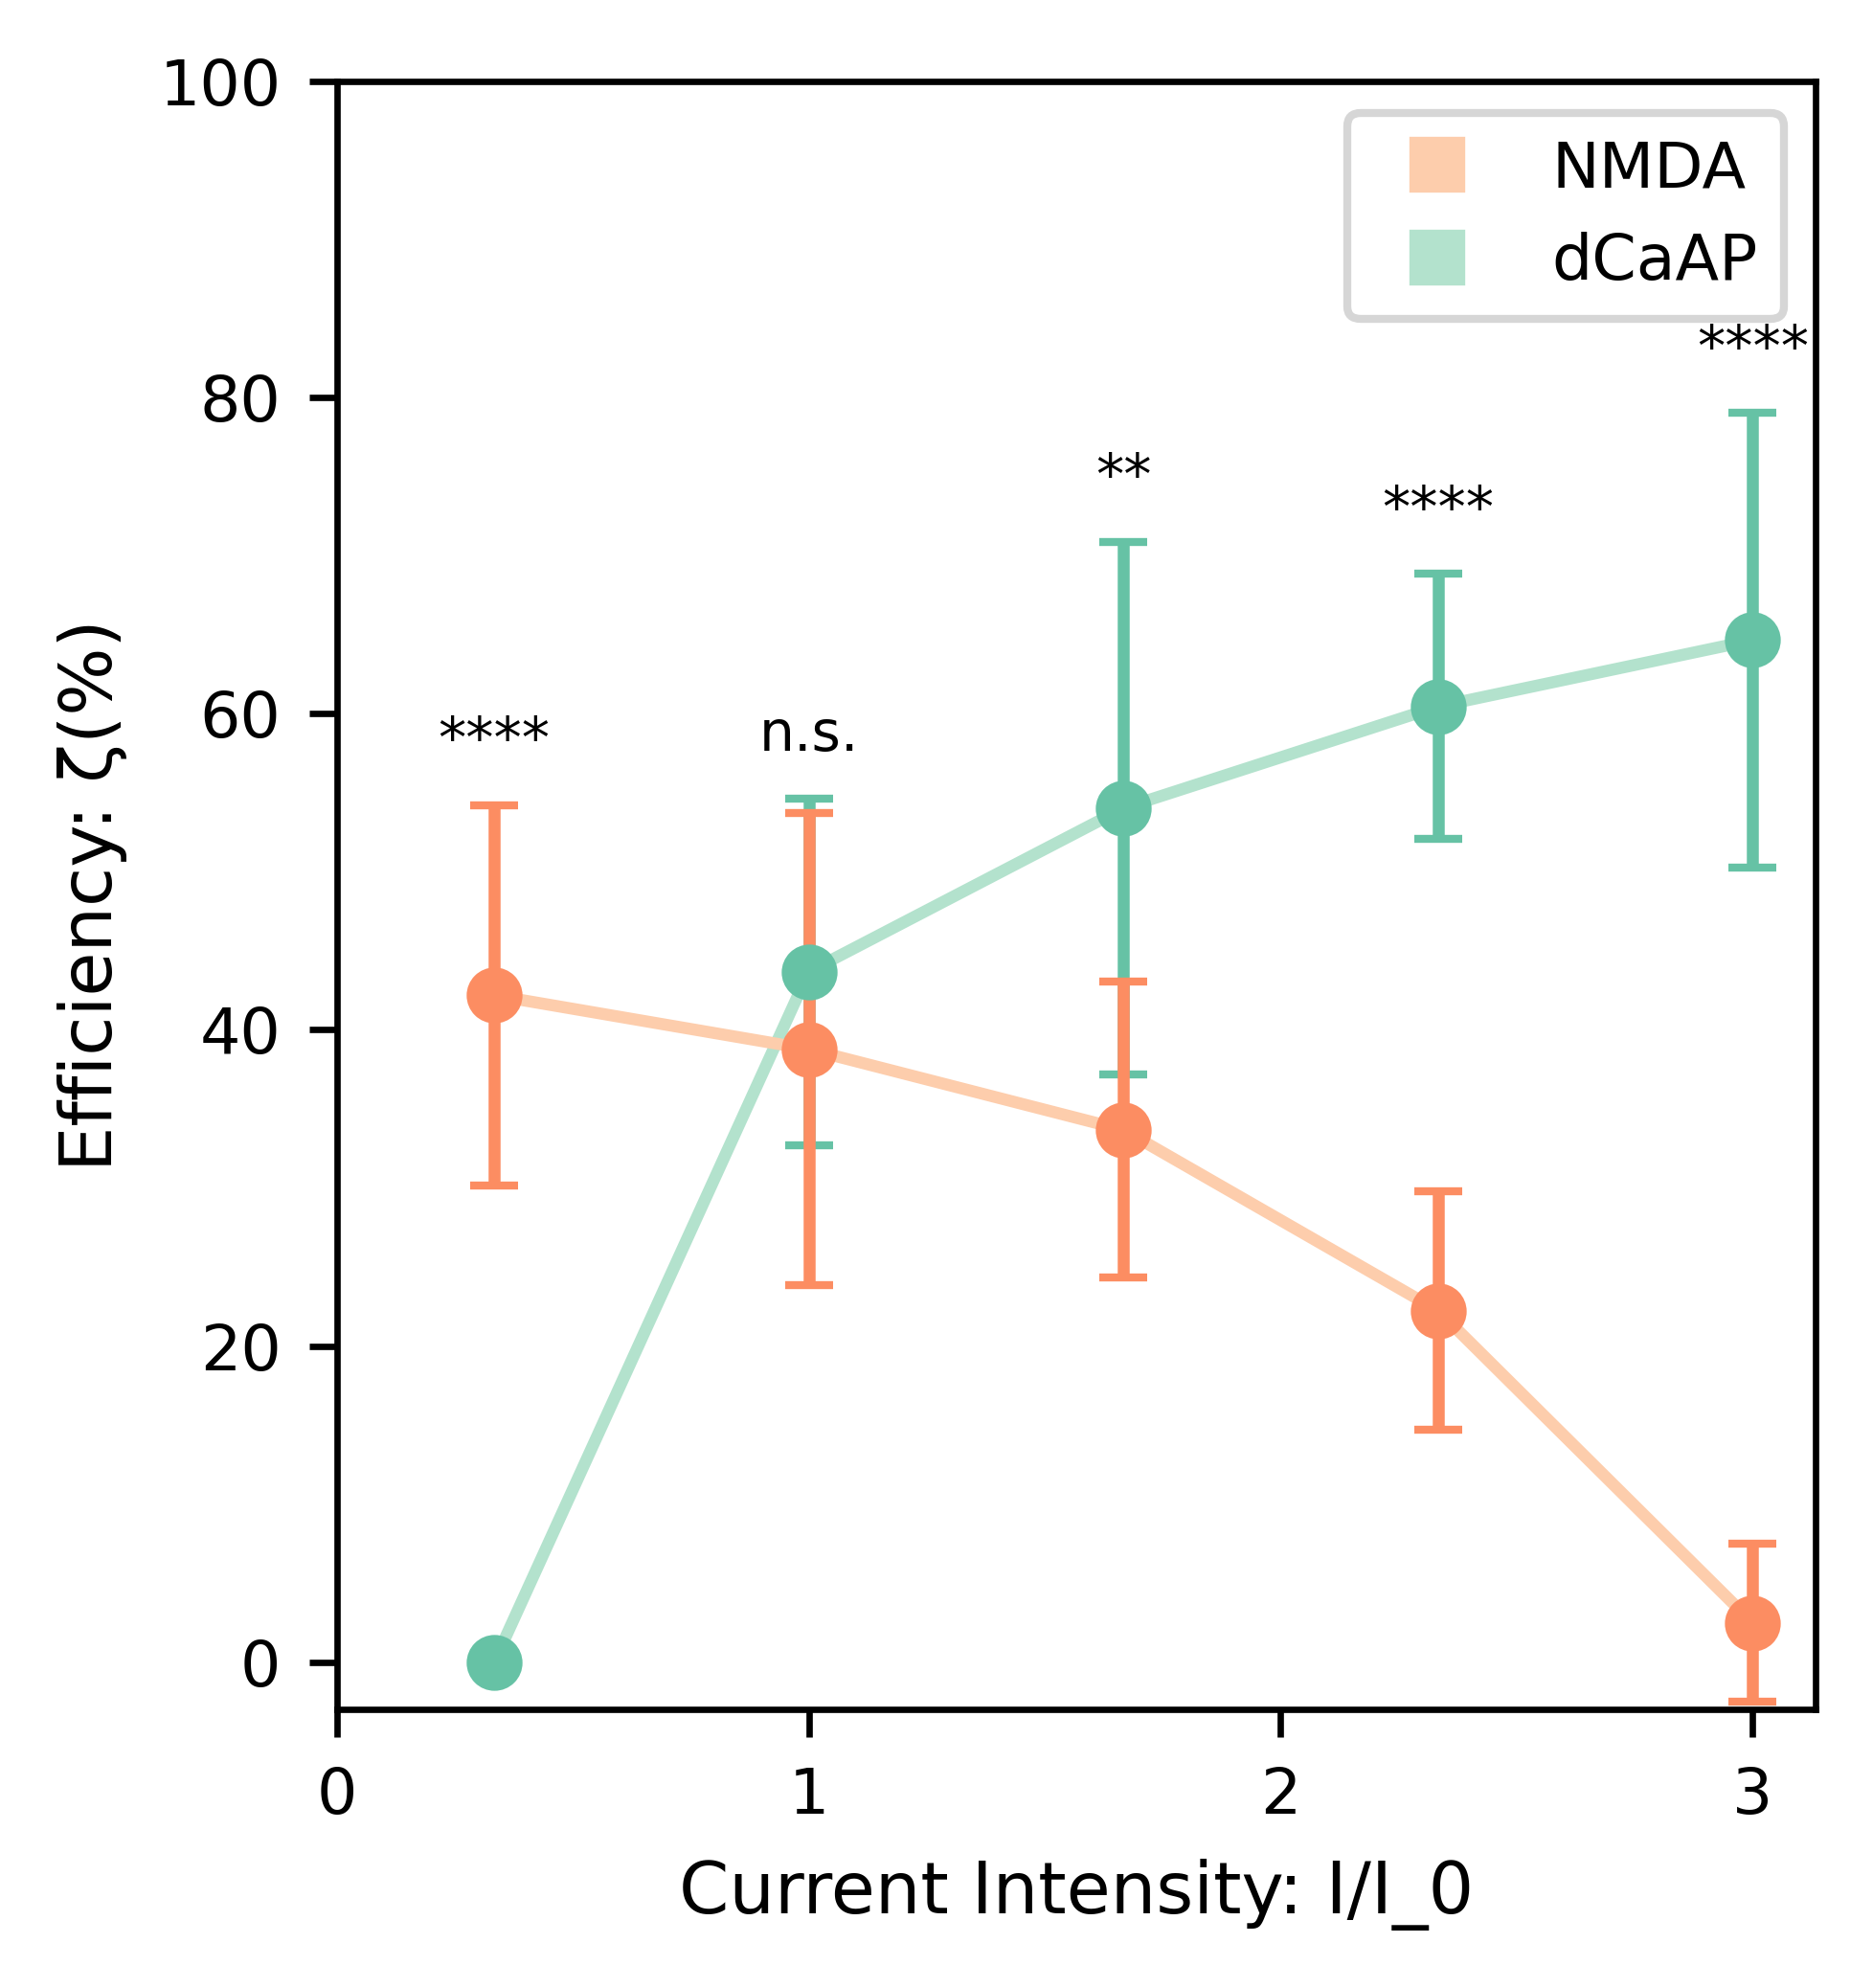

In [245]:
Intensity = [1/3,3/3,5/3,7/3,9/3]


fig, ax = plt.subplots(figsize=(3.3, 3.5), dpi=600)
ax.set_ylim(-3,100)


ax.plot(Intensity,EXP6_eff_gid,color=dCaAP_color,label="dCaAP")
ax.errorbar(Intensity, EXP6_eff_gid, yerr=EXP6_eff_gid_err, fmt="o", color=dCaAP_error_color , capsize = 3)

ax.plot(Intensity,EXP6_eff_limb,color=NMDA_color,label="NMDA")
ax.errorbar(Intensity, EXP6_eff_limb, yerr=EXP6_eff_limb_err, fmt="o", color=NMDA_error_color, capsize = 3)

# p_values
for i , amp_intensity in enumerate(Intensity):
    ax.text(amp_intensity,max(EXP6_eff_gid[i]+EXP6_eff_gid_err[i] , EXP6_eff_limb[i]+EXP6_eff_limb_err[i])+3 , p_value_reporting(EXP6_p_values[i]), ha='center', fontsize = 7  )
######

ax.set_ylabel("Efficiency: \u03B6(%)")

ax.set_xlabel("Current Intensity: I/I_0")
plt.xticks([0,1,2,3])
plt.yticks()

dCaAP_legend = mlines.Line2D([], [], color=dCaAP_color, marker='s', linestyle='None',
                           label='dCaAP')
NMDA_legend = mlines.Line2D([], [], color=NMDA_color, marker='s', linestyle='None',
                           label='NMDA')

ax.legend(handles=[NMDA_legend,dCaAP_legend],loc='upper right')

plt.tight_layout()
# plt.show()
fig.savefig("Figures/pdf/Intensity_efficiencies.pdf", format='pdf',bbox_inches='tight')
fig.savefig("Figures/svg/Intensity_efficiencies.svg", format='svg',bbox_inches='tight')